# Power Outage Forecasting and Backup Generator Pre-positioning

**Team members:**
- Alina Zhong
- Arturo Arias
- Nerin Wang
- Passiri Bodhidatta

**Course:** 95828 - Machine Learning for Problem Solving

**Section:** A

**Term:** Spring 2026

## 1. Introduction

This notebook consolidates the modeling pipeline for our Machine Learning for Problem Solving final project on short-term power outage forecasting and backup generator pre-positioning in Michigan. The operational setting is deliberately decision-oriented: forecasts are useful only insofar as they support an actionable pre-event allocation of scarce backup generation capacity.

The prediction task is to estimate hourly county-level outage counts for two forecast horizons: 24 hours and 48 hours. The training data contain hourly outage counts, tracked customers, and 109 weather and environmental variables for 83 Michigan counties. The project constraint that future weather is unavailable during the forecast window is central to the design of every model in this notebook. Accordingly, the feature engineering relies on observed outage history, observed weather history, lagged summaries, and calendar structure, rather than direct future weather inputs.

The decision task is to allocate five backup generators before the event. Each generator can serve up to 1,000 households, and a deployed generator cannot be moved during the event. We therefore evaluate county risk from the selected forecast model and implement a transparent greedy allocation rule that can be inspected, revised, or replaced.

The notebook is structured to be both reproducible and practical. Each major model family has an explicit rerun switch: SARIMA and LSTM can be recomputed end to end when trained artifacts are unavailable, while the two-stage section can reuse its corrected attempt artifacts. The selected model family for prediction is currently the LSTM, consistent with the final modeling decision, but the downstream prediction and generator allocation code is controlled by a small number of model-selection variables so that SARIMA or the two-stage model can be substituted with minimal friction.


## 2. Importing the Necessary Modules

The import cell is written to work in either Google Colab or a local Jupyter environment. In Colab, missing packages can be installed automatically; locally, the notebook reports missing dependencies so the environment remains under the user's control. The rest of the notebook uses shared data objects and shared helper functions rather than redefining paths or metrics separately inside each model section.


In [1]:
import importlib
import json
import math
import os
import random
import shutil
import subprocess
import sys
import warnings
from datetime import datetime
from pathlib import Path

RUNNING_IN_COLAB = False
try:
    import google.colab  # type: ignore
    RUNNING_IN_COLAB = True
except Exception:
    RUNNING_IN_COLAB = False

if RUNNING_IN_COLAB:
    from google.colab import drive  # type: ignore
    drive.mount('/content/drive', force_remount=False)

AUTO_INSTALL_MISSING_PACKAGES = RUNNING_IN_COLAB

REQUIRED_PACKAGES = {
    'numpy': 'numpy',
    'pandas': 'pandas',
    'xarray': 'xarray',
    'matplotlib': 'matplotlib',
    'seaborn': 'seaborn',
    'IPython': 'ipython',
    'sklearn': 'scikit-learn',
    'joblib': 'joblib',
    'statsmodels': 'statsmodels',
    'tqdm': 'tqdm',
    'torch': 'torch',
}

missing_packages = []
for module_name, package_name in REQUIRED_PACKAGES.items():
    try:
        importlib.import_module(module_name)
        print(f'{module_name}: available')
    except ImportError:
        missing_packages.append(package_name)
        print(f'{module_name}: missing')

if missing_packages and AUTO_INSTALL_MISSING_PACKAGES:
    print('Installing missing packages:', missing_packages)
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', *missing_packages])
elif missing_packages:
    print('Missing packages were detected. Install them before running all cells:', missing_packages)

import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt

try:
    import seaborn as sns
except Exception:
    sns = None

try:
    import torch
    import torch.nn as nn
    from torch.utils.data import DataLoader, TensorDataset
except Exception:
    torch = None
    nn = None
    DataLoader = None
    TensorDataset = None

from IPython.display import Image, Markdown, display
from tqdm.auto import tqdm

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 200)
pd.set_option('display.width', 180)
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.25


Mounted at /content/drive
numpy: available
pandas: available
xarray: available
matplotlib: available
seaborn: available
IPython: available
sklearn: available
joblib: available
statsmodels: available
tqdm: available
torch: available


## 3. Settings, Paths, and Reproducibility

This section is intentionally explicit because it is the control surface for the entire notebook. The most important design choice is that prediction, comparison, and allocation do not hard-code a single model. Instead, `model_for_predictions_24h`, `model_for_predictions_48h`, and `model_for_allocation` are the only variables that determine which model family is used downstream.

The notebook is designed to support both artifact reuse and full recomputation. Training is expensive, so each model family exposes explicit rerun flags. In the current configuration, SARIMA and LSTM are recomputed because their trained model files are not assumed to exist, while the corrected two-stage artifacts are reused from their attempt subfolders.


In [2]:
def discover_project_root() -> Path:
    # Locate the project root whether the notebook is run from the root folder,
    # from final_notebook, or from a Colab working directory.
    candidate_roots = []

    if RUNNING_IN_COLAB:
        candidate_roots.extend([
            Path('/content/drive/MyDrive/MLPS'),
            Path('/content/drive/MyDrive/MLPS Project'),
            Path('/content/drive/MyDrive/Project'),
            Path('/content/drive/MyDrive/MLPS Project/final_notebook'),
        ])

    cwd = Path.cwd().resolve()
    candidate_roots.extend([cwd, *cwd.parents])

    checked = []
    for candidate in candidate_roots:
        candidate = candidate.resolve()

        # If the candidate is final_notebook itself, the project root is its parent.
        possible_roots = [candidate]
        if candidate.name == 'final_notebook':
            possible_roots.append(candidate.parent)

        # Also check parent folders, which helps when running from nested notebook paths.
        possible_roots.extend(candidate.parents)

        for root in possible_roots:
            if root in checked:
                continue
            checked.append(root)

            if (root / 'data' / 'train.nc').exists():
                return root

    raise FileNotFoundError(
        'Could not locate the project root. Expected to find data/train.nc in the '
        'current folder, a parent folder, or a configured Google Drive path.'
    )



PROJECT_ROOT = discover_project_root()
FINAL_NOTEBOOK_DIR = PROJECT_ROOT / 'final_notebook'
os.chdir(PROJECT_ROOT)

APPROACH_DIRS = {
    'lstm': FINAL_NOTEBOOK_DIR / 'LSTM',
    'sarima': FINAL_NOTEBOOK_DIR / 'SARIMA',
    'two_stage': FINAL_NOTEBOOK_DIR / 'two_stage',
}

OUTPUT_DIRS = {
    'comparison': FINAL_NOTEBOOK_DIR / 'comparison',
    'generator_allocation': FINAL_NOTEBOOK_DIR / 'generator_allocation',
}

for approach_dir in APPROACH_DIRS.values():
    for subdir in ['inputs', 'outputs', 'models', 'predictions', 'tables', 'plots']:
        (approach_dir / subdir).mkdir(parents=True, exist_ok=True)
for output_dir in OUTPUT_DIRS.values():
    output_dir.mkdir(parents=True, exist_ok=True)

PATHS = {
    'train': PROJECT_ROOT / 'data' / 'train.nc',
    'test_24h': PROJECT_ROOT / 'data' / 'test_24h_demo.nc',
    'test_48h': PROJECT_ROOT / 'data' / 'test_48h_demo.nc',
    'template_24h': PROJECT_ROOT / 'submission_template_24h.csv',
    'template_48h': PROJECT_ROOT / 'submission_template_48h.csv',
    'example_artifacts': FINAL_NOTEBOOK_DIR / 'example_plots_tables',
}

SETTINGS = {
    # Reproducibility seed used by NumPy, Python random, and PyTorch for all non-two-stage work.
    'random_seed': 42,

    # The two-stage artifacts were produced with seed 2026, so that family keeps its original seed.
    # This preserves comparability with those artifacts while the rest of the notebook uses seed 42.
    'two_stage_random_seed': 2026,

    # Forecast horizons required by the assignment. Do not change unless the task definition changes.
    'horizons': [24, 48],

    # Time-series validation split used consistently across EDA and model validation.
    # The final 20 percent of the training period is held out as future validation history.
    'validation_split': 0.20,

    # The model family used for the official 24-hour prediction file.
    # Valid keys are 'lstm', 'sarima', and 'two_stage'.
    'model_for_predictions_24h': 'lstm',

    # The model family used for the official 48-hour prediction file.
    # This is intentionally separate from the 24-hour choice because different horizons may favor different models.
    'model_for_predictions_48h': 'lstm',

    # The model family whose 48-hour forecast is used for generator allocation.
    # The project decision currently uses LSTM predictions, but this can be changed to 'sarima' or 'two_stage'.
    'model_for_allocation': 'lstm',

    # Horizon used for allocation. The 48-hour horizon is usually preferable because it captures the full event window.
    'model_for_allocation_horizon': 48,

    # LSTM variant used when the family key is 'lstm'.
    # The submitted LSTM predictions were generated with the simple top-10-weather feature model.
    # The validation table still reports base, simple, and full variants for comparison.
    'lstm_variant_for_prediction': {24: 'simple', 48: 'simple'},

    # Two-stage attempt used when the family key is 'two_stage'.
    # The aligned attempt is the fairest default comparison because its validation window is aligned to the LSTM split.
    'two_stage_default_attempt': 'exact_sets_aligned_run',

    # SARIMA variant used when the family key is 'sarima'.
    # Matching metrics and prediction files are read from final_notebook/SARIMA/.
    'sarima_variant_for_prediction': 'sarima_seasonal_top10',

    # Training switches. SARIMA and LSTM are True because those model files are not assumed to exist.
    # Two-stage remains False because its corrected artifacts are already available in attempt subfolders.
    'rerun_training': {
        'sarima': True,
        'lstm_base': True,
        'lstm_simple': True,
        'lstm_full': True,
        'two_stage_exact_sets_same_features_run': False,
        'two_stage_exact_sets_aligned_run': False,
        'two_stage_10features_1fold': False,
        'two_stage_50features_2fold': False,
        'two_stage_all_data_run': False,
    },

    # LSTM hyperparameters used when an LSTM rerun flag is True.
    'lstm_seq_len': 24,
    'lstm_batch_size': 64,
    'lstm_epochs': 20,
    'lstm_learning_rate': 1e-3,
    'lstm_hidden_dim': 128,
    'lstm_num_layers': 3,
    'lstm_dropout': 0.30,


    # SARIMA/SARIMAX configuration used by the integrated rerun section.
    # The non-seasonal grid is the full 0..2 x {0,1} x 0..2 search used in the analysis.
    'sarima_order': (1, 0, 1),
    'sarima_grid_p': [0, 1, 2],
    'sarima_grid_d': [0, 1],
    'sarima_grid_q': [0, 1, 2],
    'sarima_seasonal_order_candidates': [(1, 0, 0, 24), (0, 1, 1, 24)],
    'sarima_tune_top_counts': [10, 20],

    # SARIMAX with weather covariates is retained as a full benchmark even though it is not selected.
    'sarimax_run_exogenous_benchmark': True,
    'sarimax_selected_features': ['gh_4', 'pwat', 'sh2', 'cape_1', 'mslma', 'sdlwrf', 'd2m', 'lcc', 'tcc', 'pcdb'],

    # Generator allocation assumptions from the project prompt.
    'n_generators': 5,
    'generator_hourly_capacity': 1000,
}

random.seed(SETTINGS['random_seed'])
np.random.seed(SETTINGS['random_seed'])
if torch is not None:
    torch.manual_seed(SETTINGS['random_seed'])
print(f"Global seed for EDA, SARIMA, LSTM, comparison, and allocation: {SETTINGS['random_seed']}")
print(f"Two-stage seed retained for two-stage artifacts: {SETTINGS['two_stage_random_seed']}")

MODEL_METRICS = []
MODEL_PREDICTIONS = {}
MODEL_PREDICTION_PATHS = {}


def register_metric(family_key, variant_key, display_model, horizon, validation_rmse, metric_source, **extra):
    row = {
        'family_key': family_key,
        'variant_key': variant_key,
        'display_model': display_model,
        'horizon': int(horizon),
        'validation_rmse': np.nan if validation_rmse is None else float(validation_rmse),
        'metric_source': metric_source,
    }
    row.update(extra)
    MODEL_METRICS.append(row)


def read_prediction_csv(path: Path) -> pd.DataFrame:
    df = pd.read_csv(path)
    required = {'timestamp', 'location', 'pred'}
    missing = required.difference(df.columns)
    if missing:
        raise ValueError(f'{path} is missing required columns: {sorted(missing)}')
    df = df[['timestamp', 'location', 'pred']].copy()
    df['timestamp'] = pd.to_datetime(df['timestamp'])
    df['location'] = df['location'].astype(str)
    df['pred'] = pd.to_numeric(df['pred'], errors='coerce').fillna(0.0).clip(lower=0.0)
    return df


def load_prediction_candidates(family_key, horizon, candidates):
    for candidate in candidates:
        candidate = Path(candidate)
        if candidate.exists():
            df = read_prediction_csv(candidate)
            MODEL_PREDICTIONS.setdefault(family_key, {})[int(horizon)] = df
            MODEL_PREDICTION_PATHS.setdefault(family_key, {})[int(horizon)] = candidate
            print(f'Loaded {family_key} {horizon}h predictions from {candidate.relative_to(PROJECT_ROOT)}')
            return df
    print(f'No saved prediction file found for {family_key} {horizon}h.')
    return None


def show_image_if_exists(path, title=None):
    path = Path(path)
    if path.exists():
        if title:
            display(Markdown(f'**{title}**'))
        display(Image(filename=str(path)))
    else:
        print(f'Missing image: {path}')



def register_prediction_dataframe(family_key, horizon, df, path=None):
    # All model families are normalized to the same prediction schema so that
    # comparison and allocation can switch families by changing only SETTINGS.
    clean_df = df[['timestamp', 'location', 'pred']].copy()
    clean_df['timestamp'] = pd.to_datetime(clean_df['timestamp'])
    clean_df['location'] = clean_df['location'].astype(str)
    clean_df['pred'] = pd.to_numeric(clean_df['pred'], errors='coerce').fillna(0.0).clip(lower=0.0)
    MODEL_PREDICTIONS.setdefault(family_key, {})[int(horizon)] = clean_df
    if path is not None:
        MODEL_PREDICTION_PATHS.setdefault(family_key, {})[int(horizon)] = Path(path)
    return clean_df


def save_and_register_predictions(family_key, horizon, df, output_path):
    output_path = Path(output_path)
    output_path.parent.mkdir(parents=True, exist_ok=True)
    clean_df = register_prediction_dataframe(family_key, horizon, df, output_path)
    clean_df.to_csv(output_path, index=False)
    print(f'Saved {family_key} {horizon}h predictions to {output_path.relative_to(PROJECT_ROOT)}')
    return clean_df


def write_prediction_summaries_and_plots(family_key, predictions_by_horizon, output_dir, file_prefix):
    # These derived artifacts are intentionally regenerated by the notebook.
    # The project repository only needs to supply trained model files for a
    # model family; prediction CSVs, diagnostic tables, and plots are then
    # produced in that family's subfolder.
    output_dir = Path(output_dir)
    tables_dir = output_dir / 'tables'
    plots_dir = output_dir / 'plots'
    tables_dir.mkdir(parents=True, exist_ok=True)
    plots_dir.mkdir(parents=True, exist_ok=True)

    summary_frames = []
    for horizon, pred_df in sorted(predictions_by_horizon.items()):
        if pred_df is None or pred_df.empty:
            continue

        pred_df = pred_df.copy()
        pred_df['timestamp'] = pd.to_datetime(pred_df['timestamp'])
        pred_df['location'] = pred_df['location'].astype(str)
        pred_df['pred'] = pd.to_numeric(pred_df['pred'], errors='coerce').fillna(0.0).clip(lower=0.0)

        by_location = (
            pred_df.groupby('location', as_index=False)['pred']
            .agg(pred_mean='mean', pred_max='max', pred_sum='sum')
            .sort_values('pred_mean', ascending=False)
            .reset_index(drop=True)
        )
        by_location.insert(0, 'horizon', int(horizon))
        by_location.to_csv(tables_dir / f'{file_prefix}_summary_{horizon}h.csv', index=False)
        summary_frames.append(by_location)

        top_plot = by_location.head(10)
        if not top_plot.empty:
            fig, ax = plt.subplots(figsize=(10, 5))
            if sns is not None:
                sns.barplot(data=top_plot, x='location', y='pred_mean', ax=ax, color='#4C78A8')
            else:
                ax.bar(top_plot['location'], top_plot['pred_mean'])
            ax.set_title(f'{family_key}: top counties by mean predicted outage ({horizon}h)')
            ax.set_xlabel('County FIPS')
            ax.set_ylabel('Mean predicted outage')
            plt.xticks(rotation=45)
            plt.tight_layout()
            plt.savefig(plots_dir / f'{file_prefix}_top10_counties_{horizon}h.png', dpi=140)
            plt.close(fig)

        statewide = pred_df.groupby('timestamp', as_index=False)['pred'].sum().sort_values('timestamp')
        if not statewide.empty:
            fig, ax = plt.subplots(figsize=(10, 5))
            ax.plot(statewide['timestamp'], statewide['pred'], marker='o', linewidth=1.5)
            ax.set_title(f'{family_key}: statewide predicted outage trajectory ({horizon}h)')
            ax.set_xlabel('Timestamp')
            ax.set_ylabel('Total predicted outage')
            plt.xticks(rotation=45)
            plt.tight_layout()
            plt.savefig(plots_dir / f'{file_prefix}_statewide_trajectory_{horizon}h.png', dpi=140)
            plt.close(fig)

    if summary_frames:
        combined = pd.concat(summary_frames, ignore_index=True)
        combined.to_csv(tables_dir / f'{file_prefix}_predictions_summary.csv', index=False)
        print(f'Generated summary tables and plots under {output_dir.relative_to(PROJECT_ROOT)}')
        return combined

    print(f'No prediction outputs were available to summarize for {family_key}.')
    return pd.DataFrame()


print(f'Project root: {PROJECT_ROOT}')
print(f'Notebook directory: {FINAL_NOTEBOOK_DIR}')
print('Current model choices:')
print(f"  24h prediction model: {SETTINGS['model_for_predictions_24h']}")
print(f"  48h prediction model: {SETTINGS['model_for_predictions_48h']}")
print(f"  allocation model: {SETTINGS['model_for_allocation']} ({SETTINGS['model_for_allocation_horizon']}h)")


Global seed for EDA, SARIMA, LSTM, comparison, and allocation: 42
Two-stage seed retained for two-stage artifacts: 2026
Project root: /content/drive/.shortcut-targets-by-id/1iEJrnNh_UaUqndZMwhhbnlEiaCs514Uf/MLPS Project
Notebook directory: /content/drive/.shortcut-targets-by-id/1iEJrnNh_UaUqndZMwhhbnlEiaCs514Uf/MLPS Project/final_notebook
Current model choices:
  24h prediction model: lstm
  48h prediction model: lstm
  allocation model: lstm (48h)


## 4. Shared Data Loading

All model families use the same dataset objects, timestamps, location identifiers, and validation split. This reduces the risk that apparent model differences are actually artifacts of inconsistent preprocessing. The test files used here are the provided demo forecast windows, and the final prediction files are expected to follow the provided submission templates.


In [3]:
try:
    ds_train = xr.open_dataset(PATHS['train'])
    ds_test_24h = xr.open_dataset(PATHS['test_24h']) if PATHS['test_24h'].exists() else None
    ds_test_48h = xr.open_dataset(PATHS['test_48h']) if PATHS['test_48h'].exists() else None
except Exception as exc:
    raise RuntimeError(
        'Unable to open the NetCDF data files. In Colab, set AUTO_INSTALL_MISSING_PACKAGES=True '
        'and rerun the import cell if netCDF4 or h5netcdf is missing.'
    ) from exc

train_timestamps = pd.to_datetime(ds_train.timestamp.values)
locations = [str(x) for x in ds_train.location.values]
weather_features = [str(x) for x in ds_train.feature.values]

template_24h = pd.read_csv(PATHS['template_24h']) if PATHS['template_24h'].exists() else None
template_48h = pd.read_csv(PATHS['template_48h']) if PATHS['template_48h'].exists() else None

dataset_summary = pd.DataFrame([{
    'n_locations': len(locations),
    'n_timestamps': len(train_timestamps),
    'n_weather_features': len(weather_features),
    'time_start': train_timestamps.min(),
    'time_end': train_timestamps.max(),
    'out_shape_timestamp_location': tuple(ds_train.out.transpose('timestamp', 'location').shape),
    'weather_shape_timestamp_location_feature': tuple(ds_train.weather.transpose('timestamp', 'location', 'feature').shape),
}])

display(dataset_summary)
print(f'Template rows, 24h: {len(template_24h) if template_24h is not None else "missing"}')
print(f'Template rows, 48h: {len(template_48h) if template_48h is not None else "missing"}')


,n_locations,n_timestamps,n_weather_features,time_start,time_end,out_shape_timestamp_location,weather_shape_timestamp_location_feature
0,83,2161,109,2023-04-01,2023-06-30,"(2161, 83)","(2161, 83, 109)"


Template rows, 24h: 1992
Template rows, 48h: 3984


## 5. Exploratory Data Analysis

This section contains the EDA and baseline model. The purpose is not merely descriptive; it informs model design. The data are sparse, highly skewed, and heterogeneous across counties. This motivates three later choices: (1) reporting average county RMSE rather than only pooled RMSE, (2) using lagged outage history as a dominant predictor, and (3) considering a two-stage hurdle model because outage occurrence and outage magnitude are related but distinct subproblems.

In [4]:
print('Shape (location, timestamp, feature):', ds_train.weather.shape)
print('Training time range:', train_timestamps.min(), 'to', train_timestamps.max())

time_diff_hours = np.diff(train_timestamps) / np.timedelta64(1, 'h')
print('Unique timestamp intervals in hours:', np.unique(time_diff_hours))


def nan_ratio(values):
    values = np.asarray(values)
    return float(np.isnan(values).sum() / values.size)


quality_table = pd.DataFrame([
    {'variable': 'weather', 'nan_ratio': nan_ratio(ds_train.weather.values)},
    {'variable': 'out', 'nan_ratio': nan_ratio(ds_train.out.values)},
    {'variable': 'tracked', 'nan_ratio': nan_ratio(ds_train.tracked.values)},
    {'variable': 'timestamp', 'unique_count': len(np.unique(train_timestamps)), 'total_count': len(train_timestamps)},
])
display(quality_table)

weather = ds_train.weather.copy()
weather_filled = weather.copy()

ds_train_clean = xr.Dataset(
    {
        'weather': weather_filled,
        'tracked': ds_train.tracked,
        'out': ds_train.out,
    },
    coords={
        'location': ds_train.location,
        'timestamp': ds_train.timestamp,
        'feature': ds_train.feature,
    },
)


Shape (location, timestamp, feature): (83, 2161, 109)
Training time range: 2023-04-01 00:00:00 to 2023-06-30 00:00:00
Unique timestamp intervals in hours: [1.]


,variable,nan_ratio,unique_count,total_count
0,weather,0.0,NaN,NaN
1,out,0.0,NaN,NaN
2,tracked,0.0,NaN,NaN
3,timestamp,NaN,2161.0,2161.0


,outage_count
count,179363.000000
mean,45.248334
std,452.269701
min,0.000000
25%,0.000000
50%,0.000000
75%,1.000000
max,23346.000000


,metric,value
0,mean_outage,45.248334
1,median_outage,0.000000
2,std_outage,452.268440
3,max_outage,23346.000000
4,zero_rate,0.704733
5,nonzero_rate,0.295267


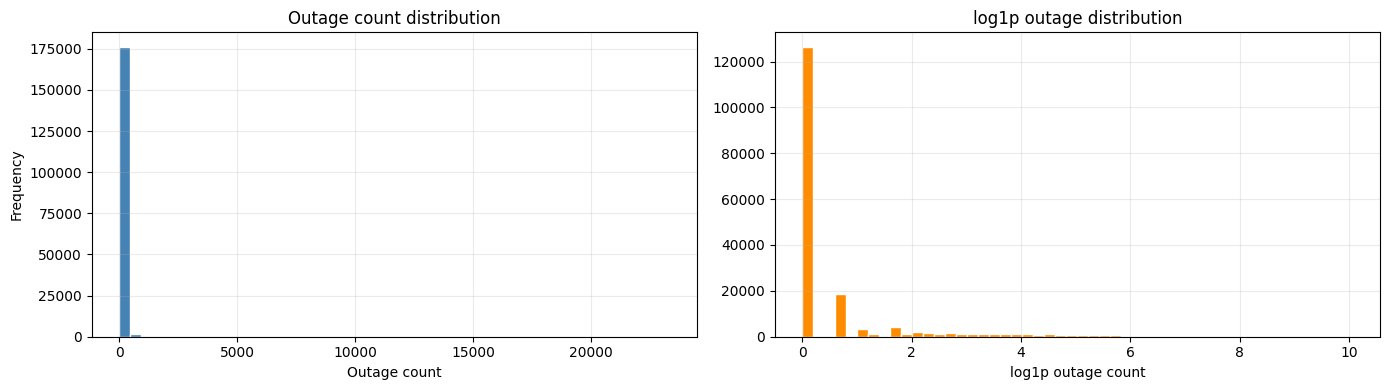

In [5]:
out_flat = ds_train.out.values.flatten().astype(float)
outage_summary = pd.Series(out_flat).describe().to_frame('outage_count')
zero_ratio = float(np.mean(out_flat == 0))
eda_summary = pd.DataFrame([
    {'metric': 'mean_outage', 'value': float(np.mean(out_flat))},
    {'metric': 'median_outage', 'value': float(np.median(out_flat))},
    {'metric': 'std_outage', 'value': float(np.std(out_flat))},
    {'metric': 'max_outage', 'value': float(np.max(out_flat))},
    {'metric': 'zero_rate', 'value': zero_ratio},
    {'metric': 'nonzero_rate', 'value': 1.0 - zero_ratio},
])

display(outage_summary)
display(eda_summary)
eda_summary.to_csv(FINAL_NOTEBOOK_DIR / 'comparison' / 'eda_summary.csv', index=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].hist(out_flat, bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('Outage count distribution')
axes[0].set_xlabel('Outage count')
axes[0].set_ylabel('Frequency')
axes[1].hist(np.log1p(out_flat), bins=50, color='darkorange', edgecolor='white')
axes[1].set_title('log1p outage distribution')
axes[1].set_xlabel('log1p outage count')
plt.tight_layout()
plt.savefig(FINAL_NOTEBOOK_DIR / 'comparison' / 'eda_outage_distribution.png', dpi=140)
plt.show()


,location,total_outage,average_outage
0,26125,1723876.0,797.721425
1,26163,1652750.0,764.807959
2,26099,920650.0,426.029616
3,26161,539997.0,249.882925
4,26081,233530.0,108.065710
5,26103,213805.0,98.937992
6,26145,200134.0,92.611754
7,26093,159502.0,73.809348
8,26115,149918.0,69.374364
9,26049,133498.0,61.776030


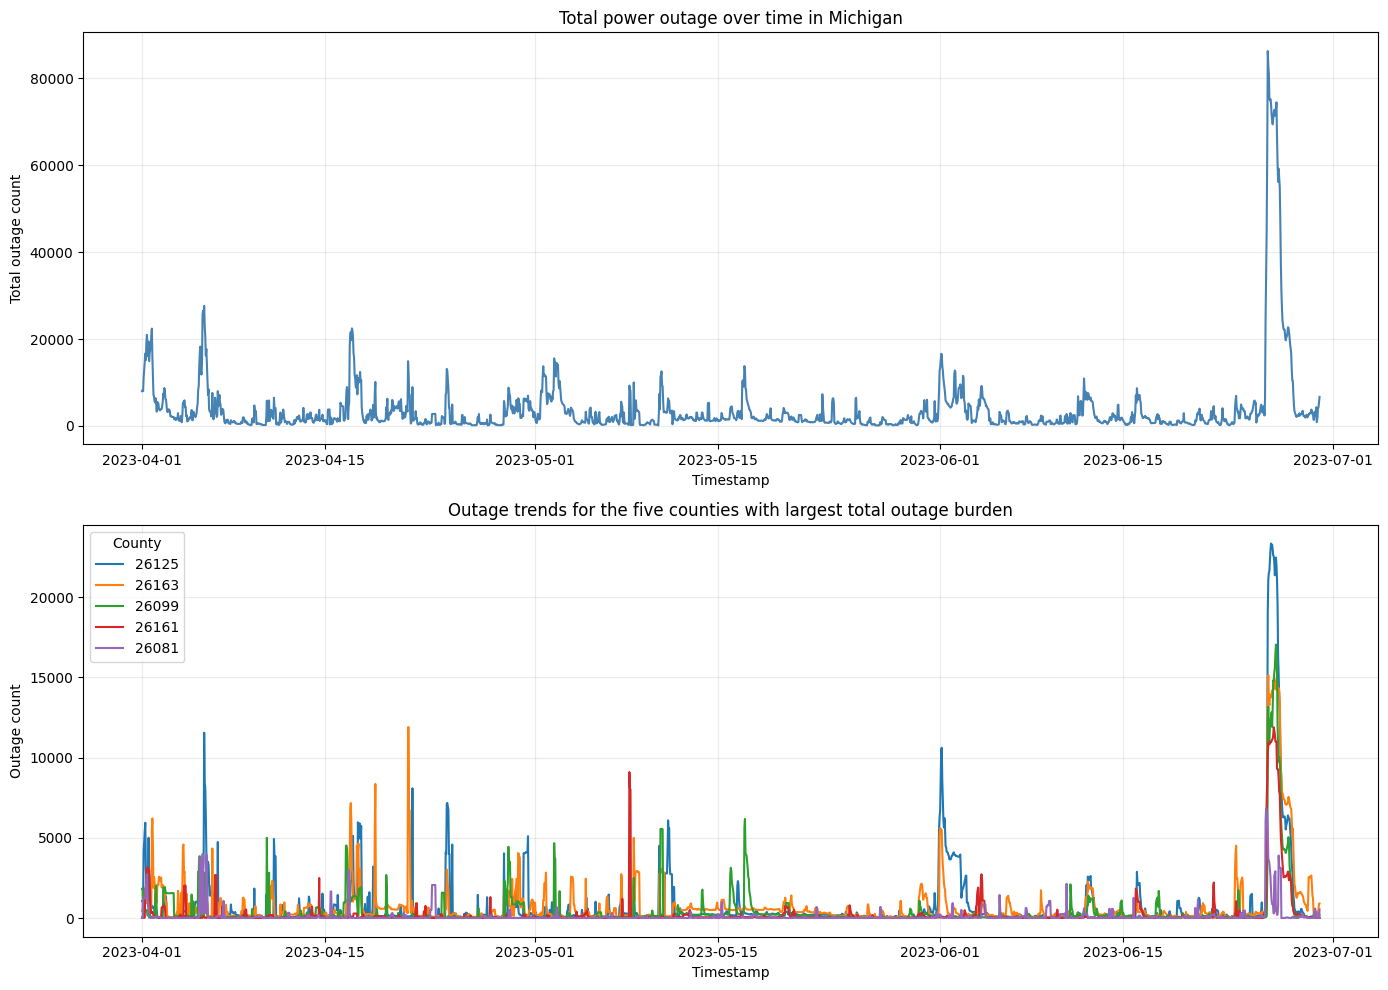

In [6]:
statewide_outage = ds_train['out'].sum(dim='location')
total_outage_by_county = ds_train['out'].sum(dim='timestamp')
avg_outage_by_county = ds_train['out'].mean(dim='timestamp')

county_summary = pd.DataFrame({
    'location': locations,
    'total_outage': total_outage_by_county.values.astype(float),
    'average_outage': avg_outage_by_county.values.astype(float),
}).sort_values('total_outage', ascending=False).reset_index(drop=True)
county_summary.to_csv(FINAL_NOTEBOOK_DIR / 'comparison' / 'eda_county_outage_summary.csv', index=False)

display(county_summary.head(10))

fig, axes = plt.subplots(2, 1, figsize=(14, 10))
axes[0].plot(train_timestamps, statewide_outage.values, color='steelblue')
axes[0].set_title('Total power outage over time in Michigan')
axes[0].set_xlabel('Timestamp')
axes[0].set_ylabel('Total outage count')

top5_counties = county_summary.head(5)['location'].tolist()
for county in top5_counties:
    county_outage = ds_train['out'].sel(location=county)
    axes[1].plot(train_timestamps, county_outage.values, label=county)
axes[1].set_title('Outage trends for the five counties with largest total outage burden')
axes[1].set_xlabel('Timestamp')
axes[1].set_ylabel('Outage count')
axes[1].legend(title='County')
plt.tight_layout()
plt.savefig(FINAL_NOTEBOOK_DIR / 'comparison' / 'eda_outage_time_series.png', dpi=140)
plt.show()


,metric,value
0,all_zero_weather_features,17
1,nonzero_weather_features,92
2,valid_correlation_features,92


All-zero weather features: ['aod', 'bgrun', 'cfrzr', 'cicep', 'crain', 'csnow', 'hail_2', 'ltng', 'prate', 'sdwe_1', 'siconc', 'ssrun', 'tcoli', 'tcolw', 'tp', 'unknown_7', 'unknown_9']
Top volatile weather features: ['pcdb', 'pres', 'vis', 'plpl', 'pres_2', 'pres_1', 'mslma', 'sp', 'gh_4', 'gh_3']


,feature,abs_corr_with_outage,signed_corr_with_outage
0,cape,0.119191,0.119191
1,pwat,0.089700,0.089700
2,sh2,0.083554,0.083554
3,gh_4,0.081504,0.081504
4,cape_1,0.073289,0.073289
5,sdlwrf,0.068874,0.068874
6,unknown_3,0.061608,0.061608
7,refc,0.059532,0.059532
8,lcc,0.055376,0.055376
9,hail,0.054625,0.054625


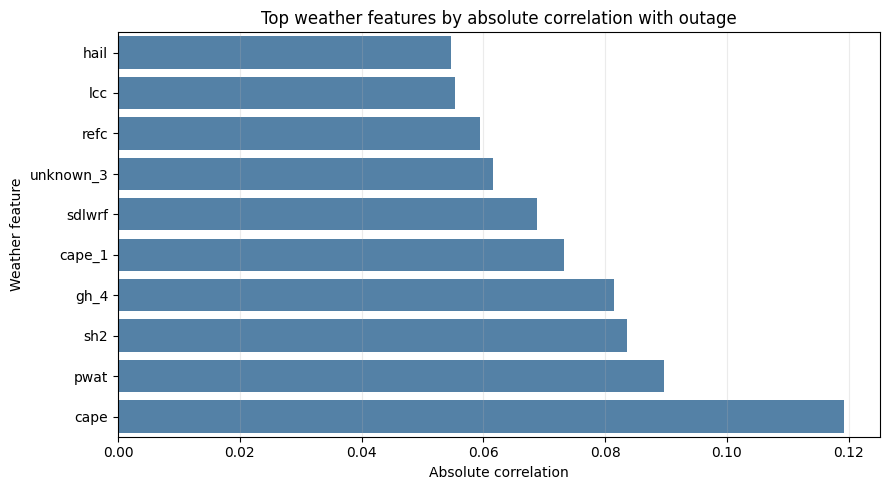

In [7]:
weather_np = weather_filled.values.astype(float)
weather_flat = weather_np.reshape(-1, weather_np.shape[-1])

all_zero_mask = np.all(weather_flat == 0, axis=0)
zero_features = [weather_features[i] for i, is_zero in enumerate(all_zero_mask) if is_zero]
non_zero_features = [feature for feature in weather_features if feature not in zero_features]

weather_std = (weather_np - np.nanmean(weather_np, axis=1, keepdims=True)) / (np.nanstd(weather_np, axis=1, keepdims=True) + 1e-6)
feature_volatility = np.nanstd(weather_std, axis=(0, 1))
top_volatile_features = [weather_features[i] for i in np.argsort(feature_volatility)[-10:][::-1]]

weather_df = pd.DataFrame(weather_flat, columns=weather_features)
weather_df['out'] = out_flat
weather_corr = weather_df[non_zero_features + ['out']].corr(numeric_only=True)['out'].drop('out')
target_corr_valid = weather_corr.replace([np.inf, -np.inf], np.nan).dropna()
top_correlated_weather = target_corr_valid.abs().sort_values(ascending=False).head(10)
selected_weather_features = top_correlated_weather.index.tolist()
all_weather_features = target_corr_valid.index.tolist()

weather_screening_summary = pd.DataFrame([
    {'metric': 'all_zero_weather_features', 'value': len(zero_features)},
    {'metric': 'nonzero_weather_features', 'value': len(non_zero_features)},
    {'metric': 'valid_correlation_features', 'value': len(all_weather_features)},
])

display(weather_screening_summary)
print('All-zero weather features:', zero_features)
print('Top volatile weather features:', top_volatile_features)
display(pd.DataFrame({
    'feature': selected_weather_features,
    'abs_corr_with_outage': top_correlated_weather.values,
    'signed_corr_with_outage': target_corr_valid.loc[selected_weather_features].values,
}))

fig, ax = plt.subplots(figsize=(9, 5))
plot_df = pd.DataFrame({'feature': selected_weather_features, 'abs_corr': top_correlated_weather.values}).sort_values('abs_corr')
if sns is not None:
    sns.barplot(data=plot_df, x='abs_corr', y='feature', color='steelblue', ax=ax)
else:
    ax.barh(plot_df['feature'], plot_df['abs_corr'], color='steelblue')
ax.set_title('Top weather features by absolute correlation with outage')
ax.set_xlabel('Absolute correlation')
ax.set_ylabel('Weather feature')
plt.tight_layout()
plt.savefig(FINAL_NOTEBOOK_DIR / 'comparison' / 'eda_top_weather_correlations.png', dpi=140)
plt.show()


### 5.1 Location and Weather Feature Diagnostics

The additional diagnostics below retain the original exploratory emphasis on county heterogeneity and weather-feature structure. The plots and tables are intentionally descriptive: they show which counties dominate the outage burden, whether the weather matrix contains degenerate features or samples, and which weather variables are most correlated with one another and with outage counts.


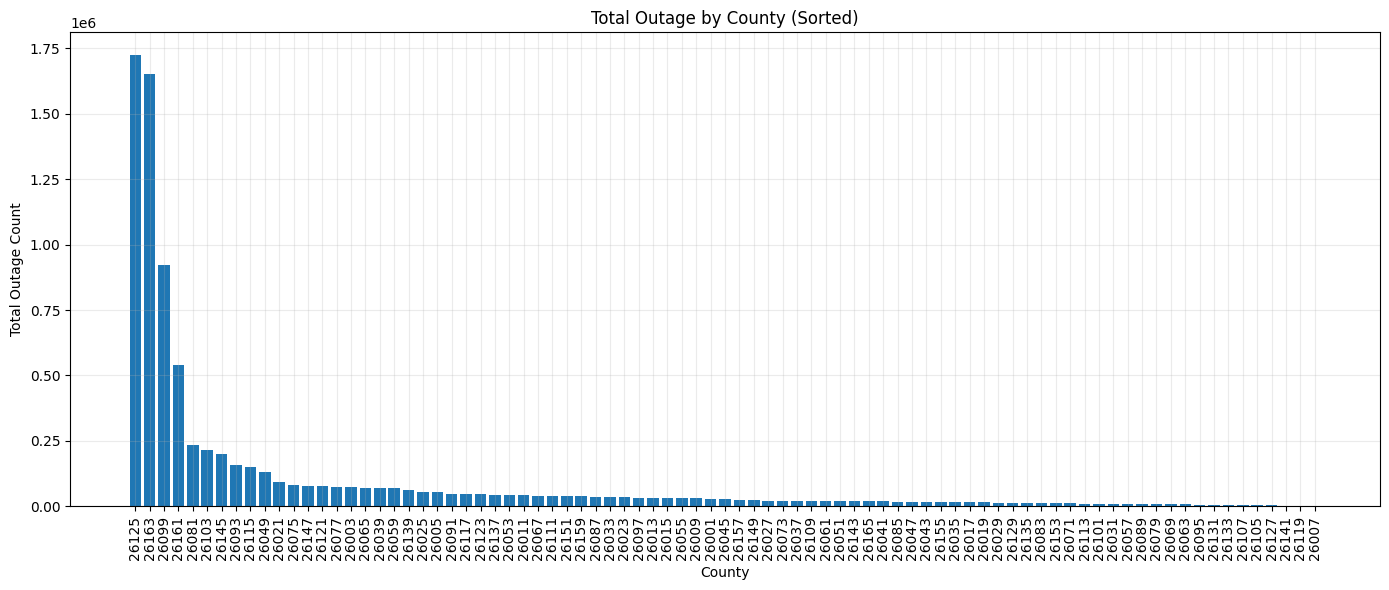

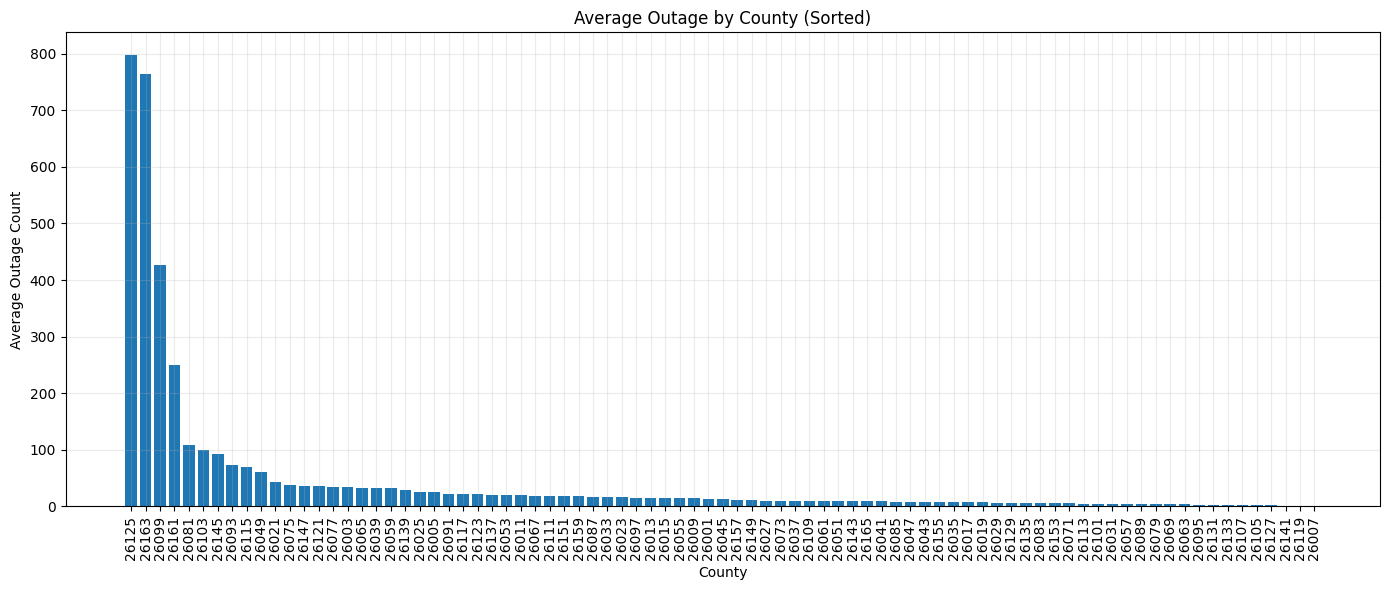

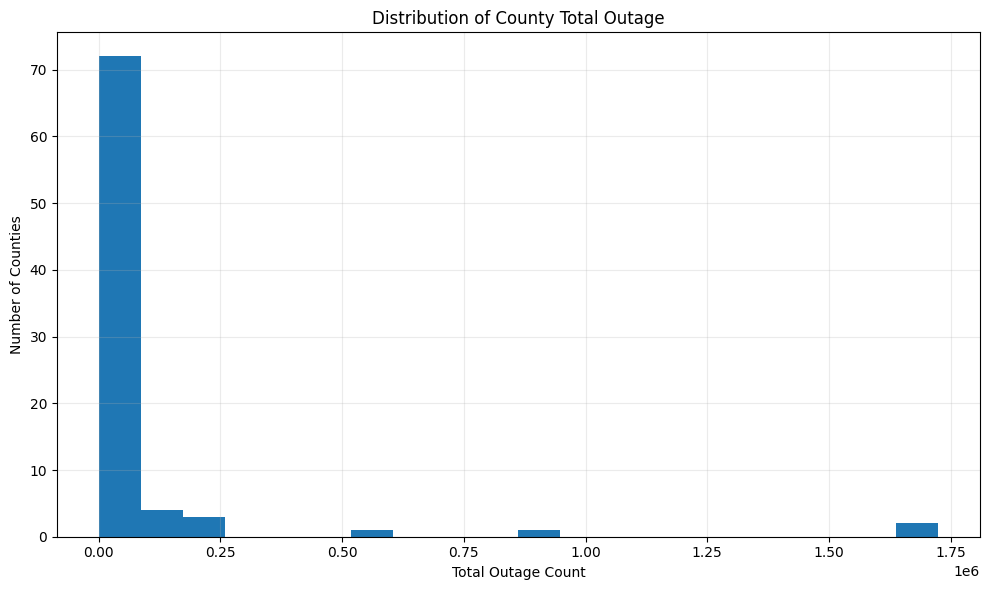

,metric,value
0,n_all_zero_features,17.000000
1,n_all_zero_samples,166.000000
2,all_zero_sample_ratio,0.000925


All-zero weather features:
['aod', 'bgrun', 'cfrzr', 'cicep', 'crain', 'csnow', 'hail_2', 'ltng', 'prate', 'sdwe_1', 'siconc', 'ssrun', 'tcoli', 'tcolw', 'tp', 'unknown_7', 'unknown_9']


,feature_1,feature_2,correlation
0,SBT114,SBT124,0.995986
1,SBT124,SBT114,0.995986
2,t,pt,0.978391
3,pt,t,0.978391
4,r,r_1,0.976330
5,r_1,r,0.976330
6,gh_7,gh_6,0.975932
7,gh_6,gh_7,0.975932
8,sdwe,sde,0.975533
9,sde,sdwe,0.975533


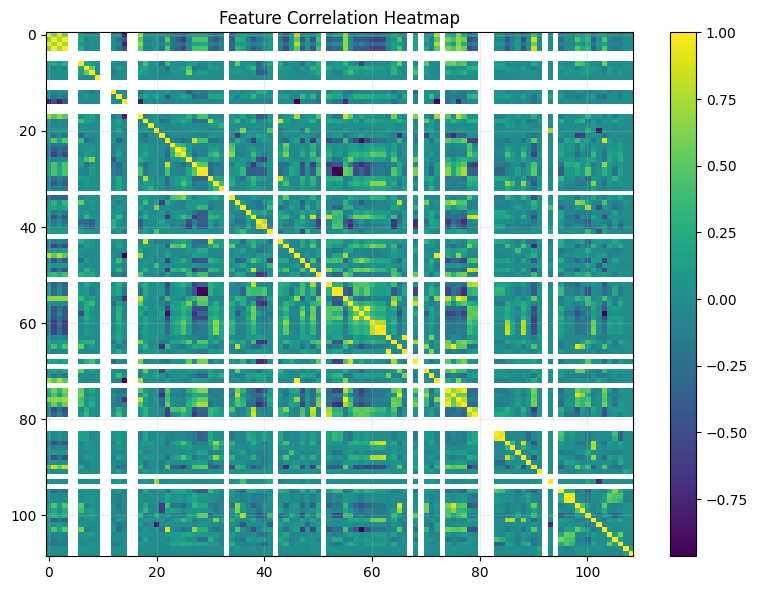

Top positively correlated features:
cape         0.119191
pwat         0.089700
sh2          0.083554
gh_4         0.081504
cape_1       0.073289
sdlwrf       0.068874
unknown_3    0.061608
refc         0.059532
lcc          0.055376
hail         0.054625
Name: out, dtype: float64
Top negatively correlated features:
ltng        NaN
prate       NaN
sdwe_1      NaN
siconc      NaN
ssrun       NaN
tcoli       NaN
tcolw       NaN
tp          NaN
unknown_7   NaN
unknown_9   NaN
Name: out, dtype: float64


,top_positive_correlation,top_negative_correlation
cape,0.119191,NaN
pwat,0.089700,NaN
sh2,0.083554,NaN
gh_4,0.081504,NaN
cape_1,0.073289,NaN
sdlwrf,0.068874,NaN
unknown_3,0.061608,NaN
refc,0.059532,NaN
lcc,0.055376,NaN
hail,0.054625,NaN


In [8]:
# Location-level diagnostics: total outage, average outage, and county-level distribution.
total_outage_by_county_exact = ds_train['out'].sum(dim='timestamp')
avg_outage_by_county_exact = ds_train['out'].mean(dim='timestamp')
counties_exact = ds_train['location'].values

sorted_idx_total = np.argsort(total_outage_by_county_exact.values)[::-1]
sorted_counties_total = counties_exact[sorted_idx_total]
sorted_total_outage = total_outage_by_county_exact.values[sorted_idx_total]

sorted_idx_avg = np.argsort(avg_outage_by_county_exact.values)[::-1]
sorted_counties_avg = counties_exact[sorted_idx_avg]
sorted_avg_outage = avg_outage_by_county_exact.values[sorted_idx_avg]

location_diagnostics = pd.DataFrame({
    'location': [str(x) for x in counties_exact],
    'total_outage': total_outage_by_county_exact.values.astype(float),
    'average_outage': avg_outage_by_county_exact.values.astype(float),
})
location_diagnostics.to_csv(OUTPUT_DIRS['comparison'] / 'eda_location_diagnostics.csv', index=False)

plt.figure(figsize=(14, 6))
plt.bar(sorted_counties_total.astype(str), sorted_total_outage)
plt.title('Total Outage by County (Sorted)')
plt.xlabel('County')
plt.ylabel('Total Outage Count')
plt.xticks(rotation=90)
plt.tight_layout()
plt.savefig(OUTPUT_DIRS['comparison'] / 'eda_total_outage_by_county_sorted.png', dpi=140)
plt.show()

plt.figure(figsize=(14, 6))
plt.bar(sorted_counties_avg.astype(str), sorted_avg_outage)
plt.title('Average Outage by County (Sorted)')
plt.xlabel('County')
plt.ylabel('Average Outage Count')
plt.xticks(rotation=90)
plt.tight_layout()
plt.savefig(OUTPUT_DIRS['comparison'] / 'eda_average_outage_by_county_sorted.png', dpi=140)
plt.show()

plt.figure(figsize=(10, 6))
plt.hist(total_outage_by_county_exact.values, bins=20)
plt.title('Distribution of County Total Outage')
plt.xlabel('Total Outage Count')
plt.ylabel('Number of Counties')
plt.tight_layout()
plt.savefig(OUTPUT_DIRS['comparison'] / 'eda_county_total_outage_histogram.png', dpi=140)
plt.show()

# Weather matrix diagnostics: all-zero features/samples, inter-feature correlation, and target correlation.
weather_flat_exact = weather_filled.values.reshape(-1, weather_filled.shape[-1])
all_zero_feature_mask_exact = np.all(weather_flat_exact == 0, axis=0)
zero_features_exact = [weather_features[i] for i in range(len(weather_features)) if all_zero_feature_mask_exact[i]]
all_zero_sample_mask_exact = np.all(weather_flat_exact == 0, axis=1)
num_all_zero_samples = int(np.sum(all_zero_sample_mask_exact))

weather_degeneracy_table = pd.DataFrame([
    {'metric': 'n_all_zero_features', 'value': len(zero_features_exact)},
    {'metric': 'n_all_zero_samples', 'value': num_all_zero_samples},
    {'metric': 'all_zero_sample_ratio', 'value': num_all_zero_samples / len(weather_flat_exact)},
])
display(weather_degeneracy_table)
print('All-zero weather features:')
print(zero_features_exact)
weather_degeneracy_table.to_csv(OUTPUT_DIRS['comparison'] / 'eda_weather_degeneracy.csv', index=False)

weather_feature_df = pd.DataFrame(weather_flat_exact, columns=weather_features)
corr_matrix = weather_feature_df.corr()
corr_pairs = corr_matrix.unstack().sort_values(ascending=False)
corr_pairs = corr_pairs[corr_pairs < 0.999]
top_corr_pairs = corr_pairs.head(10).reset_index()
top_corr_pairs.columns = ['feature_1', 'feature_2', 'correlation']
display(top_corr_pairs)
top_corr_pairs.to_csv(OUTPUT_DIRS['comparison'] / 'eda_top_weather_feature_correlations.csv', index=False)

plt.figure(figsize=(8, 6))
plt.imshow(corr_matrix, aspect='auto')
plt.colorbar()
plt.title('Feature Correlation Heatmap')
plt.tight_layout()
plt.savefig(OUTPUT_DIRS['comparison'] / 'eda_weather_feature_correlation_heatmap.png', dpi=140)
plt.show()

weather_feature_df['out'] = ds_train.out.values.flatten()
target_corr_sorted = weather_feature_df.corr(numeric_only=True)['out'].drop('out').sort_values(ascending=False)
target_corr_extremes = pd.concat([
    target_corr_sorted.head(10).rename('top_positive_correlation'),
    target_corr_sorted.tail(10).rename('top_negative_correlation'),
], axis=1)
print('Top positively correlated features:')
print(target_corr_sorted.head(10))
print('Top negatively correlated features:')
print(target_corr_sorted.tail(10))
display(target_corr_extremes)
target_corr_sorted.reset_index().rename(columns={'index': 'feature', 'out': 'correlation_with_outage'}).to_csv(
    OUTPUT_DIRS['comparison'] / 'eda_weather_target_correlations_signed.csv',
    index=False,
)


In [9]:
T = ds_train_clean.dims['timestamp']
split_idx = int((1 - SETTINGS['validation_split']) * T)
all_timestamps = pd.to_datetime(ds_train_clean.timestamp.values)
train_ts = all_timestamps[:split_idx]
val_ts = all_timestamps[split_idx:]
train_data = ds_train_clean.isel(timestamp=slice(0, split_idx))
val_data = ds_train_clean.isel(timestamp=slice(split_idx, None))

print(f'Total timestamps: {T}')
print(f'Train timestamps: {len(train_ts)} ({train_ts[0]} to {train_ts[-1]})')
print(f'Validation timestamps: {len(val_ts)} ({val_ts[0]} to {val_ts[-1]})')

val_truth_24h = val_data.out.transpose('timestamp', 'location').isel(timestamp=slice(0, 24)).values.astype(float)
val_truth_48h = val_data.out.transpose('timestamp', 'location').isel(timestamp=slice(0, 48)).values.astype(float)


def calculate_avg_county_rmse(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    if y_true.shape != y_pred.shape:
        raise ValueError(f'Shape mismatch: y_true {y_true.shape} vs y_pred {y_pred.shape}')
    county_rmse = np.sqrt(np.mean((y_true - y_pred) ** 2, axis=0))
    return float(np.mean(county_rmse))


zero_pred_24h = np.zeros_like(val_truth_24h)
zero_pred_48h = np.zeros_like(val_truth_48h)
rmse_zero_24h = calculate_avg_county_rmse(val_truth_24h, zero_pred_24h)
rmse_zero_48h = calculate_avg_county_rmse(val_truth_48h, zero_pred_48h)

register_metric('baseline', 'zero', 'Zero baseline', 24, rmse_zero_24h, 'Computed from shared validation split')
register_metric('baseline', 'zero', 'Zero baseline', 48, rmse_zero_48h, 'Computed from shared validation split')

baseline_metrics = pd.DataFrame([
    {'model': 'Zero baseline', 'horizon': 24, 'validation_rmse': rmse_zero_24h},
    {'model': 'Zero baseline', 'horizon': 48, 'validation_rmse': rmse_zero_48h},
])
display(baseline_metrics)


Total timestamps: 2161
Train timestamps: 1728 (2023-04-01 00:00:00 to 2023-06-11 23:00:00)
Validation timestamps: 433 (2023-06-12 00:00:00 to 2023-06-30 00:00:00)


,model,horizon,validation_rmse
0,Zero baseline,24,100.305327
1,Zero baseline,48,75.356110


## 6. SARIMA / SARIMAX

This section evaluates the classical time-series model family. The modeling path is intentionally exhaustive rather than compressed: first, a county-specific SARIMA baseline is trained; next, the counties with the largest validation errors are tuned using a full non-seasonal grid; then seasonal SARIMA candidates are evaluated for the most difficult counties; finally, SARIMAX alternatives with weather covariates are benchmarked. This preserves the full experimental record while still exposing one selected SARIMA-family variant to the downstream model-comparison and generator-allocation sections.

The selected SARIMA-family model is the seasonal top-10 strategy. SARIMAX is included because it is a natural design alternative, but in validation it performed worse than the SARIMA variants, likely because the weather feature space is high dimensional relative to each county's outage history and because future weather covariates are not available in the operational prediction setting.


### 6.1 SARIMA Setup

The helper functions below use the same county-wise state-space formulation throughout the section. Each county receives its own model because outage behavior is highly localized. Forecasts are clipped at zero because the response variable is a nonnegative outage count. The average county RMSE is used consistently with the project evaluation metric: compute the RMSE separately for each county, then average across counties.


In [10]:
SARIMA_DIR = APPROACH_DIRS['sarima']
SARIMA_INPUTS_DIR = SARIMA_DIR / 'inputs'
SARIMA_OUTPUTS_DIR = SARIMA_DIR / 'outputs'
SARIMA_TABLES_DIR = SARIMA_DIR / 'tables'
SARIMA_PLOTS_DIR = SARIMA_DIR / 'plots'
SARIMA_PREDICTIONS_DIR = SARIMA_DIR / 'predictions'
SARIMA_MODELS_DIR = SARIMA_DIR / 'models'
for path in [SARIMA_INPUTS_DIR, SARIMA_OUTPUTS_DIR, SARIMA_TABLES_DIR, SARIMA_PLOTS_DIR, SARIMA_PREDICTIONS_DIR, SARIMA_MODELS_DIR]:
    path.mkdir(parents=True, exist_ok=True)

try:
    from statsmodels.tsa.statespace.sarimax import SARIMAX
except Exception as exc:
    SARIMAX = None
    print('statsmodels SARIMAX is unavailable. Install statsmodels before running this section.')

try:
    import joblib
except Exception:
    joblib = None

import itertools
import warnings
warnings.filterwarnings('ignore')

SARIMA_ORDER = tuple(SETTINGS['sarima_order'])
pdq_combinations = list(itertools.product(
    SETTINGS['sarima_grid_p'],
    SETTINGS['sarima_grid_d'],
    SETTINGS['sarima_grid_q'],
))
seasonal_order_list = list(SETTINGS['sarima_seasonal_order_candidates'])


def sarima_location_key(ds, loc):
    lookup = {str(value): value for value in ds.location.values}
    return lookup.get(str(loc), loc)


def rmse(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    return float(np.sqrt(np.mean((y_true - y_pred) ** 2)))


def safe_fit_sarima(y, order=(1, 0, 1), seasonal_order=None):
    y = np.asarray(y, dtype=float).flatten()
    if len(y) < 8 or np.allclose(y, y[0]):
        return None
    try:
        kwargs = {
            'order': tuple(order),
            'enforce_stationarity': False,
            'enforce_invertibility': False,
        }
        if seasonal_order is not None:
            kwargs['seasonal_order'] = tuple(seasonal_order)
        model = SARIMAX(y, **kwargs)
        res = model.fit(disp=False)
        return res
    except Exception as exc:
        print(f'  Warning: SARIMA fit failed - {str(exc)[:80]}')
        return None


def generate_sarima_predictions(models_dict, prediction_locations, prediction_timestamps):
    rows = []
    timestamps = pd.to_datetime(prediction_timestamps)
    n_steps = len(timestamps)

    for loc in prediction_locations:
        loc_str = str(loc)
        model = models_dict.get(loc_str)
        if model is not None:
            try:
                pred = np.asarray(model.forecast(steps=n_steps), dtype=float)
                pred = np.clip(pred, 0, None)
            except Exception:
                pred = np.zeros(n_steps)
        else:
            pred = np.zeros(n_steps)

        rows.append(pd.DataFrame({
            'timestamp': timestamps,
            'location': loc_str,
            'pred': pred,
        }))

    return pd.concat(rows, ignore_index=True)


def evaluate_per_county(truth, pred_df, prediction_locations):
    rmses = []
    for i, loc in enumerate(prediction_locations):
        loc_str = str(loc)
        loc_pred = pred_df[pred_df['location'].astype(str) == loc_str]['pred'].values
        if len(loc_pred) == truth.shape[0]:
            county_rmse = rmse(truth[:, i], loc_pred)
            rmses.append(county_rmse)
        else:
            rmses.append(np.nan)
    return rmses


def fit_base_sarima_models(ds_source):
    models = {}
    for loc in locations:
        print(f'Fitting SARIMA for {loc}...', end=' ')
        y_train = ds_source.out.sel(location=sarima_location_key(ds_source, loc)).values.astype(float).flatten()
        model = safe_fit_sarima(y_train, order=SARIMA_ORDER)
        models[str(loc)] = model
        if model is not None:
            print(f'Success (AIC: {model.aic:.2f})')
        else:
            print('Failed; using zero baseline for this county')
    return models


def fit_best_nonseasonal_model(y_train_loc):
    best_aic = float('inf')
    best_order = None
    best_model_res = None
    for order in pdq_combinations:
        try:
            model = SARIMAX(
                y_train_loc,
                order=order,
                enforce_stationarity=False,
                enforce_invertibility=False,
            )
            res = model.fit(disp=False)
            if res.aic < best_aic:
                best_aic = res.aic
                best_order = order
                best_model_res = res
        except Exception:
            continue
    return best_order, best_aic, best_model_res


def fit_best_seasonal_model(y_train_loc):
    best_aic = float('inf')
    best_order = None
    best_seasonal_order = None
    best_model_res = None
    for order in pdq_combinations:
        for seasonal_order in seasonal_order_list:
            try:
                model = SARIMAX(
                    y_train_loc,
                    order=order,
                    seasonal_order=seasonal_order,
                    enforce_stationarity=False,
                    enforce_invertibility=False,
                )
                res = model.fit(disp=False)
                if res.aic < best_aic:
                    best_aic = res.aic
                    best_order = order
                    best_seasonal_order = seasonal_order
                    best_model_res = res
            except Exception:
                continue
    return best_order, best_seasonal_order, best_aic, best_model_res


def extract_model_spec(model):
    if model is None:
        return {'order': SARIMA_ORDER, 'seasonal_order': None}
    model_obj = getattr(model, 'model', None)
    order = getattr(model_obj, 'order', SARIMA_ORDER)
    seasonal_order = getattr(model_obj, 'seasonal_order', None)
    if seasonal_order in [None, (0, 0, 0, 0)]:
        seasonal_order = None
    return {
        'order': tuple(order),
        'seasonal_order': None if seasonal_order is None else tuple(seasonal_order),
    }


def refit_model_map_on_full_history(selected_models):
    final_models = {}
    for loc in locations:
        spec = extract_model_spec(selected_models.get(str(loc)))
        y_full = ds_train_clean.out.sel(location=sarima_location_key(ds_train_clean, loc)).values.astype(float).flatten()
        final_models[str(loc)] = safe_fit_sarima(
            y_full,
            order=spec['order'],
            seasonal_order=spec['seasonal_order'],
        )
    return final_models


def save_model_map(model_map, filename):
    if joblib is None:
        print('joblib is unavailable; model map was not serialized.')
        return None
    path = SARIMA_MODELS_DIR / filename
    joblib.dump(model_map, path)
    print(f'Saved model map to {path.relative_to(PROJECT_ROOT)}')
    return path


def save_table(df, filename):
    path = SARIMA_TABLES_DIR / filename
    df.to_csv(path, index=False)
    return path


val_timestamps_24h = val_ts[:24]
val_timestamps_48h = val_ts[:48]


### 6.2 Base County-Level SARIMA

The base model fits a SARIMA(1, 0, 1) process independently for every county. This is the transparent benchmark for the family: it uses only historical outage behavior and does not rely on exogenous weather features. Its purpose is to establish whether short-term outage persistence and autoregressive structure alone provide a competitive validation score.


In [11]:
if SETTINGS['rerun_training'].get('sarima', False):
    print('Training base SARIMA models, one per county.')
    sarima_models_base = fit_base_sarima_models(train_data)

    sarima_val_pred_24h_df = generate_sarima_predictions(sarima_models_base, locations, val_timestamps_24h)
    sarima_val_pred_48h_df = generate_sarima_predictions(sarima_models_base, locations, val_timestamps_48h)

    sarima_24h_rmses = evaluate_per_county(val_truth_24h, sarima_val_pred_24h_df, locations)
    sarima_48h_rmses = evaluate_per_county(val_truth_48h, sarima_val_pred_48h_df, locations)
    zero_24h_rmses = [rmse(val_truth_24h[:, i], np.zeros(24)) for i in range(len(locations))]
    zero_48h_rmses = [rmse(val_truth_48h[:, i], np.zeros(48)) for i in range(len(locations))]

    sarima_24h_avg = np.nanmean(sarima_24h_rmses)
    sarima_48h_avg = np.nanmean(sarima_48h_rmses)
    zero_24h_avg = np.nanmean(zero_24h_rmses)
    zero_48h_avg = np.nanmean(zero_48h_rmses)

    base_metrics = pd.DataFrame([
        {'variant_key': 'sarima_base', 'display_model': 'Base SARIMA(1,0,1)', 'horizon': 24, 'validation_rmse': sarima_24h_avg, 'zero_baseline_rmse': zero_24h_avg},
        {'variant_key': 'sarima_base', 'display_model': 'Base SARIMA(1,0,1)', 'horizon': 48, 'validation_rmse': sarima_48h_avg, 'zero_baseline_rmse': zero_48h_avg},
    ])
    display(base_metrics)
    save_table(base_metrics, 'sarima_base_validation_metrics.csv')

    top_worst_counties_24h = (
        pd.DataFrame({'location': locations, 'rmse_24h': sarima_24h_rmses})
        .sort_values('rmse_24h', ascending=False)
        .reset_index(drop=True)
    )
    top_worst_counties_48h = (
        pd.DataFrame({'location': locations, 'rmse_48h': sarima_48h_rmses})
        .sort_values('rmse_48h', ascending=False)
        .reset_index(drop=True)
    )
    save_table(top_worst_counties_24h, 'sarima_base_per_county_rmse_24h.csv')
    save_table(top_worst_counties_48h, 'sarima_base_per_county_rmse_48h.csv')

    print('Top 10 counties with highest validation RMSE, 24h:')
    display(top_worst_counties_24h.head(10))
    print('Top 10 counties with highest validation RMSE, 48h:')
    display(top_worst_counties_48h.head(10))

    sarima_models = sarima_models_base.copy()
else:
    print('SARIMA rerun is disabled. Existing SARIMA tables and predictions will be loaded later in this section.')


Training base SARIMA models, one per county.
Fitting SARIMA for 26001... Success (AIC: 22096.92)
Fitting SARIMA for 26003... Success (AIC: 20784.05)
Fitting SARIMA for 26005... Success (AIC: 20906.27)
Fitting SARIMA for 26007... Success (AIC: 10571.37)
Fitting SARIMA for 26009... Success (AIC: 21046.83)
Fitting SARIMA for 26011... Success (AIC: 14277.84)
Fitting SARIMA for 26013... Success (AIC: 16943.51)
Fitting SARIMA for 26015... Success (AIC: 17215.83)
Fitting SARIMA for 26017... Success (AIC: 15446.86)
Fitting SARIMA for 26019... Success (AIC: 18714.02)
Fitting SARIMA for 26021... Success (AIC: 20195.76)
Fitting SARIMA for 26023... Success (AIC: 22001.14)
Fitting SARIMA for 26025... Success (AIC: 22864.04)
Fitting SARIMA for 26027... Success (AIC: 19346.13)
Fitting SARIMA for 26029... Success (AIC: 17981.47)
Fitting SARIMA for 26031... Success (AIC: 17534.75)
Fitting SARIMA for 26033... Success (AIC: 20349.10)
Fitting SARIMA for 26035... Success (AIC: 16280.90)
Fitting SARIMA for 

,variant_key,display_model,horizon,validation_rmse,zero_baseline_rmse
0,sarima_base,"Base SARIMA(1,0,1)",24,89.744951,100.305327
1,sarima_base,"Base SARIMA(1,0,1)",48,68.360634,75.356110


Top 10 counties with highest validation RMSE, 24h:


,location,rmse_24h
0,26125,1626.676181
1,26163,1385.476389
2,26099,786.798246
3,26139,712.500698
4,26087,606.525192
5,26115,314.551063
6,26021,260.230040
7,26065,222.754602
8,26049,208.925794
9,26093,146.467487


Top 10 counties with highest validation RMSE, 48h:


,location,rmse_48h
0,26125,1154.226711
1,26163,992.208309
2,26099,569.362720
3,26139,516.697623
4,26087,431.068537
5,26115,222.456527
6,26021,188.639275
7,26065,163.660326
8,26049,162.321998
9,26081,137.590448


### 6.3 Non-Seasonal Order Tuning for the Top 10 Counties

The first refinement tunes only the ten counties with the largest base SARIMA validation errors. The grid is the full set of non-seasonal `(p, d, q)` combinations with `p, q in {0, 1, 2}` and `d in {0, 1}`. This targeted search avoids unnecessary tuning for counties where the baseline is already adequate, while focusing capacity on the counties that dominate the average county RMSE.


In [12]:
if SETTINGS['rerun_training'].get('sarima', False):
    top_10_locations_24h = top_worst_counties_24h['location'].head(10).astype(str).tolist()
    best_orders_top10_24h = {}

    print('Tuning non-seasonal SARIMA orders for top 10 counties, 24h horizon.')
    sarima_models_top10_24h_tuned = sarima_models.copy()
    for loc in top_10_locations_24h:
        y_train_loc = train_data.out.sel(location=sarima_location_key(train_data, loc)).values.astype(float).flatten()
        best_order, best_aic, best_model_res = fit_best_nonseasonal_model(y_train_loc)
        if best_order is not None:
            print(f'  {loc}: best order {best_order}, AIC={best_aic:.2f}')
            best_orders_top10_24h[loc] = best_order
            sarima_models_top10_24h_tuned[str(loc)] = best_model_res
        else:
            print(f'  {loc}: no valid tuned order found')

    tuned_preds_top10_24h_df = generate_sarima_predictions(sarima_models_top10_24h_tuned, top_10_locations_24h, val_timestamps_24h)
    comparison_rows = []
    fallback_rows = []
    final_validated_models_top10_24h = sarima_models_top10_24h_tuned.copy()
    for loc in top_10_locations_24h:
        loc_idx = locations.index(str(loc))
        original_rmse_val = sarima_24h_rmses[loc_idx]
        loc_pred = tuned_preds_top10_24h_df[tuned_preds_top10_24h_df['location'].astype(str) == str(loc)]['pred'].values
        truth_loc = val_truth_24h[:, loc_idx]
        tuned_rmse = rmse(truth_loc, loc_pred) if len(loc_pred) == len(truth_loc) else np.nan
        comparison_rows.append({
            'Location': loc,
            'Original Order': SARIMA_ORDER,
            'Original RMSE': original_rmse_val,
            'Tuned Order': best_orders_top10_24h.get(loc, 'Failed'),
            'Tuned RMSE': tuned_rmse,
            'Improvement (%)': ((original_rmse_val - tuned_rmse) / original_rmse_val * 100) if original_rmse_val > 0 else 0,
        })

        y_train_loc = train_data.out.sel(location=sarima_location_key(train_data, loc)).values.astype(float).flatten()
        base_model = safe_fit_sarima(y_train_loc, order=SARIMA_ORDER)
        tuned_model = sarima_models_top10_24h_tuned.get(str(loc))
        base_pred = generate_sarima_predictions({str(loc): base_model}, [loc], val_timestamps_24h)
        tuned_pred = generate_sarima_predictions({str(loc): tuned_model}, [loc], val_timestamps_24h)
        base_rmse = rmse(truth_loc, base_pred['pred'].values) if base_model is not None else float('inf')
        tuned_rmse = rmse(truth_loc, tuned_pred['pred'].values) if tuned_model is not None else float('inf')
        if tuned_rmse < base_rmse:
            final_validated_models_top10_24h[str(loc)] = tuned_model
            winner = 'Tuned'
            final_rmse = tuned_rmse
        else:
            final_validated_models_top10_24h[str(loc)] = base_model
            winner = 'Base'
            final_rmse = base_rmse
        fallback_rows.append({
            'Location': loc,
            'Base Order': SARIMA_ORDER,
            'Base RMSE': base_rmse,
            'Tuned Order': best_orders_top10_24h.get(loc, 'Failed'),
            'Tuned RMSE': tuned_rmse,
            'Winner': winner,
            'Final RMSE': final_rmse,
        })

    top10_24h_comparison = pd.DataFrame(comparison_rows)
    top10_24h_fallback = pd.DataFrame(fallback_rows)
    display(top10_24h_comparison.round(4))
    display(top10_24h_fallback.round(4))
    save_table(top10_24h_comparison, 'sarima_top10_nonseasonal_comparison_24h.csv')
    save_table(top10_24h_fallback, 'sarima_top10_nonseasonal_fallback_24h.csv')

    validated_all_preds_24h_top10 = generate_sarima_predictions(final_validated_models_top10_24h, locations, val_timestamps_24h)
    validated_all_rmses_24h_top10 = evaluate_per_county(val_truth_24h, validated_all_preds_24h_top10, locations)
    validated_all_avg_24h_top10 = np.nanmean(validated_all_rmses_24h_top10)
    print(f'Original overall average RMSE, 24h: {sarima_24h_avg:.4f}')
    print(f'Top-10 non-seasonal fallback average RMSE, 24h: {validated_all_avg_24h_top10:.4f}')
    sarima_models = final_validated_models_top10_24h.copy()

    top_10_locations_48h = top_worst_counties_48h['location'].head(10).astype(str).tolist()
    best_orders_top10_48h = {}
    sarima_models_48h_top10 = {}
    print('Tuning non-seasonal SARIMA orders for top 10 counties, 48h horizon.')
    for loc in top_10_locations_48h:
        y_train_loc = train_data.out.sel(location=sarima_location_key(train_data, loc)).values.astype(float).flatten()
        best_order, best_aic, best_model_res = fit_best_nonseasonal_model(y_train_loc)
        if best_order is not None:
            print(f'  {loc}: best order {best_order}, AIC={best_aic:.2f}')
            best_orders_top10_48h[loc] = best_order
            sarima_models_48h_top10[str(loc)] = best_model_res
        else:
            print(f'  {loc}: no valid tuned order found')

    tuned_preds_top10_48h_df = generate_sarima_predictions(sarima_models_48h_top10, top_10_locations_48h, val_timestamps_48h)
    comparison_rows = []
    fallback_rows = []
    final_validated_models_48h_top10 = sarima_models.copy()
    for loc in top_10_locations_48h:
        loc_idx = locations.index(str(loc))
        original_rmse_val = sarima_48h_rmses[loc_idx]
        loc_pred = tuned_preds_top10_48h_df[tuned_preds_top10_48h_df['location'].astype(str) == str(loc)]['pred'].values
        truth_loc = val_truth_48h[:, loc_idx]
        tuned_rmse = rmse(truth_loc, loc_pred) if len(loc_pred) == len(truth_loc) else np.nan
        comparison_rows.append({
            'Location': loc,
            'Original Order': SARIMA_ORDER,
            'Original RMSE': original_rmse_val,
            'Tuned Order': best_orders_top10_48h.get(loc, 'Failed'),
            'Tuned RMSE': tuned_rmse,
            'Improvement (%)': ((original_rmse_val - tuned_rmse) / original_rmse_val * 100) if original_rmse_val > 0 else 0,
        })

        y_train_loc = train_data.out.sel(location=sarima_location_key(train_data, loc)).values.astype(float).flatten()
        base_model = safe_fit_sarima(y_train_loc, order=SARIMA_ORDER)
        tuned_model = sarima_models_48h_top10.get(str(loc))
        base_pred = generate_sarima_predictions({str(loc): base_model}, [loc], val_timestamps_48h)
        tuned_pred = generate_sarima_predictions({str(loc): tuned_model}, [loc], val_timestamps_48h)
        base_rmse = rmse(truth_loc, base_pred['pred'].values) if base_model is not None else float('inf')
        tuned_rmse = rmse(truth_loc, tuned_pred['pred'].values) if tuned_model is not None else float('inf')
        if tuned_rmse < base_rmse:
            final_validated_models_48h_top10[str(loc)] = tuned_model
            winner = 'Tuned'
            final_rmse = tuned_rmse
        else:
            final_validated_models_48h_top10[str(loc)] = base_model
            winner = 'Base'
            final_rmse = base_rmse
        fallback_rows.append({
            'Location': loc,
            'Base Order': SARIMA_ORDER,
            'Base RMSE': base_rmse,
            'Tuned Order': best_orders_top10_48h.get(loc, 'Failed'),
            'Tuned RMSE': tuned_rmse,
            'Winner': winner,
            'Final RMSE': final_rmse,
        })

    top10_48h_comparison = pd.DataFrame(comparison_rows)
    top10_48h_fallback = pd.DataFrame(fallback_rows)
    display(top10_48h_comparison.round(4))
    display(top10_48h_fallback.round(4))
    save_table(top10_48h_comparison, 'sarima_top10_nonseasonal_comparison_48h.csv')
    save_table(top10_48h_fallback, 'sarima_top10_nonseasonal_fallback_48h.csv')
    validated_all_preds_48h_top10 = generate_sarima_predictions(final_validated_models_48h_top10, locations, val_timestamps_48h)
    validated_all_rmses_48h_top10 = evaluate_per_county(val_truth_48h, validated_all_preds_48h_top10, locations)
    validated_all_avg_48h_top10 = np.nanmean(validated_all_rmses_48h_top10)
    print(f'Original overall average RMSE, 48h: {sarima_48h_avg:.4f}')
    print(f'Top-10 non-seasonal fallback average RMSE, 48h: {validated_all_avg_48h_top10:.4f}')
    sarima_models = final_validated_models_48h_top10.copy()


Tuning non-seasonal SARIMA orders for top 10 counties, 24h horizon.
  26125: best order (2, 1, 2), AIC=27075.25
  26163: best order (2, 1, 2), AIC=26800.37
  26099: best order (2, 1, 2), AIC=25797.17
  26139: best order (2, 1, 2), AIC=21193.15
  26087: best order (1, 1, 2), AIC=18925.86
  26115: best order (2, 1, 2), AIC=21426.36
  26021: best order (2, 0, 2), AIC=20166.72
  26065: best order (2, 0, 2), AIC=22940.70
  26049: best order (2, 0, 2), AIC=22460.93
  26093: best order (1, 1, 2), AIC=21038.55


,Location,Original Order,Original RMSE,Tuned Order,Tuned RMSE,Improvement (%)
0,26125,"(1, 0, 1)",1626.6762,"(2, 1, 2)",1319.0243,18.9129
1,26163,"(1, 0, 1)",1385.4764,"(2, 1, 2)",1077.2712,22.2454
2,26099,"(1, 0, 1)",786.7982,"(2, 1, 2)",673.7939,14.3626
3,26139,"(1, 0, 1)",712.5007,"(2, 1, 2)",711.5255,0.1369
4,26087,"(1, 0, 1)",606.5252,"(1, 1, 2)",799.9246,-31.8865
5,26115,"(1, 0, 1)",314.5511,"(2, 1, 2)",313.0085,0.4904
6,26021,"(1, 0, 1)",260.2300,"(2, 0, 2)",259.8964,0.1282
7,26065,"(1, 0, 1)",222.7546,"(2, 0, 2)",222.7545,0.0001
8,26049,"(1, 0, 1)",208.9258,"(2, 0, 2)",207.6372,0.6168
9,26093,"(1, 0, 1)",146.4675,"(1, 1, 2)",145.9607,0.3460


,Location,Base Order,Base RMSE,Tuned Order,Tuned RMSE,Winner,Final RMSE
0,26125,"(1, 0, 1)",1626.6762,"(2, 1, 2)",1319.0243,Tuned,1319.0243
1,26163,"(1, 0, 1)",1385.4764,"(2, 1, 2)",1077.2712,Tuned,1077.2712
2,26099,"(1, 0, 1)",786.7982,"(2, 1, 2)",673.7939,Tuned,673.7939
3,26139,"(1, 0, 1)",712.5007,"(2, 1, 2)",711.5255,Tuned,711.5255
4,26087,"(1, 0, 1)",606.5252,"(1, 1, 2)",799.9246,Base,606.5252
5,26115,"(1, 0, 1)",314.5511,"(2, 1, 2)",313.0085,Tuned,313.0085
6,26021,"(1, 0, 1)",260.2300,"(2, 0, 2)",259.8964,Tuned,259.8964
7,26065,"(1, 0, 1)",222.7546,"(2, 0, 2)",222.7545,Tuned,222.7545
8,26049,"(1, 0, 1)",208.9258,"(2, 0, 2)",207.6372,Tuned,207.6372
9,26093,"(1, 0, 1)",146.4675,"(1, 1, 2)",145.9607,Tuned,145.9607


Original overall average RMSE, 24h: 89.7450
Top-10 non-seasonal fallback average RMSE, 24h: 80.9075
Tuning non-seasonal SARIMA orders for top 10 counties, 48h horizon.
  26125: best order (2, 1, 2), AIC=27075.25
  26163: best order (2, 1, 2), AIC=26800.37
  26099: best order (2, 1, 2), AIC=25797.17
  26139: best order (2, 1, 2), AIC=21193.15
  26087: best order (1, 1, 2), AIC=18925.86
  26115: best order (2, 1, 2), AIC=21426.36
  26021: best order (2, 0, 2), AIC=20166.72
  26065: best order (2, 0, 2), AIC=22940.70
  26049: best order (2, 0, 2), AIC=22460.93
  26081: best order (2, 0, 2), AIC=23552.52


,Location,Original Order,Original RMSE,Tuned Order,Tuned RMSE,Improvement (%)
0,26125,"(1, 0, 1)",1154.2267,"(2, 1, 2)",978.3910,15.2341
1,26163,"(1, 0, 1)",992.2083,"(2, 1, 2)",776.2614,21.7643
2,26099,"(1, 0, 1)",569.3627,"(2, 1, 2)",480.5569,15.5974
3,26139,"(1, 0, 1)",516.6976,"(2, 1, 2)",514.6647,0.3934
4,26087,"(1, 0, 1)",431.0685,"(1, 1, 2)",787.3837,-82.6586
5,26115,"(1, 0, 1)",222.4565,"(2, 1, 2)",221.3370,0.5032
6,26021,"(1, 0, 1)",188.6393,"(2, 0, 2)",188.4052,0.1241
7,26065,"(1, 0, 1)",163.6603,"(2, 0, 2)",163.6602,0.0001
8,26049,"(1, 0, 1)",162.3220,"(2, 0, 2)",161.4931,0.5106
9,26081,"(1, 0, 1)",137.5904,"(2, 0, 2)",134.4015,2.3177


,Location,Base Order,Base RMSE,Tuned Order,Tuned RMSE,Winner,Final RMSE
0,26125,"(1, 0, 1)",1154.2267,"(2, 1, 2)",978.3910,Tuned,978.3910
1,26163,"(1, 0, 1)",992.2083,"(2, 1, 2)",776.2614,Tuned,776.2614
2,26099,"(1, 0, 1)",569.3627,"(2, 1, 2)",480.5569,Tuned,480.5569
3,26139,"(1, 0, 1)",516.6976,"(2, 1, 2)",514.6647,Tuned,514.6647
4,26087,"(1, 0, 1)",431.0685,"(1, 1, 2)",787.3837,Base,431.0685
5,26115,"(1, 0, 1)",222.4565,"(2, 1, 2)",221.3370,Tuned,221.3370
6,26021,"(1, 0, 1)",188.6393,"(2, 0, 2)",188.4052,Tuned,188.4052
7,26065,"(1, 0, 1)",163.6603,"(2, 0, 2)",163.6602,Tuned,163.6602
8,26049,"(1, 0, 1)",162.3220,"(2, 0, 2)",161.4931,Tuned,161.4931
9,26081,"(1, 0, 1)",137.5904,"(2, 0, 2)",134.4015,Tuned,134.4015


Original overall average RMSE, 48h: 68.3606
Top-10 non-seasonal fallback average RMSE, 48h: 62.5780


### 6.4 Non-Seasonal Order Tuning for the Top 20 Counties

The second refinement repeats the same full grid search for the twenty counties with the largest base validation errors. This is a useful stress test: expanding from ten to twenty counties can improve difficult locations, but it can also introduce instability if the tuned order overfits a validation window. For that reason, every tuned county still passes through a fallback comparison against the base SARIMA(1, 0, 1) model.


In [13]:
if SETTINGS['rerun_training'].get('sarima', False):
    top_20_locations_24h = top_worst_counties_24h['location'].head(20).astype(str).tolist()
    best_orders_top20_24h = {}
    print('Tuning non-seasonal SARIMA orders for top 20 counties, 24h horizon.')
    for loc in top_20_locations_24h:
        y_train_loc = train_data.out.sel(location=sarima_location_key(train_data, loc)).values.astype(float).flatten()
        best_order, best_aic, best_model_res = fit_best_nonseasonal_model(y_train_loc)
        if best_order is not None:
            print(f'  {loc}: best order {best_order}, AIC={best_aic:.2f}')
            best_orders_top20_24h[loc] = best_order
            sarima_models[str(loc)] = best_model_res
        else:
            print(f'  {loc}: no valid tuned order found')

    tuned_preds_top20_24h_df = generate_sarima_predictions(sarima_models, top_20_locations_24h, val_timestamps_24h)
    comparison_rows = []
    fallback_rows = []
    final_validated_models_top20_24h = sarima_models.copy()
    for loc in top_20_locations_24h:
        loc_idx = locations.index(str(loc))
        original_rmse_val = sarima_24h_rmses[loc_idx]
        loc_pred = tuned_preds_top20_24h_df[tuned_preds_top20_24h_df['location'].astype(str) == str(loc)]['pred'].values
        truth_loc = val_truth_24h[:, loc_idx]
        tuned_rmse = rmse(truth_loc, loc_pred) if len(loc_pred) == len(truth_loc) else np.nan
        comparison_rows.append({
            'Location': loc,
            'Original Order': SARIMA_ORDER,
            'Original RMSE': original_rmse_val,
            'Tuned Order': best_orders_top20_24h.get(loc, 'Failed'),
            'Tuned RMSE': tuned_rmse,
            'Improvement (%)': ((original_rmse_val - tuned_rmse) / original_rmse_val * 100) if original_rmse_val > 0 else 0,
        })
        y_train_loc = train_data.out.sel(location=sarima_location_key(train_data, loc)).values.astype(float).flatten()
        base_model = safe_fit_sarima(y_train_loc, order=SARIMA_ORDER)
        tuned_model = sarima_models.get(str(loc))
        base_pred = generate_sarima_predictions({str(loc): base_model}, [loc], val_timestamps_24h)
        tuned_pred = generate_sarima_predictions({str(loc): tuned_model}, [loc], val_timestamps_24h)
        base_rmse = rmse(truth_loc, base_pred['pred'].values) if base_model is not None else float('inf')
        tuned_rmse = rmse(truth_loc, tuned_pred['pred'].values) if tuned_model is not None else float('inf')
        if tuned_rmse < base_rmse:
            final_validated_models_top20_24h[str(loc)] = tuned_model
            winner = 'Tuned'
            final_rmse = tuned_rmse
        else:
            final_validated_models_top20_24h[str(loc)] = base_model
            winner = 'Base'
            final_rmse = base_rmse
        fallback_rows.append({
            'Location': loc,
            'Base Order': SARIMA_ORDER,
            'Base RMSE': base_rmse,
            'Tuned Order': best_orders_top20_24h.get(loc, 'Failed'),
            'Tuned RMSE': tuned_rmse,
            'Winner': winner,
            'Final RMSE': final_rmse,
        })

    top20_24h_comparison = pd.DataFrame(comparison_rows)
    top20_24h_fallback = pd.DataFrame(fallback_rows)
    display(top20_24h_comparison.round(4))
    display(top20_24h_fallback.round(4))
    save_table(top20_24h_comparison, 'sarima_top20_nonseasonal_comparison_24h.csv')
    save_table(top20_24h_fallback, 'sarima_top20_nonseasonal_fallback_24h.csv')
    validated_all_preds_24h_top20 = generate_sarima_predictions(final_validated_models_top20_24h, locations, val_timestamps_24h)
    validated_all_rmses_24h_top20 = evaluate_per_county(val_truth_24h, validated_all_preds_24h_top20, locations)
    validated_all_avg_24h_top20 = np.nanmean(validated_all_rmses_24h_top20)
    print(f'Top-20 non-seasonal fallback average RMSE, 24h: {validated_all_avg_24h_top20:.4f}')
    sarima_models = final_validated_models_top20_24h.copy()

    top_20_locations_48h = top_worst_counties_48h['location'].head(20).astype(str).tolist()
    best_orders_top20_48h = {}
    sarima_models_48h_top20 = {}
    print('Tuning non-seasonal SARIMA orders for top 20 counties, 48h horizon.')
    for loc in top_20_locations_48h:
        y_train_loc = train_data.out.sel(location=sarima_location_key(train_data, loc)).values.astype(float).flatten()
        best_order, best_aic, best_model_res = fit_best_nonseasonal_model(y_train_loc)
        if best_order is not None:
            print(f'  {loc}: best order {best_order}, AIC={best_aic:.2f}')
            best_orders_top20_48h[loc] = best_order
            sarima_models_48h_top20[str(loc)] = best_model_res
        else:
            print(f'  {loc}: no valid tuned order found')

    tuned_preds_top20_48h_df = generate_sarima_predictions(sarima_models_48h_top20, top_20_locations_48h, val_timestamps_48h)
    comparison_rows = []
    fallback_rows = []
    final_validated_models_48h_top20 = sarima_models.copy()
    for loc in top_20_locations_48h:
        loc_idx = locations.index(str(loc))
        original_rmse_val = sarima_48h_rmses[loc_idx]
        loc_pred = tuned_preds_top20_48h_df[tuned_preds_top20_48h_df['location'].astype(str) == str(loc)]['pred'].values
        truth_loc = val_truth_48h[:, loc_idx]
        tuned_rmse = rmse(truth_loc, loc_pred) if len(loc_pred) == len(truth_loc) else np.nan
        comparison_rows.append({
            'Location': loc,
            'Original Order': SARIMA_ORDER,
            'Original RMSE': original_rmse_val,
            'Tuned Order': best_orders_top20_48h.get(loc, 'Failed'),
            'Tuned RMSE': tuned_rmse,
            'Improvement (%)': ((original_rmse_val - tuned_rmse) / original_rmse_val * 100) if original_rmse_val > 0 else 0,
        })
        y_train_loc = train_data.out.sel(location=sarima_location_key(train_data, loc)).values.astype(float).flatten()
        base_model = safe_fit_sarima(y_train_loc, order=SARIMA_ORDER)
        tuned_model = sarima_models_48h_top20.get(str(loc))
        base_pred = generate_sarima_predictions({str(loc): base_model}, [loc], val_timestamps_48h)
        tuned_pred = generate_sarima_predictions({str(loc): tuned_model}, [loc], val_timestamps_48h)
        base_rmse = rmse(truth_loc, base_pred['pred'].values) if base_model is not None else float('inf')
        tuned_rmse = rmse(truth_loc, tuned_pred['pred'].values) if tuned_model is not None else float('inf')
        if tuned_rmse < base_rmse:
            final_validated_models_48h_top20[str(loc)] = tuned_model
            winner = 'Tuned'
            final_rmse = tuned_rmse
        else:
            final_validated_models_48h_top20[str(loc)] = base_model
            winner = 'Base'
            final_rmse = base_rmse
        fallback_rows.append({
            'Location': loc,
            'Base Order': SARIMA_ORDER,
            'Base RMSE': base_rmse,
            'Tuned Order': best_orders_top20_48h.get(loc, 'Failed'),
            'Tuned RMSE': tuned_rmse,
            'Winner': winner,
            'Final RMSE': final_rmse,
        })

    top20_48h_comparison = pd.DataFrame(comparison_rows)
    top20_48h_fallback = pd.DataFrame(fallback_rows)
    display(top20_48h_comparison.round(4))
    display(top20_48h_fallback.round(4))
    save_table(top20_48h_comparison, 'sarima_top20_nonseasonal_comparison_48h.csv')
    save_table(top20_48h_fallback, 'sarima_top20_nonseasonal_fallback_48h.csv')
    validated_all_preds_48h_top20 = generate_sarima_predictions(final_validated_models_48h_top20, locations, val_timestamps_48h)
    validated_all_rmses_48h_top20 = evaluate_per_county(val_truth_48h, validated_all_preds_48h_top20, locations)
    validated_all_avg_48h_top20 = np.nanmean(validated_all_rmses_48h_top20)
    print(f'Top-20 non-seasonal fallback average RMSE, 48h: {validated_all_avg_48h_top20:.4f}')
    sarima_models = final_validated_models_48h_top20.copy()


Tuning non-seasonal SARIMA orders for top 20 counties, 24h horizon.
  26125: best order (2, 1, 2), AIC=27075.25
  26163: best order (2, 1, 2), AIC=26800.37
  26099: best order (2, 1, 2), AIC=25797.17
  26139: best order (2, 1, 2), AIC=21193.15
  26087: best order (1, 1, 2), AIC=18925.86
  26115: best order (2, 1, 2), AIC=21426.36
  26021: best order (2, 0, 2), AIC=20166.72
  26065: best order (2, 0, 2), AIC=22940.70
  26049: best order (2, 0, 2), AIC=22460.93
  26093: best order (1, 1, 2), AIC=21038.55
  26073: best order (1, 0, 2), AIC=19973.21
  26117: best order (1, 1, 2), AIC=16002.66
  26081: best order (2, 0, 2), AIC=23552.52
  26017: best order (2, 1, 2), AIC=15426.78
  26075: best order (1, 0, 2), AIC=20743.42
  26123: best order (0, 1, 2), AIC=19614.04
  26045: best order (0, 1, 2), AIC=21764.14
  26091: best order (2, 0, 2), AIC=21605.41
  26145: best order (1, 0, 2), AIC=25674.88
  26101: best order (1, 1, 2), AIC=16042.53


,Location,Original Order,Original RMSE,Tuned Order,Tuned RMSE,Improvement (%)
0,26125,"(1, 0, 1)",1626.6762,"(2, 1, 2)",1319.0243,18.9129
1,26163,"(1, 0, 1)",1385.4764,"(2, 1, 2)",1077.2712,22.2454
2,26099,"(1, 0, 1)",786.7982,"(2, 1, 2)",673.7939,14.3626
3,26139,"(1, 0, 1)",712.5007,"(2, 1, 2)",711.5255,0.1369
4,26087,"(1, 0, 1)",606.5252,"(1, 1, 2)",799.9246,-31.8865
5,26115,"(1, 0, 1)",314.5511,"(2, 1, 2)",313.0085,0.4904
6,26021,"(1, 0, 1)",260.2300,"(2, 0, 2)",259.8964,0.1282
7,26065,"(1, 0, 1)",222.7546,"(2, 0, 2)",222.7545,0.0001
8,26049,"(1, 0, 1)",208.9258,"(2, 0, 2)",207.6372,0.6168
9,26093,"(1, 0, 1)",146.4675,"(1, 1, 2)",145.9607,0.3460


,Location,Base Order,Base RMSE,Tuned Order,Tuned RMSE,Winner,Final RMSE
0,26125,"(1, 0, 1)",1626.6762,"(2, 1, 2)",1319.0243,Tuned,1319.0243
1,26163,"(1, 0, 1)",1385.4764,"(2, 1, 2)",1077.2712,Tuned,1077.2712
2,26099,"(1, 0, 1)",786.7982,"(2, 1, 2)",673.7939,Tuned,673.7939
3,26139,"(1, 0, 1)",712.5007,"(2, 1, 2)",711.5255,Tuned,711.5255
4,26087,"(1, 0, 1)",606.5252,"(1, 1, 2)",799.9246,Base,606.5252
5,26115,"(1, 0, 1)",314.5511,"(2, 1, 2)",313.0085,Tuned,313.0085
6,26021,"(1, 0, 1)",260.2300,"(2, 0, 2)",259.8964,Tuned,259.8964
7,26065,"(1, 0, 1)",222.7546,"(2, 0, 2)",222.7545,Tuned,222.7545
8,26049,"(1, 0, 1)",208.9258,"(2, 0, 2)",207.6372,Tuned,207.6372
9,26093,"(1, 0, 1)",146.4675,"(1, 1, 2)",145.9607,Tuned,145.9607


Top-20 non-seasonal fallback average RMSE, 24h: 80.7089
Tuning non-seasonal SARIMA orders for top 20 counties, 48h horizon.
  26125: best order (2, 1, 2), AIC=27075.25
  26163: best order (2, 1, 2), AIC=26800.37
  26099: best order (2, 1, 2), AIC=25797.17
  26139: best order (2, 1, 2), AIC=21193.15
  26087: best order (1, 1, 2), AIC=18925.86
  26115: best order (2, 1, 2), AIC=21426.36
  26021: best order (2, 0, 2), AIC=20166.72
  26065: best order (2, 0, 2), AIC=22940.70
  26049: best order (2, 0, 2), AIC=22460.93
  26081: best order (2, 0, 2), AIC=23552.52
  26093: best order (1, 1, 2), AIC=21038.55
  26073: best order (1, 0, 2), AIC=19973.21
  26033: best order (2, 0, 1), AIC=20323.00
  26117: best order (1, 1, 2), AIC=16002.66
  26017: best order (2, 1, 2), AIC=15426.78
  26045: best order (0, 1, 2), AIC=21764.14
  26075: best order (1, 0, 2), AIC=20743.42
  26123: best order (0, 1, 2), AIC=19614.04
  26159: best order (2, 1, 2), AIC=20055.96
  26091: best order (2, 0, 2), AIC=21605

,Location,Original Order,Original RMSE,Tuned Order,Tuned RMSE,Improvement (%)
0,26125,"(1, 0, 1)",1154.2267,"(2, 1, 2)",978.3910,15.2341
1,26163,"(1, 0, 1)",992.2083,"(2, 1, 2)",776.2614,21.7643
2,26099,"(1, 0, 1)",569.3627,"(2, 1, 2)",480.5569,15.5974
3,26139,"(1, 0, 1)",516.6976,"(2, 1, 2)",514.6647,0.3934
4,26087,"(1, 0, 1)",431.0685,"(1, 1, 2)",787.3837,-82.6586
5,26115,"(1, 0, 1)",222.4565,"(2, 1, 2)",221.3370,0.5032
6,26021,"(1, 0, 1)",188.6393,"(2, 0, 2)",188.4052,0.1241
7,26065,"(1, 0, 1)",163.6603,"(2, 0, 2)",163.6602,0.0001
8,26049,"(1, 0, 1)",162.3220,"(2, 0, 2)",161.4931,0.5106
9,26081,"(1, 0, 1)",137.5904,"(2, 0, 2)",134.4015,2.3177


,Location,Base Order,Base RMSE,Tuned Order,Tuned RMSE,Winner,Final RMSE
0,26125,"(1, 0, 1)",1154.2267,"(2, 1, 2)",978.3910,Tuned,978.3910
1,26163,"(1, 0, 1)",992.2083,"(2, 1, 2)",776.2614,Tuned,776.2614
2,26099,"(1, 0, 1)",569.3627,"(2, 1, 2)",480.5569,Tuned,480.5569
3,26139,"(1, 0, 1)",516.6976,"(2, 1, 2)",514.6647,Tuned,514.6647
4,26087,"(1, 0, 1)",431.0685,"(1, 1, 2)",787.3837,Base,431.0685
5,26115,"(1, 0, 1)",222.4565,"(2, 1, 2)",221.3370,Tuned,221.3370
6,26021,"(1, 0, 1)",188.6393,"(2, 0, 2)",188.4052,Tuned,188.4052
7,26065,"(1, 0, 1)",163.6603,"(2, 0, 2)",163.6602,Tuned,163.6602
8,26049,"(1, 0, 1)",162.3220,"(2, 0, 2)",161.4931,Tuned,161.4931
9,26081,"(1, 0, 1)",137.5904,"(2, 0, 2)",134.4015,Tuned,134.4015


Top-20 non-seasonal fallback average RMSE, 48h: 62.3832


### 6.5 Seasonal SARIMA for the Top 10 Counties

The seasonal extension evaluates daily seasonal structure for the highest-error counties. Because the data are hourly, the seasonal period is set to 24. The section compares the seasonal candidate against the already validated non-seasonal model for 24 hours, and against the base model for the 48-hour fallback, matching the decision rule used in the experimental analysis.


In [14]:
if SETTINGS['rerun_training'].get('sarima', False):
    top_10_locations_24h = top_worst_counties_24h['location'].head(10).astype(str).tolist()
    best_orders_seasonal_top10_24h = {}
    sarima_seasonal_models_top10_24h = {}

    print('Tuning seasonal SARIMA orders for top 10 counties, 24h horizon.')
    for loc in top_10_locations_24h:
        y_train_loc = train_data.out.sel(location=sarima_location_key(train_data, loc)).values.astype(float).flatten()
        best_order, best_seasonal_order, best_aic, best_model_res = fit_best_seasonal_model(y_train_loc)
        if best_order is not None:
            print(f'  {loc}: best order {best_order}x{best_seasonal_order}, AIC={best_aic:.2f}')
            best_orders_seasonal_top10_24h[loc] = (best_order, best_seasonal_order)
            sarima_seasonal_models_top10_24h[str(loc)] = best_model_res
        else:
            print(f'  {loc}: no valid seasonal order found')

    tuned_preds_seasonal_top10_24h_df = generate_sarima_predictions(
        sarima_seasonal_models_top10_24h,
        top_10_locations_24h,
        val_timestamps_24h,
    )
    seasonal_comparison_rows = []
    for loc in top_10_locations_24h:
        loc_idx = locations.index(str(loc))
        original_rmse_val = sarima_24h_rmses[loc_idx]
        loc_pred = tuned_preds_seasonal_top10_24h_df[tuned_preds_seasonal_top10_24h_df['location'].astype(str) == str(loc)]['pred'].values
        truth_loc = val_truth_24h[:, loc_idx]
        new_rmse_val = rmse(truth_loc, loc_pred) if len(loc_pred) == len(truth_loc) else np.nan
        tuned_order = best_orders_seasonal_top10_24h.get(loc, ('Failed', 'Failed'))
        seasonal_comparison_rows.append({
            'Location': loc,
            'Original Order': SARIMA_ORDER,
            'Original RMSE': original_rmse_val,
            'Tuned Seasonal Order': f'{tuned_order[0]}x{tuned_order[1]}',
            'Tuned Seasonal RMSE': new_rmse_val,
            'Improvement (%)': ((original_rmse_val - new_rmse_val) / original_rmse_val * 100) if original_rmse_val > 0 else 0,
        })
    seasonal_top10_24h_comparison = pd.DataFrame(seasonal_comparison_rows)
    display(seasonal_top10_24h_comparison.round(4))
    save_table(seasonal_top10_24h_comparison, 'sarima_top10_seasonal_comparison_24h.csv')

    non_seasonal_tuned_preds_24h_df = generate_sarima_predictions(sarima_models, locations, val_timestamps_24h)
    non_seasonal_tuned_rmses = evaluate_per_county(val_truth_24h, non_seasonal_tuned_preds_24h_df, locations)
    non_seasonal_overall_avg = np.nanmean(non_seasonal_tuned_rmses)
    final_seasonal_models_24h = sarima_models.copy()
    seasonal_fallback_rows = []
    for loc in top_10_locations_24h:
        loc_idx = locations.index(str(loc))
        truth_loc = val_truth_24h[:, loc_idx]
        non_seasonal_model = sarima_models.get(str(loc))
        seasonal_model = sarima_seasonal_models_top10_24h.get(str(loc))
        non_seasonal_pred_df = generate_sarima_predictions({str(loc): non_seasonal_model}, [loc], val_timestamps_24h)
        seasonal_pred_df = generate_sarima_predictions({str(loc): seasonal_model}, [loc], val_timestamps_24h)
        non_seasonal_rmse = rmse(truth_loc, non_seasonal_pred_df['pred'].values) if non_seasonal_model is not None else float('inf')
        seasonal_rmse = rmse(truth_loc, seasonal_pred_df['pred'].values) if seasonal_model is not None else float('inf')
        if seasonal_rmse < non_seasonal_rmse:
            final_seasonal_models_24h[str(loc)] = seasonal_model
            winner = 'Seasonal'
            final_rmse = seasonal_rmse
        else:
            final_seasonal_models_24h[str(loc)] = non_seasonal_model
            winner = 'Non-Seasonal'
            final_rmse = non_seasonal_rmse
        seasonal_fallback_rows.append({
            'Location': loc,
            'Non-Seasonal RMSE': non_seasonal_rmse,
            'Seasonal RMSE': seasonal_rmse,
            'Winner': winner,
            'Final RMSE': final_rmse,
        })
    seasonal_top10_24h_fallback = pd.DataFrame(seasonal_fallback_rows)
    display(seasonal_top10_24h_fallback.round(4))
    save_table(seasonal_top10_24h_fallback, 'sarima_top10_seasonal_fallback_24h.csv')

    seasonal_validated_all_preds_24h_df = generate_sarima_predictions(final_seasonal_models_24h, locations, val_timestamps_24h)
    seasonal_validated_all_rmses_24h = evaluate_per_county(val_truth_24h, seasonal_validated_all_preds_24h_df, locations)
    seasonal_validated_all_avg_24h = np.nanmean(seasonal_validated_all_rmses_24h)
    print(f'Original overall average RMSE, 24h: {sarima_24h_avg:.4f}')
    print(f'Non-seasonal fallback average RMSE, 24h: {non_seasonal_overall_avg:.4f}')
    print(f'Seasonal top-10 fallback average RMSE, 24h: {seasonal_validated_all_avg_24h:.4f}')
    sarima_models = final_seasonal_models_24h.copy()

    top_10_locations_48h = top_worst_counties_48h['location'].head(10).astype(str).tolist()
    best_orders_seasonal_top10_48h = {}
    sarima_seasonal_models_top10_48h = {}

    print('Tuning seasonal SARIMA orders for top 10 counties, 48h horizon.')
    for loc in top_10_locations_48h:
        y_train_loc = train_data.out.sel(location=sarima_location_key(train_data, loc)).values.astype(float).flatten()
        best_order, best_seasonal_order, best_aic, best_model_res = fit_best_seasonal_model(y_train_loc)
        if best_order is not None:
            print(f'  {loc}: best order {best_order}x{best_seasonal_order}, AIC={best_aic:.2f}')
            best_orders_seasonal_top10_48h[loc] = (best_order, best_seasonal_order)
            sarima_seasonal_models_top10_48h[str(loc)] = best_model_res
        else:
            print(f'  {loc}: no valid seasonal order found')

    tuned_preds_seasonal_top10_48h_df = generate_sarima_predictions(
        sarima_seasonal_models_top10_48h,
        top_10_locations_48h,
        val_timestamps_48h,
    )
    seasonal_comparison_rows = []
    for loc in top_10_locations_48h:
        loc_idx = locations.index(str(loc))
        original_rmse_val = sarima_48h_rmses[loc_idx]
        loc_pred = tuned_preds_seasonal_top10_48h_df[tuned_preds_seasonal_top10_48h_df['location'].astype(str) == str(loc)]['pred'].values
        truth_loc = val_truth_48h[:, loc_idx]
        new_rmse_val = rmse(truth_loc, loc_pred) if len(loc_pred) == len(truth_loc) else np.nan
        tuned_order = best_orders_seasonal_top10_48h.get(loc, ('Failed', 'Failed'))
        seasonal_comparison_rows.append({
            'Location': loc,
            'Original Order': SARIMA_ORDER,
            'Original RMSE': original_rmse_val,
            'Tuned Seasonal Order': f'{tuned_order[0]}x{tuned_order[1]}',
            'Tuned Seasonal RMSE': new_rmse_val,
            'Improvement (%)': ((original_rmse_val - new_rmse_val) / original_rmse_val * 100) if original_rmse_val > 0 else 0,
        })
    seasonal_top10_48h_comparison = pd.DataFrame(seasonal_comparison_rows)
    display(seasonal_top10_48h_comparison.round(4))
    save_table(seasonal_top10_48h_comparison, 'sarima_top10_seasonal_comparison_48h.csv')

    non_seasonal_tuned_preds_48h_df = generate_sarima_predictions(sarima_models, locations, val_timestamps_48h)
    non_seasonal_tuned_rmses_48h = evaluate_per_county(val_truth_48h, non_seasonal_tuned_preds_48h_df, locations)
    non_seasonal_overall_avg_48h = np.nanmean(non_seasonal_tuned_rmses_48h)
    final_seasonal_models_48h = sarima_models.copy()
    seasonal_fallback_rows = []
    for loc in top_10_locations_48h:
        loc_idx = locations.index(str(loc))
        truth_loc = val_truth_48h[:, loc_idx]
        y_train_loc = train_data.out.sel(location=sarima_location_key(train_data, loc)).values.astype(float).flatten()
        base_model_101 = safe_fit_sarima(y_train_loc, order=SARIMA_ORDER)
        seasonal_model = sarima_seasonal_models_top10_48h.get(str(loc))
        base_pred_101_df = generate_sarima_predictions({str(loc): base_model_101}, [loc], val_timestamps_48h)
        seasonal_pred_df_48h = generate_sarima_predictions({str(loc): seasonal_model}, [loc], val_timestamps_48h)
        base_rmse_101 = rmse(truth_loc, base_pred_101_df['pred'].values) if base_model_101 is not None else float('inf')
        seasonal_rmse_48h = rmse(truth_loc, seasonal_pred_df_48h['pred'].values) if seasonal_model is not None else float('inf')
        if seasonal_rmse_48h < base_rmse_101:
            final_seasonal_models_48h[str(loc)] = seasonal_model
            winner = 'Seasonal'
            final_rmse_48h = seasonal_rmse_48h
        else:
            final_seasonal_models_48h[str(loc)] = base_model_101
            winner = 'Base(1,0,1)'
            final_rmse_48h = base_rmse_101
        seasonal_fallback_rows.append({
            'Location': loc,
            'Base(1,0,1) RMSE': base_rmse_101,
            'Seasonal RMSE': seasonal_rmse_48h,
            'Winner': winner,
            'Final RMSE': final_rmse_48h,
        })
    seasonal_top10_48h_fallback = pd.DataFrame(seasonal_fallback_rows)
    display(seasonal_top10_48h_fallback.round(4))
    save_table(seasonal_top10_48h_fallback, 'sarima_top10_seasonal_fallback_48h.csv')

    seasonal_validated_all_preds_48h_df = generate_sarima_predictions(final_seasonal_models_48h, locations, val_timestamps_48h)
    seasonal_validated_all_rmses_48h = evaluate_per_county(val_truth_48h, seasonal_validated_all_preds_48h_df, locations)
    seasonal_validated_all_avg_48h = np.nanmean(seasonal_validated_all_rmses_48h)
    print(f'Original overall average RMSE, 48h: {sarima_48h_avg:.4f}')
    print(f'Non-seasonal fallback average RMSE, 48h: {non_seasonal_overall_avg_48h:.4f}')
    print(f'Seasonal top-10 fallback average RMSE, 48h: {seasonal_validated_all_avg_48h:.4f}')
    sarima_models = final_seasonal_models_48h.copy()


Tuning seasonal SARIMA orders for top 10 counties, 24h horizon.
  26125: best order (1, 0, 2)x(0, 1, 1, 24), AIC=26355.27
  26163: best order (2, 0, 1)x(0, 1, 1, 24), AIC=26116.96
  26099: best order (1, 1, 2)x(0, 1, 1, 24), AIC=25158.39
  26139: best order (1, 0, 2)x(0, 1, 1, 24), AIC=20716.53
  26087: best order (1, 1, 2)x(0, 1, 1, 24), AIC=18452.69
  26115: best order (2, 0, 2)x(0, 1, 1, 24), AIC=20495.41
  26021: best order (2, 0, 2)x(0, 1, 1, 24), AIC=19644.17
  26065: best order (0, 0, 2)x(0, 1, 1, 24), AIC=22402.28
  26049: best order (2, 0, 2)x(0, 1, 1, 24), AIC=21920.78
  26093: best order (1, 1, 2)x(0, 1, 1, 24), AIC=20566.90


,Location,Original Order,Original RMSE,Tuned Seasonal Order,Tuned Seasonal RMSE,Improvement (%)
0,26125,"(1, 0, 1)",1626.6762,"(1, 0, 2)x(0, 1, 1, 24)",1318.4116,18.9506
1,26163,"(1, 0, 1)",1385.4764,"(2, 0, 1)x(0, 1, 1, 24)",1039.3404,24.9832
2,26099,"(1, 0, 1)",786.7982,"(1, 1, 2)x(0, 1, 1, 24)",735.3232,6.5423
3,26139,"(1, 0, 1)",712.5007,"(1, 0, 2)x(0, 1, 1, 24)",702.4522,1.4103
4,26087,"(1, 0, 1)",606.5252,"(1, 1, 2)x(0, 1, 1, 24)",895.7701,-47.6888
5,26115,"(1, 0, 1)",314.5511,"(2, 0, 2)x(0, 1, 1, 24)",299.6793,4.7279
6,26021,"(1, 0, 1)",260.2300,"(2, 0, 2)x(0, 1, 1, 24)",257.5568,1.0273
7,26065,"(1, 0, 1)",222.7546,"(0, 0, 2)x(0, 1, 1, 24)",204.6893,8.1099
8,26049,"(1, 0, 1)",208.9258,"(2, 0, 2)x(0, 1, 1, 24)",195.8699,6.2490
9,26093,"(1, 0, 1)",146.4675,"(1, 1, 2)x(0, 1, 1, 24)",144.1485,1.5833


,Location,Non-Seasonal RMSE,Seasonal RMSE,Winner,Final RMSE
0,26125,1319.0243,1318.4116,Seasonal,1318.4116
1,26163,1077.2712,1039.3404,Seasonal,1039.3404
2,26099,673.7939,735.3232,Non-Seasonal,673.7939
3,26139,711.5255,702.4522,Seasonal,702.4522
4,26087,606.5252,895.7701,Non-Seasonal,606.5252
5,26115,313.0085,299.6793,Seasonal,299.6793
6,26021,259.8964,257.5568,Seasonal,257.5568
7,26065,222.7545,204.6893,Seasonal,204.6893
8,26049,207.6372,195.8699,Seasonal,195.8699
9,26093,146.4675,144.1485,Seasonal,144.1485


Original overall average RMSE, 24h: 89.7450
Non-seasonal fallback average RMSE, 24h: 80.9072
Seasonal top-10 fallback average RMSE, 24h: 79.7574
Tuning seasonal SARIMA orders for top 10 counties, 48h horizon.
  26125: best order (1, 0, 2)x(0, 1, 1, 24), AIC=26355.27
  26163: best order (2, 0, 1)x(0, 1, 1, 24), AIC=26116.96
  26099: best order (1, 1, 2)x(0, 1, 1, 24), AIC=25158.39
  26139: best order (1, 0, 2)x(0, 1, 1, 24), AIC=20716.53
  26087: best order (1, 1, 2)x(0, 1, 1, 24), AIC=18452.69
  26115: best order (2, 0, 2)x(0, 1, 1, 24), AIC=20495.41
  26021: best order (2, 0, 2)x(0, 1, 1, 24), AIC=19644.17
  26065: best order (0, 0, 2)x(0, 1, 1, 24), AIC=22402.28
  26049: best order (2, 0, 2)x(0, 1, 1, 24), AIC=21920.78
  26081: best order (1, 0, 2)x(0, 1, 1, 24), AIC=22979.57


,Location,Original Order,Original RMSE,Tuned Seasonal Order,Tuned Seasonal RMSE,Improvement (%)
0,26125,"(1, 0, 1)",1154.2267,"(1, 0, 2)x(0, 1, 1, 24)",974.6812,15.5555
1,26163,"(1, 0, 1)",992.2083,"(2, 0, 1)x(0, 1, 1, 24)",775.9695,21.7937
2,26099,"(1, 0, 1)",569.3627,"(1, 1, 2)x(0, 1, 1, 24)",525.2435,7.7489
3,26139,"(1, 0, 1)",516.6976,"(1, 0, 2)x(0, 1, 1, 24)",508.2958,1.6261
4,26087,"(1, 0, 1)",431.0685,"(1, 1, 2)x(0, 1, 1, 24)",1018.7114,-136.3224
5,26115,"(1, 0, 1)",222.4565,"(2, 0, 2)x(0, 1, 1, 24)",212.4635,4.4921
6,26021,"(1, 0, 1)",188.6393,"(2, 0, 2)x(0, 1, 1, 24)",186.2469,1.2683
7,26065,"(1, 0, 1)",163.6603,"(0, 0, 2)x(0, 1, 1, 24)",151.4535,7.4587
8,26049,"(1, 0, 1)",162.3220,"(2, 0, 2)x(0, 1, 1, 24)",155.3844,4.2740
9,26081,"(1, 0, 1)",137.5904,"(1, 0, 2)x(0, 1, 1, 24)",135.4838,1.5311


,Location,"Base(1,0,1) RMSE",Seasonal RMSE,Winner,Final RMSE
0,26125,1154.2267,974.6812,Seasonal,974.6812
1,26163,992.2083,775.9695,Seasonal,775.9695
2,26099,569.3627,525.2435,Seasonal,525.2435
3,26139,516.6976,508.2958,Seasonal,508.2958
4,26087,431.0685,1018.7114,"Base(1,0,1)",431.0685
5,26115,222.4565,212.4635,Seasonal,212.4635
6,26021,188.6393,186.2469,Seasonal,186.2469
7,26065,163.6603,151.4535,Seasonal,151.4535
8,26049,162.3220,155.3844,Seasonal,155.3844
9,26081,137.5904,135.4838,Seasonal,135.4838


Original overall average RMSE, 48h: 68.3606
Non-seasonal fallback average RMSE, 48h: 61.8970
Seasonal top-10 fallback average RMSE, 48h: 62.4485


### 6.6 SARIMAX Weather-Covariate Benchmarks

SARIMAX extends SARIMA by adding exogenous regressors. Two versions are evaluated: one using the full weather feature set with PCA dimensionality reduction, and one using the screened ten-feature subset without PCA. These models are not selected for final prediction because they are less accurate in validation, but they are included to document the design choice against using exogenous weather in this project.


In [15]:
if SETTINGS['rerun_training'].get('sarima', False) and SETTINGS['sarimax_run_exogenous_benchmark']:
    from sklearn.preprocessing import StandardScaler
    from sklearn.decomposition import PCA

    def build_optionB_by_location(ds_train_sub, ds_val, prediction_locations, horizon=24):
        X_train_by_loc = {}
        y_train_by_loc = {}
        X_val_by_loc = {}
        y_val_by_loc = {}

        for loc in prediction_locations:
            loc_key_train = sarima_location_key(ds_train_sub, loc)
            loc_key_val = sarima_location_key(ds_val, loc)
            weather_train = ds_train_sub['weather'].sel(location=loc_key_train).values
            out_train = ds_train_sub['out'].sel(location=loc_key_train).values.astype(float)

            X_train_rows = []
            y_train_rows = []
            for t in range(len(out_train) - horizon):
                w_t = weather_train[t]
                lag1 = out_train[t]
                lag24 = out_train[t - 24] if t >= 24 else 0.0
                X_train_rows.append(np.concatenate([w_t, [lag1, lag24]]))
                y_train_rows.append(out_train[t + horizon])

            X_train_by_loc[str(loc)] = np.array(X_train_rows)
            y_train_by_loc[str(loc)] = np.array(y_train_rows)

            weather_val = ds_val['weather'].sel(location=loc_key_val).values
            out_val = ds_val['out'].sel(location=loc_key_val).values.astype(float)
            X_val_rows = []
            y_val_rows = []
            for t in range(len(out_val) - horizon):
                w_t = weather_val[t]
                lag1 = out_val[t]
                lag24 = out_val[t - 24] if t >= 24 else 0.0
                X_val_rows.append(np.concatenate([w_t, [lag1, lag24]]))
                y_val_rows.append(out_val[t + horizon])

            X_val_by_loc[str(loc)] = np.array(X_val_rows)
            y_val_by_loc[str(loc)] = np.array(y_val_rows)

        return X_train_by_loc, y_train_by_loc, X_val_by_loc, y_val_by_loc


    def fit_predict_optionB_sarimax(
        X_train_by_loc,
        y_train_by_loc,
        ds_train_sub,
        ds_val,
        prediction_locations,
        horizon,
        order=(1, 0, 1),
        n_components=None,
    ):
        pred_rows = []
        for i, loc in enumerate(prediction_locations):
            print(f'[{i + 1}/{len(prediction_locations)}] Fitting and predicting SARIMAX for location {loc}')
            loc_str = str(loc)
            X_train = X_train_by_loc[loc_str]
            y_train = y_train_by_loc[loc_str]

            if len(X_train) == 0 or np.all(y_train == y_train[0]):
                for step in range(horizon):
                    pred_rows.append({'location': loc_str, 'step': step, 'pred': 0.0})
                continue

            scaler = StandardScaler()
            X_train_scaled = scaler.fit_transform(X_train)
            use_pca = False
            X_train_model = X_train_scaled
            if isinstance(n_components, int) and n_components > 0 and n_components < X_train_scaled.shape[1]:
                use_pca = True
                n_comp = min(n_components, X_train_scaled.shape[1], X_train_scaled.shape[0])
                pca = PCA(n_components=n_comp)
                X_train_model = pca.fit_transform(X_train_scaled)

            try:
                model = SARIMAX(
                    y_train,
                    exog=X_train_model,
                    order=order,
                    enforce_stationarity=False,
                    enforce_invertibility=False,
                )
                res = model.fit(disp=False)
            except Exception as exc:
                print(f'Warning: SARIMAX fit failed for {loc_str} - {str(exc)[:80]}. Filling with zeros.')
                for step in range(horizon):
                    pred_rows.append({'location': loc_str, 'step': step, 'pred': 0.0})
                continue

            loc_key_train = sarima_location_key(ds_train_sub, loc)
            out_data_train_loc = ds_train_sub['out'].sel(location=loc_key_train).values
            current_lag1 = out_data_train_loc[-1]
            current_lag24 = out_data_train_loc[-24] if len(out_data_train_loc) >= 24 else 0.0

            for t_val_idx in range(horizon):
                loc_key_val = sarima_location_key(ds_val, loc)
                current_weather_features = ds_val['weather'].sel(location=loc_key_val).isel(timestamp=t_val_idx).values
                current_features_for_pred = np.concatenate([current_weather_features, [current_lag1, current_lag24]])
                current_exog_scaled = scaler.transform(current_features_for_pred.reshape(1, -1))
                current_exog_model = pca.transform(current_exog_scaled) if use_pca else current_exog_scaled

                try:
                    pred_step = res.forecast(steps=1, exog=current_exog_model)[0]
                except Exception:
                    pred_step = 0.0
                pred_step = np.clip(pred_step, 0, None)
                pred_rows.append({'location': loc_str, 'step': t_val_idx, 'pred': pred_step})
                current_lag24 = current_lag1
                current_lag1 = pred_step

        return pd.DataFrame(pred_rows)


    sarimax_results = []
    sarimax_prediction_tables = {}
    for horizon in SETTINGS['horizons']:
        X_train_by_loc, y_train_by_loc, _, _ = build_optionB_by_location(train_data, val_data, locations, horizon=horizon)
        pred_df = fit_predict_optionB_sarimax(
            X_train_by_loc,
            y_train_by_loc,
            train_data,
            val_data,
            locations,
            horizon=horizon,
            order=SARIMA_ORDER,
            n_components=10,
        )
        truth = val_truth_24h if horizon == 24 else val_truth_48h
        rmses = evaluate_per_county(truth, pred_df, locations)
        mean_rmse = np.nanmean(rmses)
        sarimax_results.append({
            'variant_key': 'sarimax_all_features_pca',
            'display_model': 'SARIMAX with all weather features and PCA',
            'horizon': horizon,
            'validation_rmse': mean_rmse,
        })
        sarimax_prediction_tables[('all_features_pca', horizon)] = pred_df
        print(f'SARIMAX all-feature PCA average county RMSE ({horizon}h): {mean_rmse:.4f}')

    selected_sarimax_features = [f for f in SETTINGS['sarimax_selected_features'] if f in weather_features]
    ds_train_sub_filtered = train_data.sel(feature=selected_sarimax_features)
    ds_val_filtered = val_data.sel(feature=selected_sarimax_features)

    for horizon in SETTINGS['horizons']:
        X_train_by_loc_filtered, y_train_by_loc_filtered, _, _ = build_optionB_by_location(
            ds_train_sub_filtered,
            ds_val_filtered,
            locations,
            horizon=horizon,
        )
        pred_df = fit_predict_optionB_sarimax(
            X_train_by_loc_filtered,
            y_train_by_loc_filtered,
            ds_train_sub_filtered,
            ds_val_filtered,
            locations,
            horizon=horizon,
            order=SARIMA_ORDER,
            n_components=None,
        )
        truth = val_truth_24h if horizon == 24 else val_truth_48h
        rmses = evaluate_per_county(truth, pred_df, locations)
        mean_rmse = np.nanmean(rmses)
        sarimax_results.append({
            'variant_key': 'sarimax_top10_weather',
            'display_model': 'SARIMAX with screened top 10 weather features',
            'horizon': horizon,
            'validation_rmse': mean_rmse,
        })
        sarimax_prediction_tables[('top10_weather', horizon)] = pred_df
        print(f'SARIMAX screened-feature average county RMSE ({horizon}h): {mean_rmse:.4f}')

    sarimax_metrics = pd.DataFrame(sarimax_results)
    display(sarimax_metrics)
    save_table(sarimax_metrics, 'sarimax_validation_metrics.csv')
else:
    sarimax_metrics = pd.DataFrame(columns=['variant_key', 'display_model', 'horizon', 'validation_rmse'])


[1/83] Fitting and predicting SARIMAX for location 26001
[2/83] Fitting and predicting SARIMAX for location 26003
[3/83] Fitting and predicting SARIMAX for location 26005
[4/83] Fitting and predicting SARIMAX for location 26007
[5/83] Fitting and predicting SARIMAX for location 26009
[6/83] Fitting and predicting SARIMAX for location 26011
[7/83] Fitting and predicting SARIMAX for location 26013
[8/83] Fitting and predicting SARIMAX for location 26015
[9/83] Fitting and predicting SARIMAX for location 26017
[10/83] Fitting and predicting SARIMAX for location 26019
[11/83] Fitting and predicting SARIMAX for location 26021
[12/83] Fitting and predicting SARIMAX for location 26023
[13/83] Fitting and predicting SARIMAX for location 26025
[14/83] Fitting and predicting SARIMAX for location 26027
[15/83] Fitting and predicting SARIMAX for location 26029
[16/83] Fitting and predicting SARIMAX for location 26031
[17/83] Fitting and predicting SARIMAX for location 26033
[18/83] Fitting and pre

,variant_key,display_model,horizon,validation_rmse
0,sarimax_all_features_pca,SARIMAX with all weather features and PCA,24,120.120456
1,sarimax_all_features_pca,SARIMAX with all weather features and PCA,48,114.177562
2,sarimax_top10_weather,SARIMAX with screened top 10 weather features,24,125.906105
3,sarimax_top10_weather,SARIMAX with screened top 10 weather features,48,118.489462


### 6.7 SARIMA-Family Selection and Export

The validation registry below keeps every SARIMA-family alternative available for model comparison. The selected SARIMA variant is the seasonal top-10 strategy because it is the best-performing SARIMA-family design among the evaluated alternatives. For downstream prediction files, the selected model orders are refit on the full training history and then forecast on the provided 24-hour and 48-hour test horizons.


,variant_key,display_model,horizon,validation_rmse,family_key,metric_source
6,sarima_seasonal_top10,SARIMA seasonal tuned top 10 counties,24,79.757401,sarima,Integrated validation split
4,sarima_top20_nonseasonal,SARIMA non-seasonal tuned top 20 counties,24,80.708883,sarima,Integrated validation split
2,sarima_top10_nonseasonal,SARIMA non-seasonal tuned top 10 counties,24,80.907501,sarima,Integrated validation split
0,sarima_base,"Base SARIMA(1,0,1)",24,89.744951,sarima,Integrated validation split
8,sarimax_all_features_pca,SARIMAX with all weather features and PCA,24,120.120456,sarima,Integrated validation split
10,sarimax_top10_weather,SARIMAX with screened top 10 weather features,24,125.906105,sarima,Integrated validation split
5,sarima_top20_nonseasonal,SARIMA non-seasonal tuned top 20 counties,48,62.383178,sarima,Integrated validation split
7,sarima_seasonal_top10,SARIMA seasonal tuned top 10 counties,48,62.448473,sarima,Integrated validation split
3,sarima_top10_nonseasonal,SARIMA non-seasonal tuned top 10 counties,48,62.577983,sarima,Integrated validation split
1,sarima_base,"Base SARIMA(1,0,1)",48,68.360634,sarima,Integrated validation split


Saved model map to final_notebook/SARIMA/models/sarima_seasonal_top10_24h.joblib
Saved model map to final_notebook/SARIMA/models/sarima_seasonal_top10_48h.joblib
Saved sarima 24h predictions to final_notebook/SARIMA/predictions/sarima_pred_24h.csv
Saved sarima 48h predictions to final_notebook/SARIMA/predictions/sarima_pred_48h.csv
Generated summary tables and plots under final_notebook/SARIMA


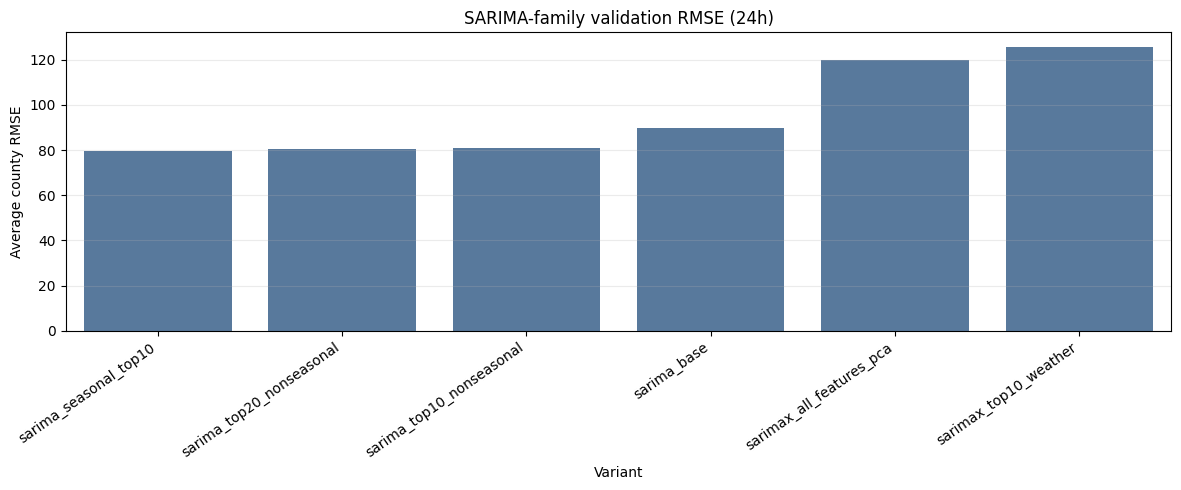

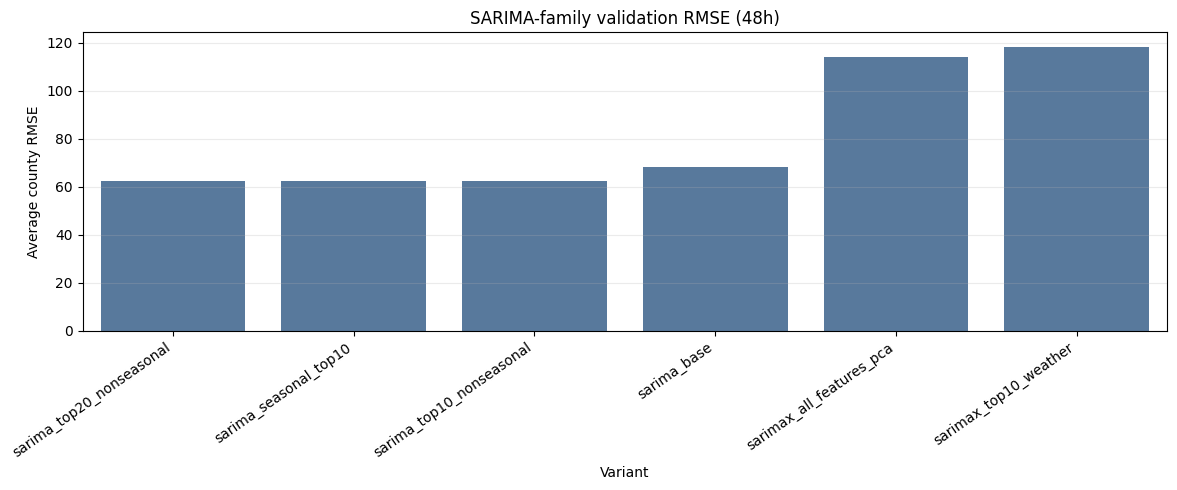

SARIMA/SARIMAX evaluation and export complete.


In [16]:
if SETTINGS['rerun_training'].get('sarima', False):
    sarima_metric_rows = [
        {'variant_key': 'sarima_base', 'display_model': 'Base SARIMA(1,0,1)', 'horizon': 24, 'validation_rmse': sarima_24h_avg},
        {'variant_key': 'sarima_base', 'display_model': 'Base SARIMA(1,0,1)', 'horizon': 48, 'validation_rmse': sarima_48h_avg},
        {'variant_key': 'sarima_top10_nonseasonal', 'display_model': 'SARIMA non-seasonal tuned top 10 counties', 'horizon': 24, 'validation_rmse': validated_all_avg_24h_top10},
        {'variant_key': 'sarima_top10_nonseasonal', 'display_model': 'SARIMA non-seasonal tuned top 10 counties', 'horizon': 48, 'validation_rmse': validated_all_avg_48h_top10},
        {'variant_key': 'sarima_top20_nonseasonal', 'display_model': 'SARIMA non-seasonal tuned top 20 counties', 'horizon': 24, 'validation_rmse': validated_all_avg_24h_top20},
        {'variant_key': 'sarima_top20_nonseasonal', 'display_model': 'SARIMA non-seasonal tuned top 20 counties', 'horizon': 48, 'validation_rmse': validated_all_avg_48h_top20},
        {'variant_key': 'sarima_seasonal_top10', 'display_model': 'SARIMA seasonal tuned top 10 counties', 'horizon': 24, 'validation_rmse': seasonal_validated_all_avg_24h},
        {'variant_key': 'sarima_seasonal_top10', 'display_model': 'SARIMA seasonal tuned top 10 counties', 'horizon': 48, 'validation_rmse': seasonal_validated_all_avg_48h},
    ]
    if not sarimax_metrics.empty:
        sarima_metric_rows.extend(sarimax_metrics.to_dict('records'))

    sarima_metrics = pd.DataFrame(sarima_metric_rows)
    sarima_metrics['family_key'] = 'sarima'
    sarima_metrics['metric_source'] = 'Integrated validation split'
    display(sarima_metrics.sort_values(['horizon', 'validation_rmse']))
    save_table(sarima_metrics, 'sarima_validation_metrics.csv')
    sarima_metrics.to_csv(SARIMA_OUTPUTS_DIR / 'sarima_validation_metrics.csv', index=False)

    for _, row in sarima_metrics.iterrows():
        register_metric(
            'sarima',
            row['variant_key'],
            row['display_model'],
            int(row['horizon']),
            float(row['validation_rmse']),
            'Integrated validation split',
        )

    final_sarima_models_24h = refit_model_map_on_full_history(final_seasonal_models_24h)
    final_sarima_models_48h = refit_model_map_on_full_history(final_seasonal_models_48h)
    save_model_map(final_sarima_models_24h, 'sarima_seasonal_top10_24h.joblib')
    save_model_map(final_sarima_models_48h, 'sarima_seasonal_top10_48h.joblib')

    pred_24h = generate_sarima_predictions(final_sarima_models_24h, locations, pd.to_datetime(ds_test_24h.timestamp.values))
    pred_48h = generate_sarima_predictions(final_sarima_models_48h, locations, pd.to_datetime(ds_test_48h.timestamp.values))
    save_and_register_predictions('sarima', 24, pred_24h, SARIMA_PREDICTIONS_DIR / 'sarima_pred_24h.csv')
    save_and_register_predictions('sarima', 48, pred_48h, SARIMA_PREDICTIONS_DIR / 'sarima_pred_48h.csv')
    MODEL_PREDICTIONS['sarima'][24].to_csv(SARIMA_OUTPUTS_DIR / 'sarima_pred_24h.csv', index=False)
    MODEL_PREDICTIONS['sarima'][48].to_csv(SARIMA_OUTPUTS_DIR / 'sarima_pred_48h.csv', index=False)

    write_prediction_summaries_and_plots('sarima', MODEL_PREDICTIONS.get('sarima', {}), SARIMA_DIR, 'sarima')

    for horizon in SETTINGS['horizons']:
        plot_df = sarima_metrics[sarima_metrics['horizon'].eq(horizon)].sort_values('validation_rmse')
        fig, ax = plt.subplots(figsize=(12, 5))
        if sns is not None:
            sns.barplot(data=plot_df, x='variant_key', y='validation_rmse', ax=ax, color='#4C78A8')
        else:
            ax.bar(plot_df['variant_key'], plot_df['validation_rmse'])
        ax.set_title(f'SARIMA-family validation RMSE ({horizon}h)')
        ax.set_xlabel('Variant')
        ax.set_ylabel('Average county RMSE')
        plt.xticks(rotation=35, ha='right')
        plt.tight_layout()
        plt.savefig(SARIMA_PLOTS_DIR / f'sarima_family_validation_rmse_{horizon}h.png', dpi=140)
        plt.show()
else:
    for horizon in SETTINGS['horizons']:
        loaded_pred = load_prediction_candidates(
            'sarima',
            horizon,
            [
                SARIMA_PREDICTIONS_DIR / f'sarima_pred_{horizon}h.csv',
                SARIMA_OUTPUTS_DIR / f'sarima_pred_{horizon}h.csv',
            ],
        )

        if loaded_pred is None:
            model_path = SARIMA_MODELS_DIR / f'sarima_seasonal_top10_{horizon}h.joblib'
            if joblib is not None and model_path.exists():
                print(f'Loading SARIMA model map from {model_path.relative_to(PROJECT_ROOT)}')
                loaded_model_map = joblib.load(model_path)
                test_timestamps = pd.to_datetime(ds_test_24h.timestamp.values) if horizon == 24 else pd.to_datetime(ds_test_48h.timestamp.values)
                regenerated_pred = generate_sarima_predictions(loaded_model_map, locations, test_timestamps)
                save_and_register_predictions('sarima', horizon, regenerated_pred, SARIMA_PREDICTIONS_DIR / f'sarima_pred_{horizon}h.csv')
                MODEL_PREDICTIONS['sarima'][horizon].to_csv(SARIMA_OUTPUTS_DIR / f'sarima_pred_{horizon}h.csv', index=False)
            else:
                print(f'No saved SARIMA predictions or selected model map were found for {horizon}h.')

    write_prediction_summaries_and_plots('sarima', MODEL_PREDICTIONS.get('sarima', {}), SARIMA_DIR, 'sarima')

    sarima_metrics_path = SARIMA_TABLES_DIR / 'sarima_validation_metrics.csv'
    if not sarima_metrics_path.exists():
        sarima_metrics_path = SARIMA_OUTPUTS_DIR / 'sarima_validation_metrics.csv'
    if sarima_metrics_path.exists():
        sarima_metrics = pd.read_csv(sarima_metrics_path)
        for _, row in sarima_metrics.iterrows():
            register_metric(
                'sarima',
                row['variant_key'],
                row['display_model'],
                int(row['horizon']),
                float(row['validation_rmse']),
                'Integrated validation split',
            )
        display(sarima_metrics)
    else:
        print('SARIMA validation metrics were not found. Rerun SARIMA training to regenerate the full comparison table.')

print('SARIMA/SARIMAX evaluation and export complete.')


## 7. LSTM

The LSTM family models county outage trajectories as supervised sequence-to-sequence forecasting problems. Each training example consists of a 24-hour historical context window for one county, and the target is the next 24 or 48 outage values. Three feature designs are retained because they answer different modeling questions: whether outage history alone is sufficient, whether a compact meteorological feature set improves generalization, and whether the full screened weather representation adds useful signal.

The final prediction files use the simple LSTM specification by default. This choice is controlled by `SETTINGS['lstm_variant_for_prediction']`, so the downstream comparison and generator allocation sections can switch to another model family without changing the data interface.


### 7.1 Feature Sets, Scaling, and Windows

All LSTM variants reuse the cleaned xarray dataset, train/validation split, locations, timestamps, and weather screening from the shared EDA section. This keeps preprocessing identical across the notebook and avoids hidden leakage. The simple and full variants use outage lags, cyclical calendar encodings, and weather covariates; the base variant uses only the outage sequence.


In [17]:
LSTM_DIR = APPROACH_DIRS['lstm']
LSTM_INPUTS_DIR = LSTM_DIR / 'inputs'
LSTM_OUTPUTS_DIR = LSTM_DIR / 'outputs'
LSTM_TABLES_DIR = LSTM_DIR / 'tables'
LSTM_PLOTS_DIR = LSTM_DIR / 'plots'
LSTM_PREDICTIONS_DIR = LSTM_DIR / 'predictions'
LSTM_MODELS_DIR = LSTM_DIR / 'models'
for path in [LSTM_INPUTS_DIR, LSTM_OUTPUTS_DIR, LSTM_TABLES_DIR, LSTM_PLOTS_DIR, LSTM_PREDICTIONS_DIR, LSTM_MODELS_DIR]:
    path.mkdir(parents=True, exist_ok=True)

if torch is None:
    raise ImportError('PyTorch is required to train or load the LSTM models.')

random.seed(SETTINGS['random_seed'])
np.random.seed(SETTINGS['random_seed'])
torch.manual_seed(SETTINGS['random_seed'])

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
SEQ_LEN = SETTINGS['lstm_seq_len']
BATCH_SIZE = SETTINGS['lstm_batch_size']
EPOCHS = SETTINGS['lstm_epochs']
LR = SETTINGS['lstm_learning_rate']

print(f'LSTM device: {DEVICE}')
print(f'LSTM seed: {SETTINGS["random_seed"]}')


def build_lstm_feature_matrix(ds, ts, weather_feats):
    out_vals = ds.out.transpose('timestamp', 'location').values.astype(float)
    T_local, L_local = out_vals.shape

    def lag(arr, k):
        shifted = np.full_like(arr, np.nan)
        shifted[k:] = arr[:-k]
        return shifted

    lag1 = lag(out_vals, 1)
    lag24 = lag(out_vals, 24)
    hour_sin = np.sin(2 * np.pi * ts.hour / 24).values[:, None] * np.ones((1, L_local))
    hour_cos = np.cos(2 * np.pi * ts.hour / 24).values[:, None] * np.ones((1, L_local))
    dow_sin = np.sin(2 * np.pi * ts.dayofweek / 7).values[:, None] * np.ones((1, L_local))
    dow_cos = np.cos(2 * np.pi * ts.dayofweek / 7).values[:, None] * np.ones((1, L_local))

    w_vals = ds.weather.sel(feature=weather_feats).transpose(
        'timestamp', 'location', 'feature'
    ).values.astype(float)

    base = np.stack([out_vals, lag1, lag24, hour_sin, hour_cos, dow_sin, dow_cos], axis=-1)
    X = np.concatenate([base, w_vals], axis=-1)
    return X, out_vals


def build_base_feature_matrix(ds):
    out_vals = ds.out.transpose('timestamp', 'location').values.astype(float)
    X = out_vals[:, :, np.newaxis]
    return X, out_vals


print('Building feature matrix for LSTM-Base...')
X_base, _ = build_base_feature_matrix(ds_train_clean)
print(f'  Shape: {X_base.shape} -> (T, L, 1 feature)')

print('Building feature matrix for LSTM-Simple...')
X_simple, y = build_lstm_feature_matrix(ds_train_clean, all_timestamps, selected_weather_features)
print(f'  Shape: {X_simple.shape} -> (T, L, {X_simple.shape[-1]} features)')

print('Building feature matrix for LSTM-Full...')
X_full, _ = build_lstm_feature_matrix(ds_train_clean, all_timestamps, all_weather_features)
print(f'  Shape: {X_full.shape} -> (T, L, {X_full.shape[-1]} features)')

feature_set_rows = [
    {'variant': 'base', 'n_features': X_base.shape[-1], 'weather_features': ''},
    {'variant': 'simple', 'n_features': X_simple.shape[-1], 'weather_features': ', '.join(selected_weather_features)},
    {'variant': 'full', 'n_features': X_full.shape[-1], 'weather_features': ', '.join(all_weather_features)},
]
lstm_feature_set_table = pd.DataFrame(feature_set_rows)
lstm_feature_set_table.to_csv(LSTM_INPUTS_DIR / 'lstm_feature_sets.csv', index=False)
display(lstm_feature_set_table)


def fit_scaler(arr):
    flat = arr.reshape(-1, arr.shape[-1])
    mu = np.nanmean(flat, axis=0)
    sd = np.nanstd(flat, axis=0)
    sd = np.where(sd == 0, 1.0, sd)
    return mu, sd


def apply_scaler(arr, mu, sd):
    return (arr - mu) / sd


X_simple_tr, X_simple_va = X_simple[:split_idx], X_simple[split_idx:]
X_full_tr, X_full_va = X_full[:split_idx], X_full[split_idx:]
X_base_tr, X_base_va = X_base[:split_idx], X_base[split_idx:]
y_tr, y_va = y[:split_idx], y[split_idx:]

mu_simple, sd_simple = fit_scaler(X_simple_tr)
mu_full, sd_full = fit_scaler(X_full_tr)
mu_base, sd_base = fit_scaler(X_base_tr)

X_simple_tr_n = apply_scaler(np.nan_to_num(X_simple_tr, 0), mu_simple, sd_simple)
X_simple_va_n = apply_scaler(np.nan_to_num(X_simple_va, 0), mu_simple, sd_simple)
X_full_tr_n = apply_scaler(np.nan_to_num(X_full_tr, 0), mu_full, sd_full)
X_full_va_n = apply_scaler(np.nan_to_num(X_full_va, 0), mu_full, sd_full)
X_base_tr_n = apply_scaler(np.nan_to_num(X_base_tr, 0), mu_base, sd_base)
X_base_va_n = apply_scaler(np.nan_to_num(X_base_va, 0), mu_base, sd_base)

print(f'Train: {X_simple_tr.shape[0]} steps')
print(f'Validation: {X_simple_va.shape[0]} steps')
print('LSTM normalization complete.')


def build_windows(X_norm, y_raw, seq_len, horizon):
    T_local, L_local, D_local = X_norm.shape
    inputs, targets = [], []
    for loc_idx in range(L_local):
        x_loc = X_norm[:, loc_idx, :]
        y_loc = y_raw[:, loc_idx]
        for t in range(T_local - seq_len - horizon + 1):
            inp = x_loc[t:t + seq_len]
            tgt = y_loc[t + seq_len:t + seq_len + horizon]
            if np.isnan(inp).any() or np.isnan(tgt).any():
                continue
            inputs.append(inp)
            targets.append(tgt)
    return np.array(inputs, dtype=np.float32), np.array(targets, dtype=np.float32)


print('Building windows for LSTM-Base...')
X_win_base_24, y_win_24 = build_windows(X_base_tr_n, y_tr, SEQ_LEN, 24)
X_win_base_48, y_win_48 = build_windows(X_base_tr_n, y_tr, SEQ_LEN, 48)
print(f'  24h: inputs {X_win_base_24.shape} targets {y_win_24.shape}')
print(f'  48h: inputs {X_win_base_48.shape} targets {y_win_48.shape}')

print('Building windows for LSTM-Simple...')
X_win_simple_24, y_win_24 = build_windows(X_simple_tr_n, y_tr, SEQ_LEN, 24)
X_win_simple_48, y_win_48 = build_windows(X_simple_tr_n, y_tr, SEQ_LEN, 48)
print(f'  24h: inputs {X_win_simple_24.shape} targets {y_win_24.shape}')
print(f'  48h: inputs {X_win_simple_48.shape} targets {y_win_48.shape}')

print('Building windows for LSTM-Full...')
X_win_full_24, _ = build_windows(X_full_tr_n, y_tr, SEQ_LEN, 24)
X_win_full_48, _ = build_windows(X_full_tr_n, y_tr, SEQ_LEN, 48)
print(f'  24h: inputs {X_win_full_24.shape} targets {y_win_24.shape}')
print(f'  48h: inputs {X_win_full_48.shape} targets {y_win_48.shape}')


LSTM device: cpu
LSTM seed: 42
Building feature matrix for LSTM-Base...
  Shape: (2161, 83, 1) -> (T, L, 1 feature)
Building feature matrix for LSTM-Simple...
  Shape: (2161, 83, 17) -> (T, L, 17 features)
Building feature matrix for LSTM-Full...
  Shape: (2161, 83, 99) -> (T, L, 99 features)


,variant,n_features,weather_features
0,base,1,
1,simple,17,"cape, pwat, sh2, gh_4, cape_1, sdlwrf, unknown..."
2,full,99,"SBT113, SBT114, SBT123, SBT124, blh, cape, cap..."


Train: 1728 steps
Validation: 433 steps
LSTM normalization complete.
Building windows for LSTM-Base...
  24h: inputs (139523, 24, 1) targets (139523, 24)
  48h: inputs (137531, 24, 1) targets (137531, 48)
Building windows for LSTM-Simple...
  24h: inputs (139523, 24, 17) targets (139523, 24)
  48h: inputs (137531, 24, 17) targets (137531, 48)
Building windows for LSTM-Full...
  24h: inputs (139523, 24, 99) targets (139523, 24)
  48h: inputs (137531, 24, 99) targets (137531, 48)


### 7.2 Model Architecture and Training Routine

The network uses a three-layer LSTM with hidden dimension 128, dropout 0.30, and a multilayer perceptron head. The output is clamped at zero because outage counts are nonnegative. The optimization routine uses Adam, a step learning-rate schedule, mean squared error loss, shuffled mini-batches, and gradient clipping.


In [18]:
class LSTMModel(nn.Module):
    def __init__(self, input_dim, hidden_dim=128, num_layers=3, dropout=0.3, horizon=24):
        super().__init__()
        self.lstm = nn.LSTM(
            input_dim,
            hidden_dim,
            num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0,
        )
        self.head = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim // 2, horizon),
        )

    def forward(self, x):
        out, _ = self.lstm(x)
        last = out[:, -1, :]
        pred = self.head(last)
        return torch.clamp(pred, min=0.0)


dummy_base = torch.zeros(4, SEQ_LEN, X_win_base_24.shape[-1])
dummy_simple = torch.zeros(4, SEQ_LEN, X_win_simple_24.shape[-1])
dummy_full = torch.zeros(4, SEQ_LEN, X_win_full_24.shape[-1])

m = LSTMModel(input_dim=X_win_base_24.shape[-1], horizon=24)
print(f'LSTM-Base output shape: {m(dummy_base).shape}')
m = LSTMModel(input_dim=X_win_simple_24.shape[-1], horizon=24)
print(f'LSTM-Simple output shape: {m(dummy_simple).shape}')
m = LSTMModel(input_dim=X_win_full_24.shape[-1], horizon=24)
print(f'LSTM-Full output shape: {m(dummy_full).shape}')

n_params_base = sum(p.numel() for p in LSTMModel(X_win_base_24.shape[-1]).parameters())
n_params_simple = sum(p.numel() for p in LSTMModel(X_win_simple_24.shape[-1]).parameters())
n_params_full = sum(p.numel() for p in LSTMModel(X_win_full_24.shape[-1]).parameters())
print(f'LSTM-Base parameters: {n_params_base:,}')
print(f'LSTM-Simple parameters: {n_params_simple:,}')
print(f'LSTM-Full parameters: {n_params_full:,}')


def train_model(
    X_windows,
    y_windows,
    input_dim,
    horizon,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    lr=LR,
    model_name='LSTM',
):
    dataset = TensorDataset(torch.tensor(X_windows), torch.tensor(y_windows))
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=True)
    model = LSTMModel(input_dim=input_dim, horizon=horizon).to(DEVICE)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.5)
    criterion = nn.MSELoss()
    history = []

    for epoch in tqdm(range(epochs), desc=f'Training {model_name} {horizon}h'):
        model.train()
        epoch_loss = 0.0
        for xb, yb in loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            optimizer.zero_grad()
            loss = criterion(model(xb), yb)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            epoch_loss += loss.item() * len(xb)
        epoch_loss /= len(dataset)
        history.append(epoch_loss)
        scheduler.step()

    return model, history


def save_lstm_checkpoint(model, model_path, variant, horizon, input_dim, mu, sd, feature_names, history=None):
    torch.save({
        'state_dict': model.state_dict(),
        'variant': variant,
        'horizon': int(horizon),
        'input_dim': int(input_dim),
        'hidden_dim': SETTINGS['lstm_hidden_dim'],
        'num_layers': SETTINGS['lstm_num_layers'],
        'dropout': SETTINGS['lstm_dropout'],
        'mu': mu,
        'sd': sd,
        'feature_names': feature_names,
        'history': history,
        'settings': SETTINGS,
    }, model_path)


def load_lstm_checkpoint(model_path):
    try:
        checkpoint = torch.load(model_path, map_location=DEVICE, weights_only=False)
    except TypeError:
        checkpoint = torch.load(model_path, map_location=DEVICE)
    model = LSTMModel(
        input_dim=int(checkpoint['input_dim']),
        hidden_dim=int(checkpoint.get('hidden_dim', SETTINGS['lstm_hidden_dim'])),
        num_layers=int(checkpoint.get('num_layers', SETTINGS['lstm_num_layers'])),
        dropout=float(checkpoint.get('dropout', SETTINGS['lstm_dropout'])),
        horizon=int(checkpoint['horizon']),
    ).to(DEVICE)
    model.load_state_dict(checkpoint['state_dict'])
    model.eval()
    return model, checkpoint


def plot_lstm_loss(hist_24, hist_48, title, color, filename):
    if hist_24 is None or hist_48 is None:
        return
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    fig.suptitle(title, fontsize=13, fontweight='bold')
    for ax, hist, horizon_label in zip(axes, [hist_24, hist_48], ['24h', '48h']):
        ax.plot(hist, marker='o', markersize=3, color=color)
        ax.set_title(horizon_label)
        ax.set_xlabel('Epoch')
        ax.set_ylabel('MSE Loss')
        ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(LSTM_PLOTS_DIR / filename, dpi=120)
    plt.savefig(LSTM_OUTPUTS_DIR / filename, dpi=120)
    plt.show()


LSTM-Base output shape: torch.Size([4, 24])
LSTM-Simple output shape: torch.Size([4, 24])
LSTM-Full output shape: torch.Size([4, 24])
LSTM-Base parameters: 357,848
LSTM-Simple parameters: 366,040
LSTM-Full parameters: 408,024


### 7.3 Validation Training

The validation experiment trains six models: base, simple, and full variants for both 24-hour and 48-hour forecast horizons. The `SETTINGS['rerun_training']` flags determine whether each variant is retrained or loaded from `final_notebook/LSTM/models`. The defaults retrain all LSTM variants because pretrained LSTM artifacts are not assumed to be present.


Training LSTM-Base 24h...


Training LSTM-Base 24h:   0%|          | 0/20 [00:00<?, ?it/s]

Training LSTM-Base 48h...


Training LSTM-Base 48h:   0%|          | 0/20 [00:00<?, ?it/s]

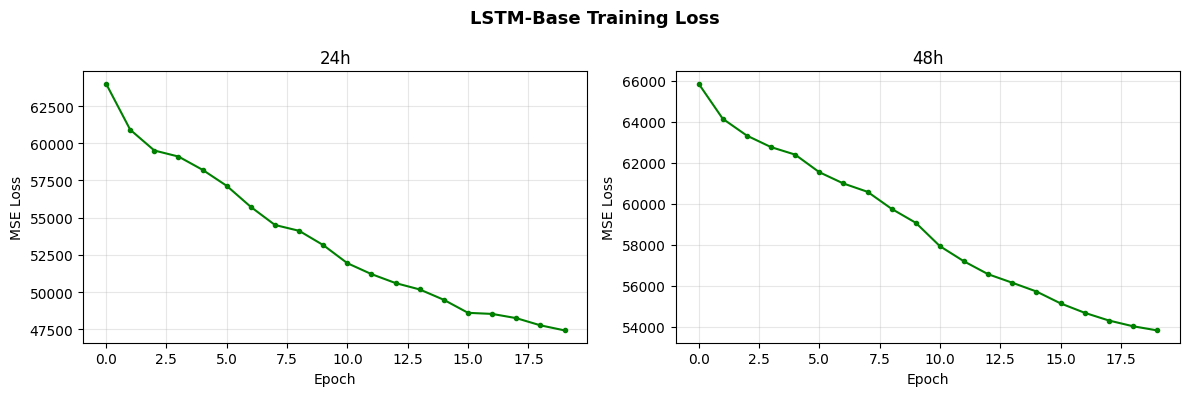

Training LSTM-Simple 24h...


Training LSTM-Simple 24h:   0%|          | 0/20 [00:00<?, ?it/s]

Training LSTM-Simple 48h...


Training LSTM-Simple 48h:   0%|          | 0/20 [00:00<?, ?it/s]

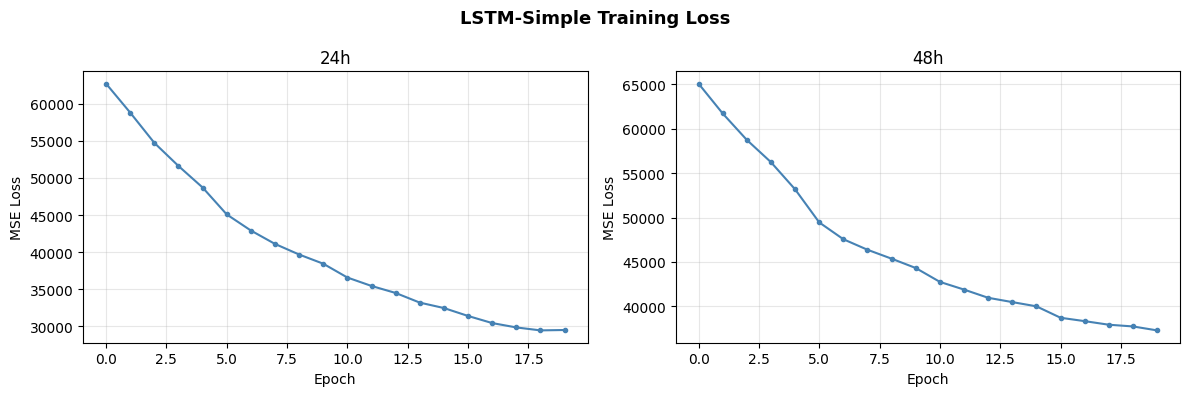

Training LSTM-Full 24h...


Training LSTM-Full 24h:   0%|          | 0/20 [00:00<?, ?it/s]

Training LSTM-Full 48h...


Training LSTM-Full 48h:   0%|          | 0/20 [00:00<?, ?it/s]

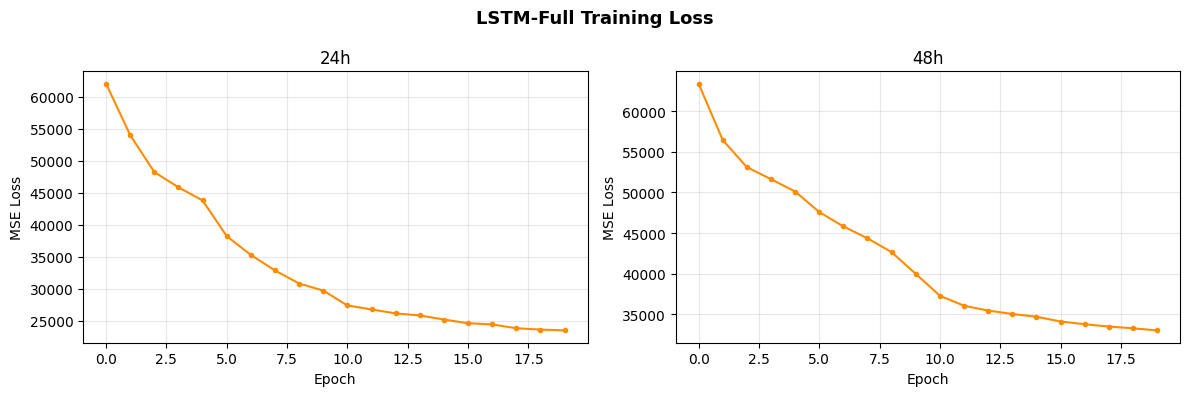

LSTM validation training/loading complete.


In [19]:
lstm_feature_names = {
    'base': ['out'],
    'simple': ['out', 'lag1', 'lag24', 'hour_sin', 'hour_cos', 'dow_sin', 'dow_cos'] + selected_weather_features,
    'full': ['out', 'lag1', 'lag24', 'hour_sin', 'hour_cos', 'dow_sin', 'dow_cos'] + all_weather_features,
}


def train_or_load_validation_lstm(variant, horizon, X_windows, y_windows, feature_names, mu, sd, display_name):
    model_path = LSTM_MODELS_DIR / f'lstm_{variant}_{horizon}h.pt'
    rerun = SETTINGS['rerun_training'].get(f'lstm_{variant}', False)

    if rerun or not model_path.exists():
        if not rerun and not model_path.exists():
            print(f'Missing {model_path.relative_to(PROJECT_ROOT)}; retraining {display_name} {horizon}h.')
        print(f'Training {display_name} {horizon}h...')
        model, history = train_model(
            X_windows,
            y_windows,
            X_windows.shape[-1],
            horizon,
            model_name=display_name,
        )
        save_lstm_checkpoint(
            model,
            model_path,
            variant,
            horizon,
            X_windows.shape[-1],
            mu,
            sd,
            feature_names,
            history,
        )
        pd.DataFrame({
            'epoch': np.arange(1, len(history) + 1),
            'mse_loss': history,
        }).to_csv(LSTM_TABLES_DIR / f'lstm_{variant}_{horizon}h_training_history.csv', index=False)
        return model, history

    print(f'Loading {display_name} {horizon}h from {model_path.relative_to(PROJECT_ROOT)}')
    model, checkpoint = load_lstm_checkpoint(model_path)
    return model, checkpoint.get('history')


model_base_24h, hist_base_24h = train_or_load_validation_lstm(
    'base', 24, X_win_base_24, y_win_24, lstm_feature_names['base'], mu_base, sd_base, 'LSTM-Base'
)
model_base_48h, hist_base_48h = train_or_load_validation_lstm(
    'base', 48, X_win_base_48, y_win_48, lstm_feature_names['base'], mu_base, sd_base, 'LSTM-Base'
)
plot_lstm_loss(hist_base_24h, hist_base_48h, 'LSTM-Base Training Loss', 'green', 'loss_base.png')

model_simple_24h, hist_simple_24h = train_or_load_validation_lstm(
    'simple', 24, X_win_simple_24, y_win_24, lstm_feature_names['simple'], mu_simple, sd_simple, 'LSTM-Simple'
)
model_simple_48h, hist_simple_48h = train_or_load_validation_lstm(
    'simple', 48, X_win_simple_48, y_win_48, lstm_feature_names['simple'], mu_simple, sd_simple, 'LSTM-Simple'
)
plot_lstm_loss(hist_simple_24h, hist_simple_48h, 'LSTM-Simple Training Loss', 'steelblue', 'loss_simple.png')

model_full_24h, hist_full_24h = train_or_load_validation_lstm(
    'full', 24, X_win_full_24, y_win_24, lstm_feature_names['full'], mu_full, sd_full, 'LSTM-Full'
)
model_full_48h, hist_full_48h = train_or_load_validation_lstm(
    'full', 48, X_win_full_48, y_win_48, lstm_feature_names['full'], mu_full, sd_full, 'LSTM-Full'
)
plot_lstm_loss(hist_full_24h, hist_full_48h, 'LSTM-Full Training Loss', 'darkorange', 'loss_full.png')

print('LSTM validation training/loading complete.')


### 7.4 Validation Evaluation and Diagnostic Plots

Validation predictions are generated by feeding the last 24 hours of the training segment into each model and comparing the direct multi-step forecast to the first 24 or 48 hours of the held-out period. The reported score is average county RMSE, which prevents high-volume counties from completely dominating the model selection decision.


Generating validation predictions...
Val 24h predictions: 1992 rows (expected 1992)
Val 48h predictions: 3984 rows (expected 3984)
Validation timestamps: 433 steps; first=2023-06-12 00:00:00, last=2023-06-30 00:00:00
Model Comparison - Validation RMSE
                           Model    RMSE 24h  RMSE 48h
                   Zero Baseline    292.5593  209.9249
                     Persistence     93.6870       N/A
               Historical Median    277.7680       N/A
                          Hurdle 106563.8301       N/A
                             ZIP    280.6458       N/A
         LSTM-Base (outage only)     85.1678   66.2439
    LSTM-Simple (top 10 weather)    125.6160   72.1437
LSTM-Full (all screened weather)    104.8421   77.6097


,Model,RMSE 24h,RMSE 48h
0,Zero Baseline,292.5593,209.9249
1,Persistence,93.6870,N/A
2,Historical Median,277.7680,N/A
3,Hurdle,106563.8301,N/A
4,ZIP,280.6458,N/A
5,LSTM-Base (outage only),85.1678,66.2439
6,LSTM-Simple (top 10 weather),125.6160,72.1437
7,LSTM-Full (all screened weather),104.8421,77.6097


,variant,display_model,horizon,validation_rmse
0,base,LSTM-Base: outage only,24,85.167803
1,full,LSTM-Full: all screened weather,24,104.842100
2,simple,LSTM-Simple: top 10 weather,24,125.616009
3,base,LSTM-Base: outage only,48,66.243850
4,simple,LSTM-Simple: top 10 weather,48,72.143697
5,full,LSTM-Full: all screened weather,48,77.609695


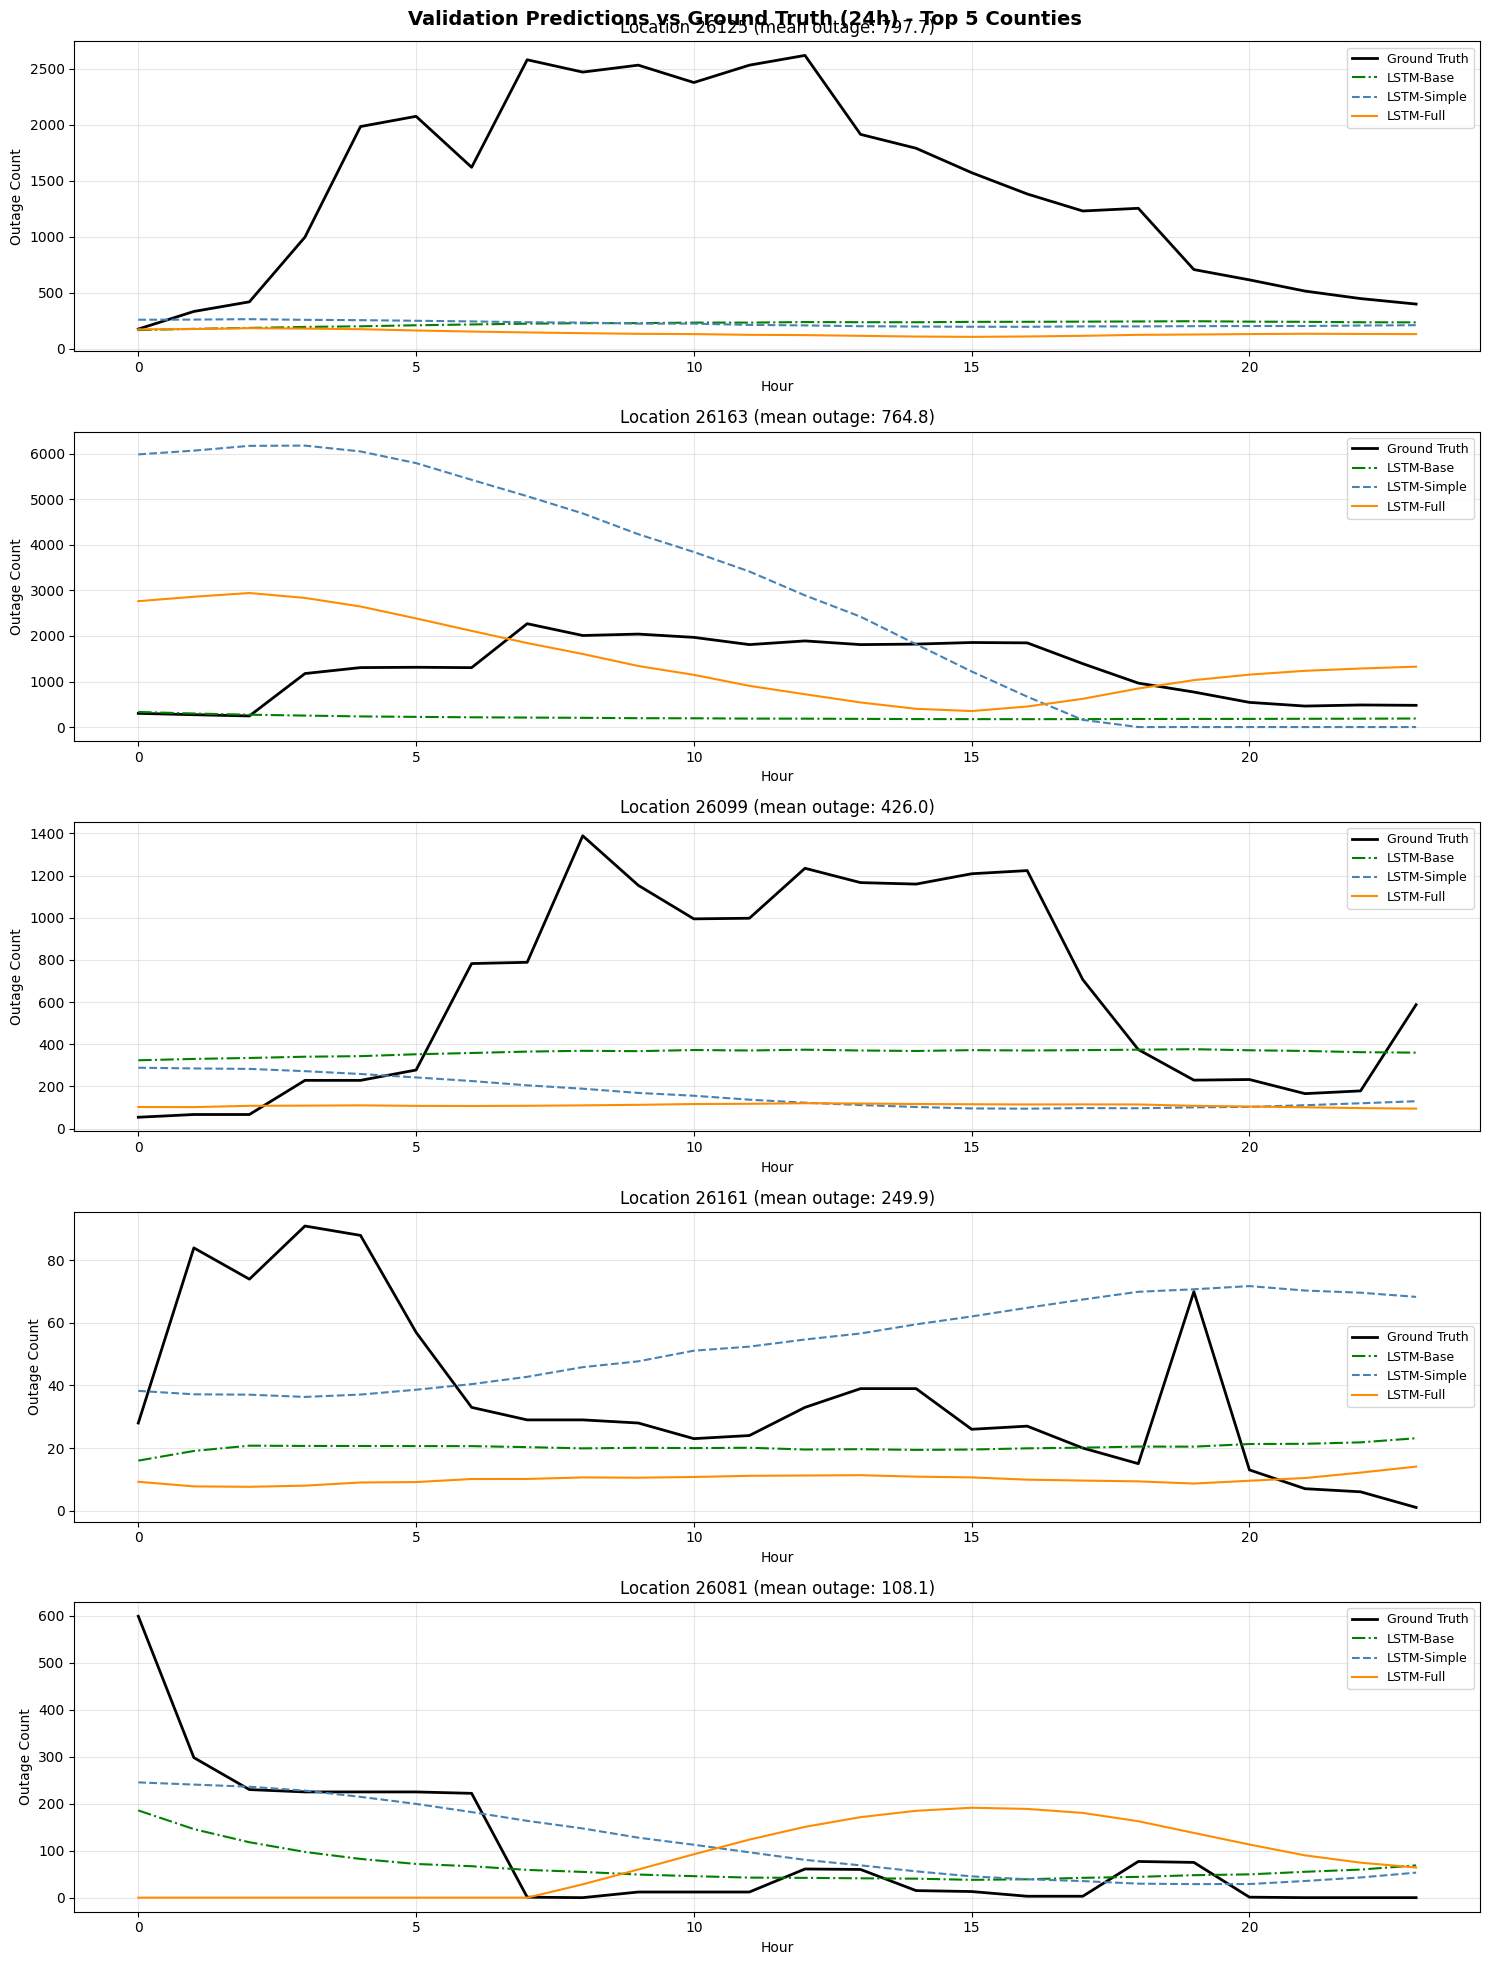

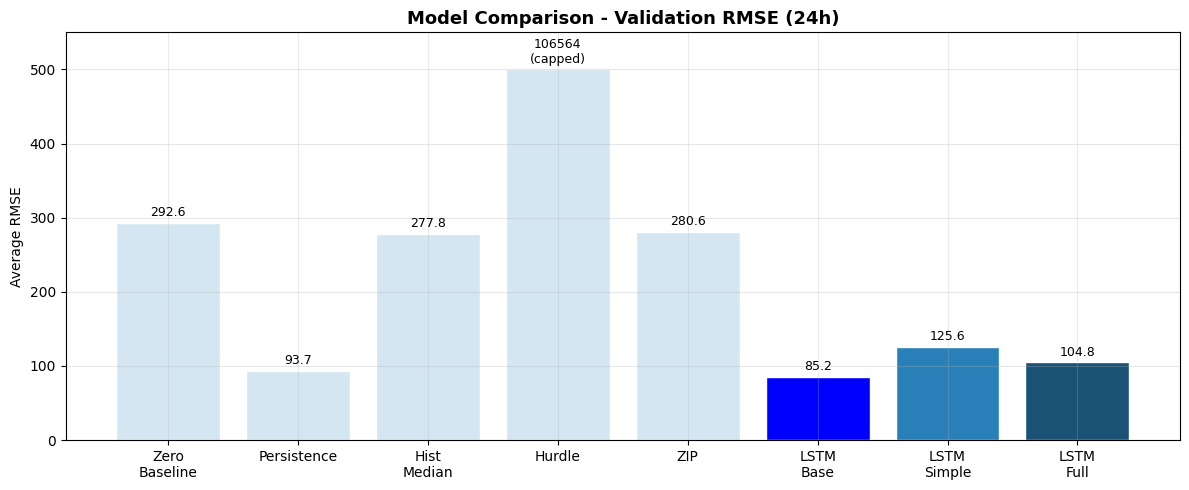

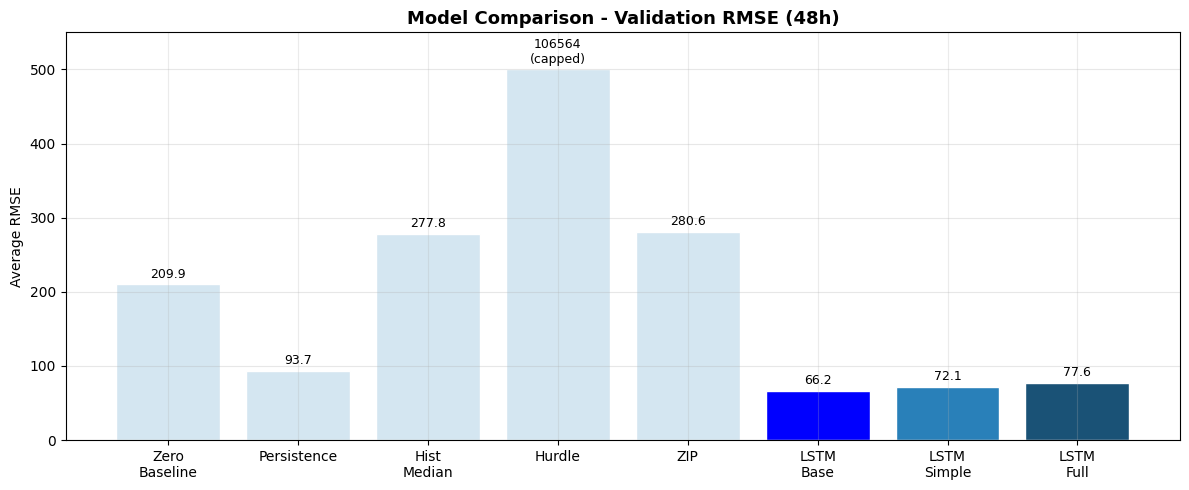

In [20]:
def predict_with_timestamps(model, X_context_norm, horizon, prediction_locations, timestamps):
    model.eval()
    context = X_context_norm[-SEQ_LEN:, :, :]
    inp = torch.tensor(context.transpose(1, 0, 2), dtype=torch.float32).to(DEVICE)
    with torch.no_grad():
        preds = model(inp).cpu().numpy()

    rows = []
    for loc_idx, loc in enumerate(prediction_locations):
        for h in range(horizon):
            rows.append({'step': h, 'location': loc, 'pred': float(preds[loc_idx, h])})
    df = pd.DataFrame(rows)
    df['timestamp'] = df['step'].apply(lambda i: timestamps[i] if i < len(timestamps) else None)
    return df[['timestamp', 'location', 'pred']].dropna(subset=['timestamp']).reset_index(drop=True)


print('Generating validation predictions...')
val_base_24h = predict_with_timestamps(model_base_24h, X_base_tr_n, 24, locations, val_ts)
val_base_48h = predict_with_timestamps(model_base_48h, X_base_tr_n, 48, locations, val_ts)
val_simple_24h = predict_with_timestamps(model_simple_24h, X_simple_tr_n, 24, locations, val_ts)
val_simple_48h = predict_with_timestamps(model_simple_48h, X_simple_tr_n, 48, locations, val_ts)
val_full_24h = predict_with_timestamps(model_full_24h, X_full_tr_n, 24, locations, val_ts)
val_full_48h = predict_with_timestamps(model_full_48h, X_full_tr_n, 48, locations, val_ts)

print(f'Val 24h predictions: {len(val_simple_24h)} rows (expected {24 * len(locations)})')
print(f'Val 48h predictions: {len(val_simple_48h)} rows (expected {48 * len(locations)})')
print(f'Validation timestamps: {len(val_ts)} steps; first={val_ts[0]}, last={val_ts[-1]}')


def lstm_rmse(y_true, y_pred):
    return float(np.sqrt(np.mean((np.array(y_true) - np.array(y_pred)) ** 2)))


def evaluate_avg_rmse(pred_df, truth_arr, prediction_locations):
    H = truth_arr.shape[0]
    rmses = []
    for i, loc in enumerate(prediction_locations):
        pv = pred_df[pred_df['location'].astype(str) == str(loc)]['pred'].values
        if len(pv) >= H:
            rmses.append(lstm_rmse(truth_arr[:, i], pv[:H]))
    return float(np.nanmean(rmses))


rmse_base_24h = evaluate_avg_rmse(val_base_24h, val_truth_24h, locations)
rmse_base_48h = evaluate_avg_rmse(val_base_48h, val_truth_48h, locations)
rmse_simple_24h = evaluate_avg_rmse(val_simple_24h, val_truth_24h, locations)
rmse_simple_48h = evaluate_avg_rmse(val_simple_48h, val_truth_48h, locations)
rmse_full_24h = evaluate_avg_rmse(val_full_24h, val_truth_24h, locations)
rmse_full_48h = evaluate_avg_rmse(val_full_48h, val_truth_48h, locations)

lstm_zero_rmse_24h = float(np.sqrt(np.mean(val_truth_24h ** 2)))
lstm_zero_rmse_48h = float(np.sqrt(np.mean(val_truth_48h ** 2)))

lstm_results = pd.DataFrame({
    'Model': [
        'Zero Baseline',
        'Persistence',
        'Historical Median',
        'Hurdle',
        'ZIP',
        'LSTM-Base (outage only)',
        'LSTM-Simple (top 10 weather)',
        'LSTM-Full (all screened weather)',
    ],
    'RMSE 24h': [
        round(lstm_zero_rmse_24h, 4),
        93.6870,
        277.7680,
        106563.8301,
        280.6458,
        round(rmse_base_24h, 4),
        round(rmse_simple_24h, 4),
        round(rmse_full_24h, 4),
    ],
    'RMSE 48h': [
        round(lstm_zero_rmse_48h, 4),
        'N/A',
        'N/A',
        'N/A',
        'N/A',
        round(rmse_base_48h, 4),
        round(rmse_simple_48h, 4),
        round(rmse_full_48h, 4),
    ],
})

print('=' * 65)
print('Model Comparison - Validation RMSE')
print('=' * 65)
print(lstm_results.to_string(index=False))
display(lstm_results)
lstm_results.to_csv(LSTM_TABLES_DIR / 'lstm_validation_metrics_with_baselines.csv', index=False)
lstm_results.to_csv(LSTM_OUTPUTS_DIR / 'lstm_validation_metrics_with_baselines.csv', index=False)

lstm_metrics_table = pd.DataFrame([
    {'variant': 'base', 'display_model': 'LSTM-Base: outage only', 'horizon': 24, 'validation_rmse': rmse_base_24h},
    {'variant': 'base', 'display_model': 'LSTM-Base: outage only', 'horizon': 48, 'validation_rmse': rmse_base_48h},
    {'variant': 'simple', 'display_model': 'LSTM-Simple: top 10 weather', 'horizon': 24, 'validation_rmse': rmse_simple_24h},
    {'variant': 'simple', 'display_model': 'LSTM-Simple: top 10 weather', 'horizon': 48, 'validation_rmse': rmse_simple_48h},
    {'variant': 'full', 'display_model': 'LSTM-Full: all screened weather', 'horizon': 24, 'validation_rmse': rmse_full_24h},
    {'variant': 'full', 'display_model': 'LSTM-Full: all screened weather', 'horizon': 48, 'validation_rmse': rmse_full_48h},
]).sort_values(['horizon', 'validation_rmse']).reset_index(drop=True)

display(lstm_metrics_table)
lstm_metrics_table.to_csv(LSTM_TABLES_DIR / 'lstm_validation_metrics.csv', index=False)
lstm_metrics_table.to_csv(LSTM_OUTPUTS_DIR / 'lstm_validation_metrics.csv', index=False)

for _, row in lstm_metrics_table.iterrows():
    register_metric(
        'lstm',
        row['variant'],
        row['display_model'],
        int(row['horizon']),
        float(row['validation_rmse']),
        'Integrated LSTM validation split',
    )

mean_out = ds_train_clean.out.mean(dim='timestamp').values
top5_idx = np.argsort(mean_out)[::-1][:5]
top5_locs = [locations[i] for i in top5_idx]

fig, axes = plt.subplots(5, 1, figsize=(15, 20))
fig.suptitle('Validation Predictions vs Ground Truth (24h) - Top 5 Counties', fontsize=14, fontweight='bold')

for ax, loc in zip(axes, top5_locs):
    loc_idx = locations.index(loc)
    truth = val_truth_24h[:, loc_idx]
    base_pred = val_base_24h[val_base_24h['location'].astype(str) == str(loc)]['pred'].values[:24]
    simple_pred = val_simple_24h[val_simple_24h['location'].astype(str) == str(loc)]['pred'].values[:24]
    full_pred = val_full_24h[val_full_24h['location'].astype(str) == str(loc)]['pred'].values[:24]

    ax.plot(truth, label='Ground Truth', color='black', linewidth=2)
    if len(base_pred) == 24:
        ax.plot(base_pred, label='LSTM-Base', color='green', linewidth=1.5, linestyle='-.')
    if len(simple_pred) == 24:
        ax.plot(simple_pred, label='LSTM-Simple', color='steelblue', linewidth=1.5, linestyle='--')
    if len(full_pred) == 24:
        ax.plot(full_pred, label='LSTM-Full', color='darkorange', linewidth=1.5)

    ax.set_title(f'Location {loc} (mean outage: {mean_out[loc_idx]:.1f})')
    ax.set_xlabel('Hour')
    ax.set_ylabel('Outage Count')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(LSTM_PLOTS_DIR / 'validation_predictions_24h.png', dpi=120)
plt.savefig(LSTM_OUTPUTS_DIR / 'validation_predictions_24h.png', dpi=120)
plt.show()


def plot_lstm_metric_bar(plot_values, title, filename):
    plot_models = [
        'Zero\nBaseline',
        'Persistence',
        'Hist\nMedian',
        'Hurdle',
        'ZIP',
        'LSTM\nBase',
        'LSTM\nSimple',
        'LSTM\nFull',
    ]
    capped = [min(v, 500) for v in plot_values]
    colors = ['#d4e6f1'] * 5 + ['#0000ff', '#2980b9', '#1a5276']

    fig, ax = plt.subplots(figsize=(12, 5))
    bars = ax.bar(plot_models, capped, color=colors, edgecolor='white')

    for bar, val in zip(bars, plot_values):
        label = f'{val:.1f}' if val < 500 else f'{val:.0f}\n(capped)'
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 5,
            label,
            ha='center',
            va='bottom',
            fontsize=9,
        )

    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_ylabel('Average RMSE')
    ax.set_ylim(0, 550)
    ax.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.savefig(LSTM_PLOTS_DIR / filename, dpi=120)
    plt.savefig(LSTM_OUTPUTS_DIR / filename, dpi=120)
    plt.show()


plot_lstm_metric_bar(
    [lstm_zero_rmse_24h, 93.6870, 277.7680, 106563.8301, 280.6458, rmse_base_24h, rmse_simple_24h, rmse_full_24h],
    'Model Comparison - Validation RMSE (24h)',
    'model_comparison_bar_24h.png',
)
plot_lstm_metric_bar(
    [lstm_zero_rmse_48h, 93.6870, 277.7680, 106563.8301, 280.6458, rmse_base_48h, rmse_simple_48h, rmse_full_48h],
    'Model Comparison - Validation RMSE (48h)',
    'model_comparison_bar_48h.png',
)


### 7.5 Full-Data Retraining and Test Prediction Exports

After validation, the simple and full LSTM models are retrained on the entire available training history. The final prediction files are generated with the simple variant because it is the selected LSTM submission specification. Both 24-hour and 48-hour outputs are normalized to the shared `timestamp`, `location`, `pred` schema used by SARIMA, two-stage models, model comparison, and generator allocation.


Retraining/loading final LSTM models on full data...


Training Final LSTM-Simple 24h:   0%|          | 0/20 [00:00<?, ?it/s]

Training Final LSTM-Simple 48h:   0%|          | 0/20 [00:00<?, ?it/s]

Training Final LSTM-Full 24h:   0%|          | 0/20 [00:00<?, ?it/s]

Training Final LSTM-Full 48h:   0%|          | 0/20 [00:00<?, ?it/s]

Saved lstm 24h predictions to final_notebook/LSTM/predictions/lstm_pred_24h.csv
Saved lstm 48h predictions to final_notebook/LSTM/predictions/lstm_pred_48h.csv
Saved lstm_pred_24h.csv - 1992 rows (83 locations x 24h)
Saved lstm_pred_48h.csv - 3984 rows (83 locations x 48h, sorted by mean pred desc)
Preview lstm_pred_24h.csv:
          timestamp location      pred
2023-06-30 01:00:00    26001 17.879246
2023-06-30 02:00:00    26001 17.693350
2023-06-30 03:00:00    26001 17.877146
2023-06-30 04:00:00    26001 17.927372
2023-06-30 05:00:00    26001 18.258217
Preview lstm_pred_48h.csv:
          timestamp location        pred
2023-06-30 01:00:00    26091 1161.197144
2023-06-30 02:00:00    26091 1163.468994
2023-06-30 03:00:00    26091 1160.404175
2023-06-30 04:00:00    26091 1159.721558
2023-06-30 05:00:00    26091 1149.320068
Generated summary tables and plots under final_notebook/LSTM
Top 5 Counties by Mean Predicted Outage (24h):
location
26125    648.446134
26161    337.503841
26123    

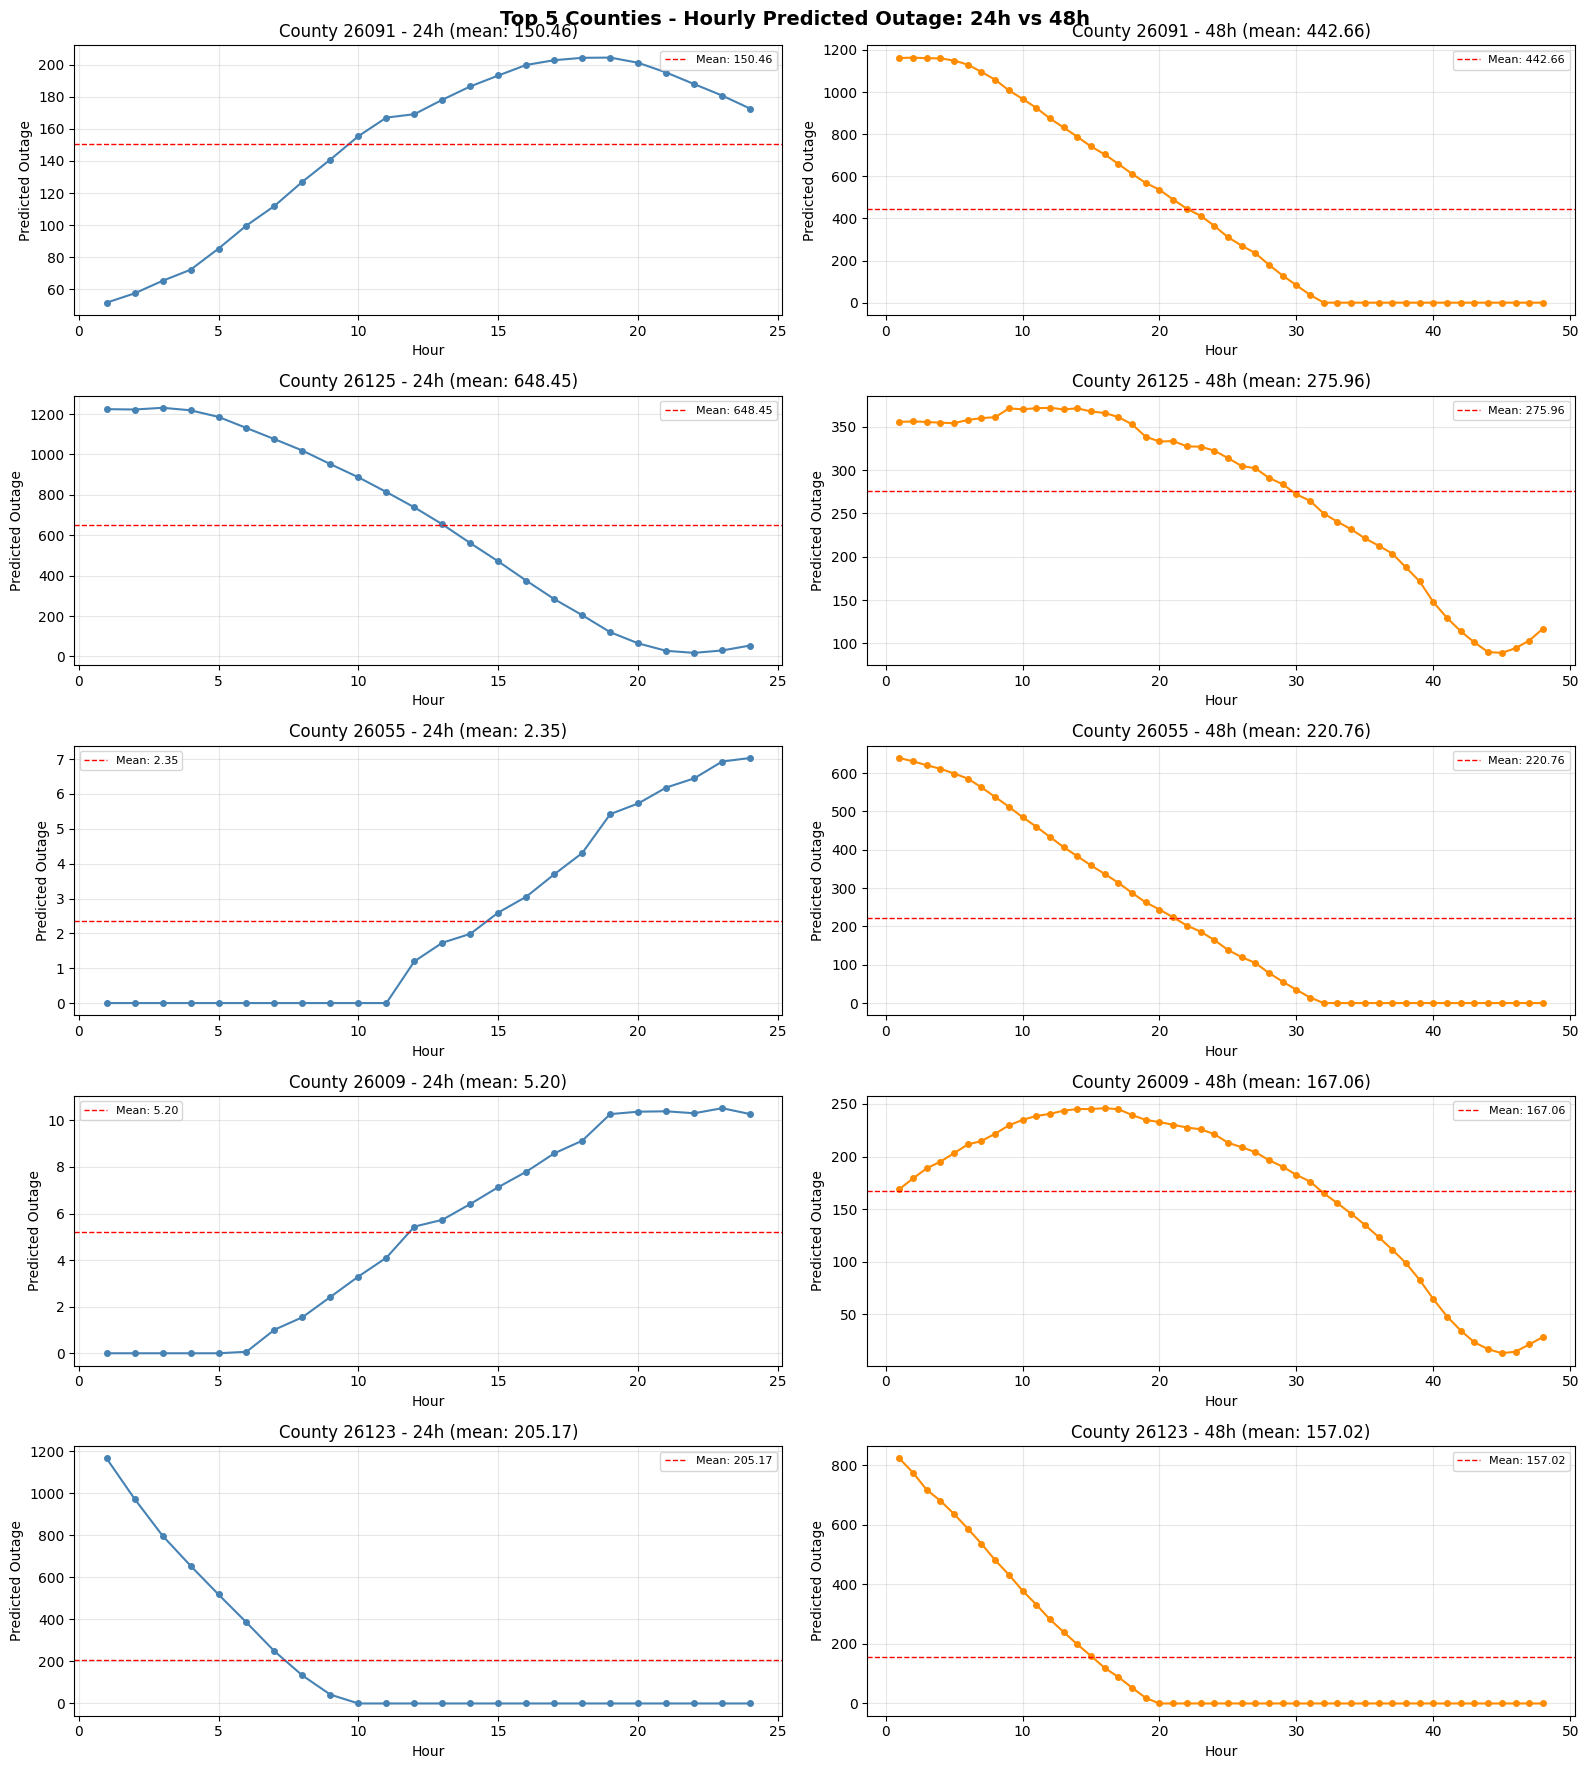

Saved top5_counties_24h_vs_48h.png


In [21]:
def train_or_load_final_lstm(variant, horizon, X_windows, y_windows, X_context_norm, mu, sd, feature_names, display_name):
    model_path = LSTM_MODELS_DIR / f'lstm_final_{variant}_{horizon}h.pt'
    rerun = SETTINGS['rerun_training'].get(f'lstm_{variant}', False)

    if rerun or not model_path.exists():
        if not rerun and not model_path.exists():
            print(f'Missing {model_path.relative_to(PROJECT_ROOT)}; retraining {display_name} {horizon}h on full history.')
        model, history = train_model(
            X_windows,
            y_windows,
            X_windows.shape[-1],
            horizon,
            model_name=display_name,
        )
        save_lstm_checkpoint(
            model,
            model_path,
            f'final_{variant}',
            horizon,
            X_windows.shape[-1],
            mu,
            sd,
            feature_names,
            history,
        )
        pd.DataFrame({
            'epoch': np.arange(1, len(history) + 1),
            'mse_loss': history,
        }).to_csv(LSTM_TABLES_DIR / f'lstm_final_{variant}_{horizon}h_training_history.csv', index=False)
        return model, history

    print(f'Loading final {display_name} {horizon}h from {model_path.relative_to(PROJECT_ROOT)}')
    model, checkpoint = load_lstm_checkpoint(model_path)
    return model, checkpoint.get('history')


mu_simple_full, sd_simple_full = fit_scaler(X_simple)
mu_full_full, sd_full_full = fit_scaler(X_full)

X_simple_n = apply_scaler(np.nan_to_num(X_simple, 0), mu_simple_full, sd_simple_full)
X_full_n = apply_scaler(np.nan_to_num(X_full, 0), mu_full_full, sd_full_full)

X_win_simple_24_final, y_win_24_final = build_windows(X_simple_n, y, SEQ_LEN, 24)
X_win_simple_48_final, y_win_48_final = build_windows(X_simple_n, y, SEQ_LEN, 48)
X_win_full_24_final, _ = build_windows(X_full_n, y, SEQ_LEN, 24)
X_win_full_48_final, _ = build_windows(X_full_n, y, SEQ_LEN, 48)

print('Retraining/loading final LSTM models on full data...')
final_simple_24h, hist_final_simple_24h = train_or_load_final_lstm(
    'simple',
    24,
    X_win_simple_24_final,
    y_win_24_final,
    X_simple_n,
    mu_simple_full,
    sd_simple_full,
    lstm_feature_names['simple'],
    'Final LSTM-Simple',
)
final_simple_48h, hist_final_simple_48h = train_or_load_final_lstm(
    'simple',
    48,
    X_win_simple_48_final,
    y_win_48_final,
    X_simple_n,
    mu_simple_full,
    sd_simple_full,
    lstm_feature_names['simple'],
    'Final LSTM-Simple',
)
final_full_24h, hist_final_full_24h = train_or_load_final_lstm(
    'full',
    24,
    X_win_full_24_final,
    y_win_24_final,
    X_full_n,
    mu_full_full,
    sd_full_full,
    lstm_feature_names['full'],
    'Final LSTM-Full',
)
final_full_48h, hist_final_full_48h = train_or_load_final_lstm(
    'full',
    48,
    X_win_full_48_final,
    y_win_48_final,
    X_full_n,
    mu_full_full,
    sd_full_full,
    lstm_feature_names['full'],
    'Final LSTM-Full',
)

test_24h_ts = pd.to_datetime(ds_test_24h.timestamp.values)
test_48h_ts = pd.to_datetime(ds_test_48h.timestamp.values)

test_pred_24h = predict_with_timestamps(final_simple_24h, X_simple_n, 24, locations, test_24h_ts)
test_pred_48h = predict_with_timestamps(final_simple_48h, X_simple_n, 48, locations, test_48h_ts)

test_pred_24h = test_pred_24h.sort_values(['location', 'timestamp']).reset_index(drop=True)
test_pred_48h = test_pred_48h.sort_values(['location', 'timestamp']).reset_index(drop=True)

mean_48h_by_loc = test_pred_48h.groupby('location')['pred'].mean()
loc_order_48h = mean_48h_by_loc.sort_values(ascending=False).index.tolist()
test_pred_48h['_rank'] = test_pred_48h['location'].map({loc: i for i, loc in enumerate(loc_order_48h)})
test_pred_48h = test_pred_48h.sort_values(['_rank', 'timestamp']).drop(columns='_rank').reset_index(drop=True)

save_and_register_predictions('lstm', 24, test_pred_24h[['timestamp', 'location', 'pred']], LSTM_PREDICTIONS_DIR / 'lstm_pred_24h.csv')
save_and_register_predictions('lstm', 48, test_pred_48h[['timestamp', 'location', 'pred']], LSTM_PREDICTIONS_DIR / 'lstm_pred_48h.csv')
MODEL_PREDICTIONS['lstm'][24].to_csv(LSTM_OUTPUTS_DIR / 'lstm_pred_24h.csv', index=False)
MODEL_PREDICTIONS['lstm'][48].to_csv(LSTM_OUTPUTS_DIR / 'lstm_pred_48h.csv', index=False)

print(f'Saved lstm_pred_24h.csv - {len(test_pred_24h)} rows ({len(locations)} locations x 24h)')
print(f'Saved lstm_pred_48h.csv - {len(test_pred_48h)} rows ({len(locations)} locations x 48h, sorted by mean pred desc)')
print('Preview lstm_pred_24h.csv:')
print(test_pred_24h[['timestamp', 'location', 'pred']].head(5).to_string(index=False))
print('Preview lstm_pred_48h.csv:')
print(test_pred_48h[['timestamp', 'location', 'pred']].head(5).to_string(index=False))

write_prediction_summaries_and_plots('lstm', MODEL_PREDICTIONS.get('lstm', {}), LSTM_DIR, 'lstm')

mean_pred_24h = test_pred_24h.groupby('location')['pred'].mean()
top5_counties_24h = mean_pred_24h.nlargest(5)
print('Top 5 Counties by Mean Predicted Outage (24h):')
print(top5_counties_24h)
top5_counties_24h.reset_index().rename(columns={'pred': 'mean_pred'}).to_csv(
    LSTM_TABLES_DIR / 'top5_counties_24h.csv',
    index=False,
)

mean_pred_48h = test_pred_48h.groupby('location')['pred'].mean()
top5_locs = mean_pred_48h.nlargest(5).index.tolist()
print('Top 5 Counties by Mean Predicted Outage (48h):')
print(mean_pred_48h.nlargest(5))
mean_pred_48h.nlargest(5).reset_index().rename(columns={'pred': 'mean_pred'}).to_csv(
    LSTM_TABLES_DIR / 'top5_counties_48h.csv',
    index=False,
)

fig, axes = plt.subplots(5, 2, figsize=(16, 18))
fig.suptitle('Top 5 Counties - Hourly Predicted Outage: 24h vs 48h', fontsize=14, fontweight='bold')

for i, loc in enumerate(top5_locs):
    loc_24 = test_pred_24h[test_pred_24h['location'].astype(str) == str(loc)].copy()
    loc_24 = loc_24.sort_values('timestamp').reset_index(drop=True)
    preds_24 = loc_24['pred'].values

    ax24 = axes[i][0]
    ax24.plot(range(1, len(preds_24) + 1), preds_24, marker='o', markersize=4, color='steelblue')
    ax24.set_title(f'County {loc} - 24h (mean: {preds_24.mean():.2f})')
    ax24.set_xlabel('Hour')
    ax24.set_ylabel('Predicted Outage')
    ax24.axhline(y=preds_24.mean(), color='red', linestyle='--', linewidth=1, label=f'Mean: {preds_24.mean():.2f}')
    ax24.legend(fontsize=8)
    ax24.grid(True, alpha=0.3)

    loc_48 = test_pred_48h[test_pred_48h['location'].astype(str) == str(loc)].copy()
    loc_48 = loc_48.sort_values('timestamp').reset_index(drop=True)
    preds_48 = loc_48['pred'].values

    ax48 = axes[i][1]
    ax48.plot(range(1, len(preds_48) + 1), preds_48, marker='o', markersize=4, color='darkorange')
    ax48.set_title(f'County {loc} - 48h (mean: {preds_48.mean():.2f})')
    ax48.set_xlabel('Hour')
    ax48.set_ylabel('Predicted Outage')
    ax48.axhline(y=preds_48.mean(), color='red', linestyle='--', linewidth=1, label=f'Mean: {preds_48.mean():.2f}')
    ax48.legend(fontsize=8)
    ax48.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(LSTM_PLOTS_DIR / 'top5_counties_24h_vs_48h.png', dpi=120)
plt.savefig(LSTM_OUTPUTS_DIR / 'top5_counties_24h_vs_48h.png', dpi=120)
plt.show()
print('Saved top5_counties_24h_vs_48h.png')


## 8. Two-stage Approach

The two-stage approach frames outage forecasting as a hurdle-style tabular prediction problem. Stage 1 estimates whether a county-hour observation will have a nonzero outage. Stage 2 estimates the positive outage magnitude conditional on the engineered historical and weather features. The final expected outage is formed by combining the nonzero probability and positive magnitude prediction.

Five training attempts were considered. They differ primarily in feature breadth and validation design. This matters because the project data are temporally sparse and event-driven: a validation split that is not aligned with the intended forecast origin may produce optimistic or pessimistic estimates depending on where large outage events fall. In the current project directory, each attempt is represented by its own subfolder under `final_notebook/two_stage/`; the selected attempt is controlled by `two_stage_default_attempt`.


In [22]:
TWO_STAGE_DIR = APPROACH_DIRS['two_stage']

TWO_STAGE_ATTEMPTS = pd.DataFrame([
    {
        'attempt_key': 'exact_sets_same_features_run',
        'design': 'Outage, lag, calendar time, and top 10 weather features using a compact shared feature recipe.',
        'data_split_group': 'exact_sets_shared_train_validation_test',
        'rerun_flag': 'two_stage_exact_sets_same_features_run',
    },
    {
        'attempt_key': 'exact_sets_aligned_run',
        'design': 'Engineered top 10 weather features and outage history with aligned training and validation windows.',
        'data_split_group': 'exact_sets_shared_train_validation_test',
        'rerun_flag': 'two_stage_exact_sets_aligned_run',
    },
    {
        'attempt_key': '10features_1fold',
        'design': 'Engineered top 10 weather features and outage history with a different single validation split.',
        'data_split_group': 'independent_single_fold_split',
        'rerun_flag': 'two_stage_10features_1fold',
    },
    {
        'attempt_key': '50features_2fold',
        'design': 'Engineered top 50 weather features and outage history with two-fold validation.',
        'data_split_group': 'independent_two_fold_split',
        'rerun_flag': 'two_stage_50features_2fold',
    },
    {
        'attempt_key': 'all_data_run',
        'design': 'Engineered top 10 weather features and outage history, trained using all available data.',
        'data_split_group': 'all_available_training_data',
        'rerun_flag': 'two_stage_all_data_run',
    },
])

TWO_STAGE_RANDOM_SEED = SETTINGS['two_stage_random_seed']
TWO_STAGE_ATTEMPTS['random_seed'] = TWO_STAGE_RANDOM_SEED
TWO_STAGE_ATTEMPTS['artifact_dir'] = TWO_STAGE_ATTEMPTS['attempt_key'].map(lambda key: TWO_STAGE_DIR / key)
TWO_STAGE_ATTEMPTS['artifact_dir_exists'] = TWO_STAGE_ATTEMPTS['artifact_dir'].map(lambda path: path.exists())
TWO_STAGE_ATTEMPTS['rerun_training'] = TWO_STAGE_ATTEMPTS['rerun_flag'].map(SETTINGS['rerun_training'])

for subdir in ['inputs', 'outputs', 'models', 'predictions', 'tables', 'plots', 'metrics']:
    TWO_STAGE_ATTEMPTS[f'n_{subdir}_files'] = TWO_STAGE_ATTEMPTS['artifact_dir'].map(
        lambda path, subdir=subdir: len(list((path / subdir).glob('*'))) if (path / subdir).exists() else 0
    )

print(f'Two-stage attempts keep random seed {TWO_STAGE_RANDOM_SEED}; all other sections use seed {SETTINGS["random_seed"]}.')
display(TWO_STAGE_ATTEMPTS)
TWO_STAGE_ATTEMPTS.to_csv(TWO_STAGE_DIR / 'tables' / 'two_stage_attempt_inventory.csv', index=False)


two_stage_reruns_requested = TWO_STAGE_ATTEMPTS[TWO_STAGE_ATTEMPTS['rerun_training']]
if not two_stage_reruns_requested.empty:
    requested = ', '.join(two_stage_reruns_requested['attempt_key'].astype(str).tolist())
    raise RuntimeError(
        'Two-stage reruns were requested for: '
        f'{requested}. The final project notebook expects corrected two-stage artifacts '
        'to be available in the attempt subfolders. Set the two-stage rerun flags to False '
        'because two-stage models are intentionally reused rather than retrained in this merged pipeline.'
    )


Two-stage attempts keep random seed 2026; all other sections use seed 42.


,attempt_key,design,data_split_group,rerun_flag,random_seed,artifact_dir,artifact_dir_exists,rerun_training,n_inputs_files,n_outputs_files,n_models_files,n_predictions_files,n_tables_files,n_plots_files,n_metrics_files
0,exact_sets_same_features_run,"Outage, lag, calendar time, and top 10 weather...",exact_sets_shared_train_validation_test,two_stage_exact_sets_same_features_run,2026,/content/drive/.shortcut-targets-by-id/1iEJrnN...,True,False,0,0,40,12,34,17,28
1,exact_sets_aligned_run,Engineered top 10 weather features and outage ...,exact_sets_shared_train_validation_test,two_stage_exact_sets_aligned_run,2026,/content/drive/.shortcut-targets-by-id/1iEJrnN...,True,False,0,0,40,12,33,17,28
2,10features_1fold,Engineered top 10 weather features and outage ...,independent_single_fold_split,two_stage_10features_1fold,2026,/content/drive/.shortcut-targets-by-id/1iEJrnN...,True,False,0,0,40,12,33,17,28
3,50features_2fold,Engineered top 50 weather features and outage ...,independent_two_fold_split,two_stage_50features_2fold,2026,/content/drive/.shortcut-targets-by-id/1iEJrnN...,True,False,0,0,64,20,33,17,44
4,all_data_run,Engineered top 10 weather features and outage ...,all_available_training_data,two_stage_all_data_run,2026,/content/drive/.shortcut-targets-by-id/1iEJrnN...,True,False,0,0,40,12,33,17,28


Selected two-stage attempt: exact_sets_aligned_run
Artifact directory: final_notebook/two_stage/exact_sets_aligned_run
Loaded two_stage 24h predictions from final_notebook/two_stage/exact_sets_aligned_run/predictions/two_stage_pred_24h.csv
Loaded two_stage 48h predictions from final_notebook/two_stage/exact_sets_aligned_run/predictions/two_stage_pred_48h.csv
Generated summary tables and plots under final_notebook/two_stage/exact_sets_aligned_run
Saved two-stage attempt comparison to final_notebook/comparison/two_stage_attempt_comparison.csv


,attempt_key,source_table,horizon,pair_tag,mean_avg_county_rmse_expected,mean_overall_rmse_expected,mean_stage1_roc_auc,mean_stage1_average_precision,mean_stage1_f1
30,50features_2fold,final_refit_validation_summary.csv,24,h24__clf_logen01__reg_xgbr01,60.399669,148.547392,0.867932,0.786901,0.680925
32,50features_2fold,pair_summary.csv,24,h24__clf_logen01__reg_xgbr01,60.399669,148.547392,0.867932,0.786901,0.680925
33,50features_2fold,pair_summary.csv,24,h24__clf_xgbc01__reg_xgbr01,60.941989,153.575937,0.881522,0.806325,0.596637
34,50features_2fold,pair_summary.csv,24,h24__clf_logen01__reg_enet01,61.104797,148.664041,0.867932,0.786901,0.680925
35,50features_2fold,pair_summary.csv,24,h24__clf_xgbc01__reg_enet01,61.715028,153.915036,0.881522,0.806325,0.596637
20,10features_1fold,final_refit_validation_summary.csv,24,h24__clf_xgbc01__reg_enet01,70.485108,179.713719,0.865599,0.796855,0.645329
22,10features_1fold,pair_summary.csv,24,h24__clf_xgbc01__reg_enet01,70.485108,179.713719,0.865599,0.796855,0.645329
23,10features_1fold,pair_summary.csv,24,h24__clf_logen01__reg_enet01,70.720923,179.497583,0.854737,0.793143,0.666174
24,10features_1fold,pair_summary.csv,24,h24__clf_xgbc01__reg_xgbr01,71.427810,188.555240,0.865599,0.796855,0.645329
25,10features_1fold,pair_summary.csv,24,h24__clf_logen01__reg_xgbr01,71.595075,188.489632,0.854737,0.793143,0.666174


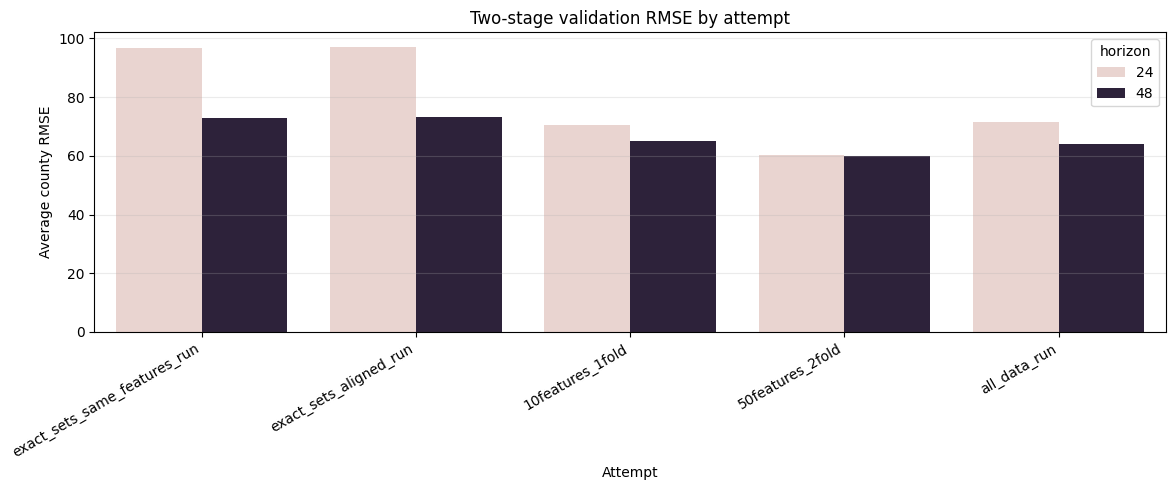

,horizon,pair_tag,classifier_name,classifier_params,regressor_name,regressor_params,bundle_source,refit_two_stage_model_path,refit_stage1_model_path,refit_stage2_model_path,refit_prediction_path,mean_horizon,mean_fold_id,mean_avg_county_rmse_expected,mean_avg_county_rmse_hard_gate,mean_overall_rmse_expected,mean_overall_mae_expected,mean_zero_baseline_rmse,mean_zero_baseline_avg_county_rmse,mean_stage1_roc_auc,mean_stage1_average_precision,mean_stage1_brier_score,mean_stage1_log_loss,mean_stage1_precision,mean_stage1_recall,mean_stage1_f1,mean_stage1_tn,mean_stage1_fp,mean_stage1_fn,mean_stage1_tp,mean_stage2_positive_rows_train,mean_stage2_positive_rows_valid,mean_stage2_positive_rmse,mean_stage2_positive_mae,mean_stage2_fallback_only
0,24,h24__clf_xgbc01__reg_xgbr01,xgb_classifier,"{""n_estimators"": 150, ""learning_rate"": 0.08, ""...",xgb_regressor,"{""n_estimators"": 200, ""learning_rate"": 0.06, ""...",trained_refit,results/run_20260419_203159/models/final_bundl...,results/run_20260419_203159/models/final_stage...,results/run_20260419_203159/models/final_stage...,results/run_20260419_203159/predictions/final_...,24.0,1.0,97.215833,96.765887,279.609890,63.940949,292.559274,100.305327,0.899869,0.870378,0.124715,0.393228,0.907173,0.589041,0.714286,1218.0,44.0,300.0,430.0,140227.0,730.0,461.668012,174.333493,0.0
1,48,h48__clf_xgbc01__reg_xgbr01,xgb_classifier,"{""n_estimators"": 150, ""learning_rate"": 0.08, ""...",xgb_regressor,"{""n_estimators"": 200, ""learning_rate"": 0.06, ""...",trained_refit,results/run_20260419_203159/models/final_bundl...,results/run_20260419_203159/models/final_stage...,results/run_20260419_203159/models/final_stage...,results/run_20260419_203159/predictions/final_...,48.0,1.0,73.248641,72.592268,200.275941,36.827300,209.924881,75.356110,0.873311,0.825382,0.131215,0.412890,0.888745,0.511541,0.649338,2555.0,86.0,656.0,687.0,251115.0,1343.0,345.051009,107.987487,0.0


**Two-stage candidate comparison, 24h**

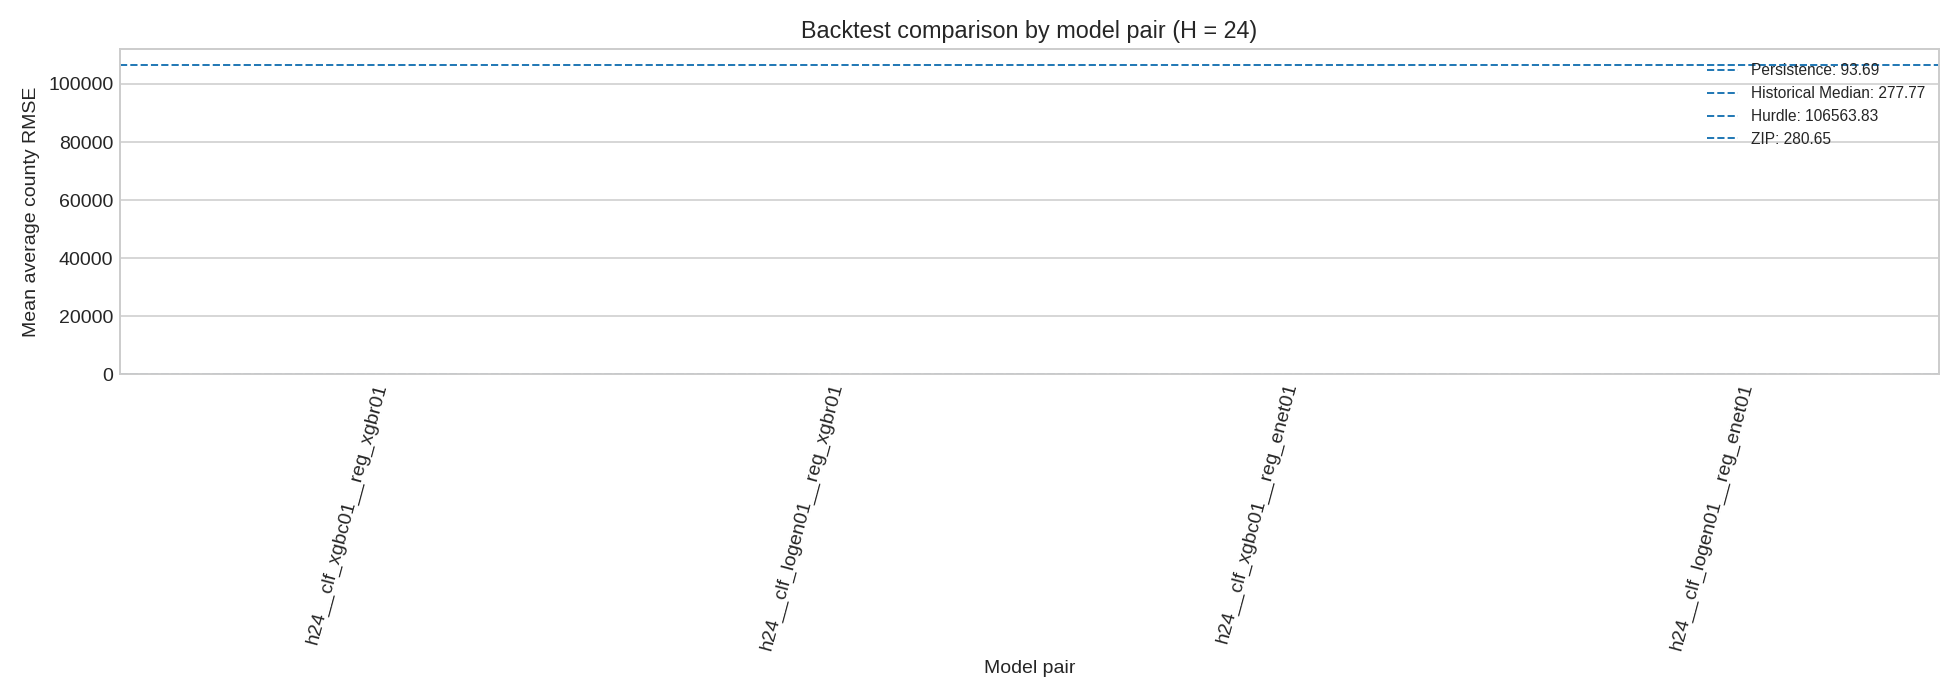

**Two-stage candidate comparison, 48h**

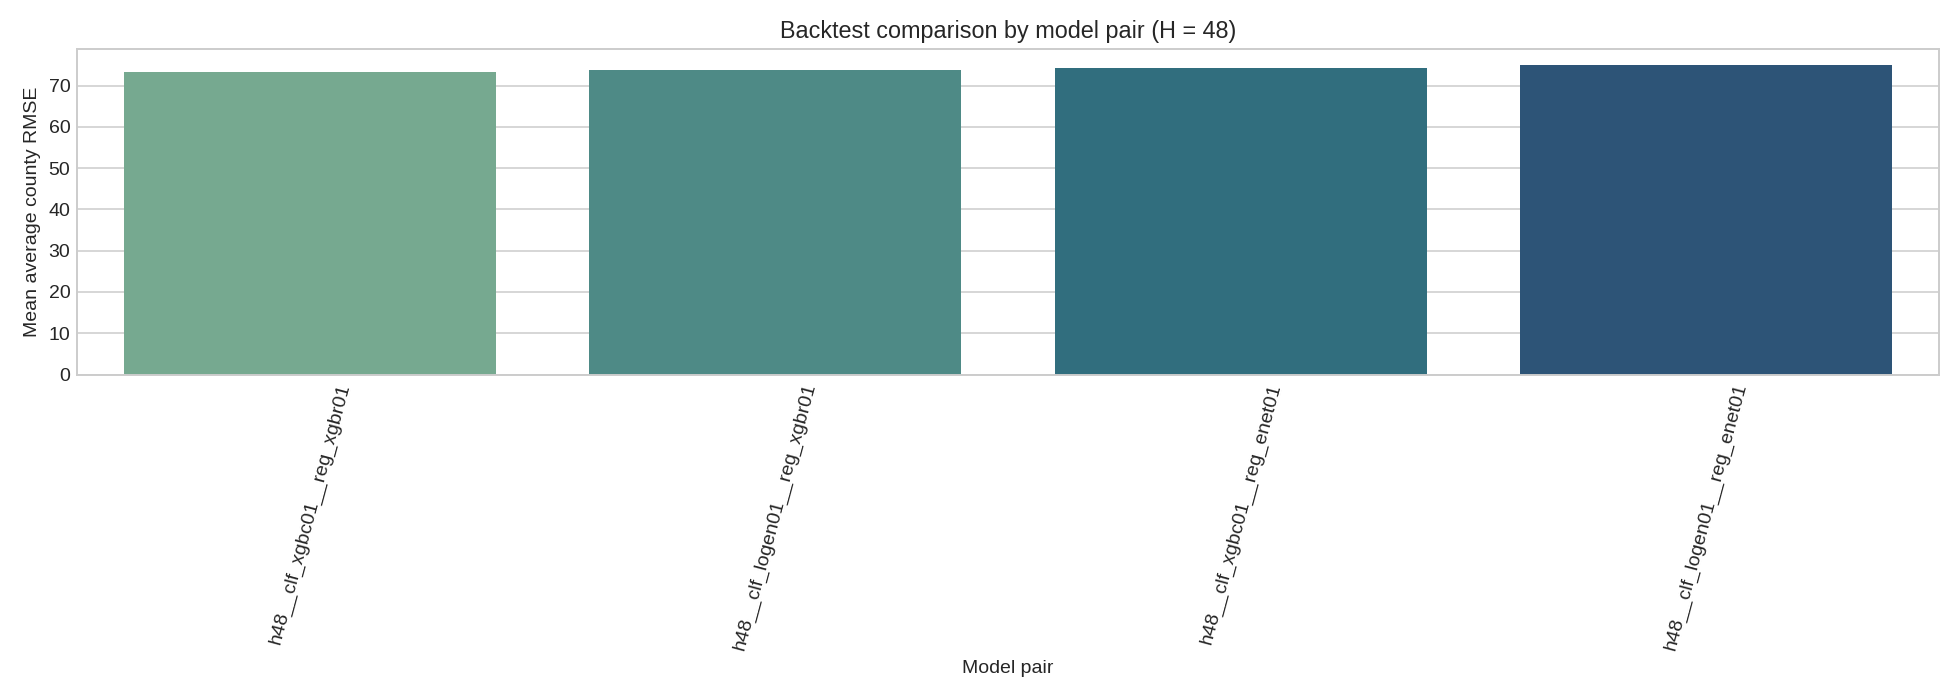

**Two-stage best pair confusion matrix, 24h**

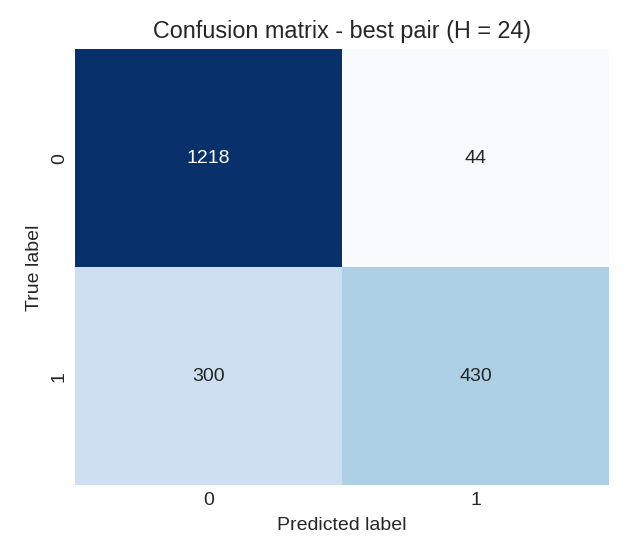

**Two-stage best pair confusion matrix, 48h**

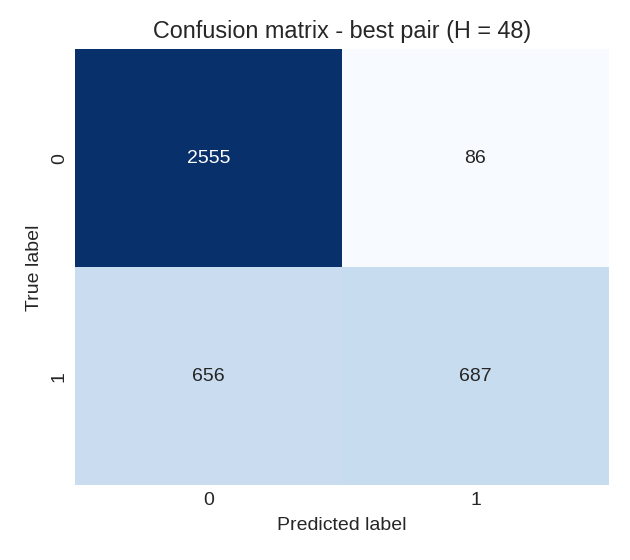

**Two-stage prediction distributions, 24h**

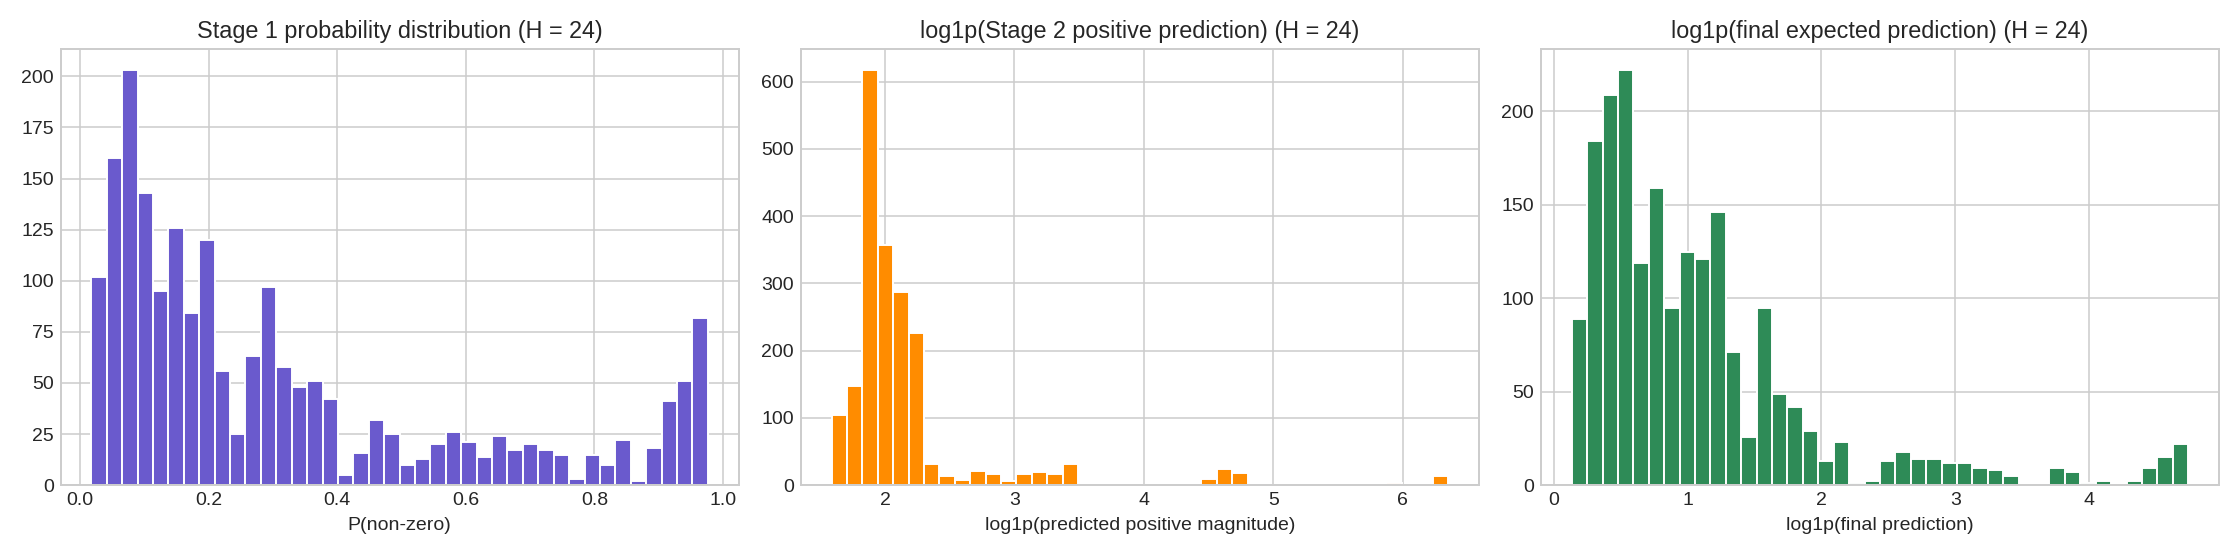

**Two-stage prediction distributions, 48h**

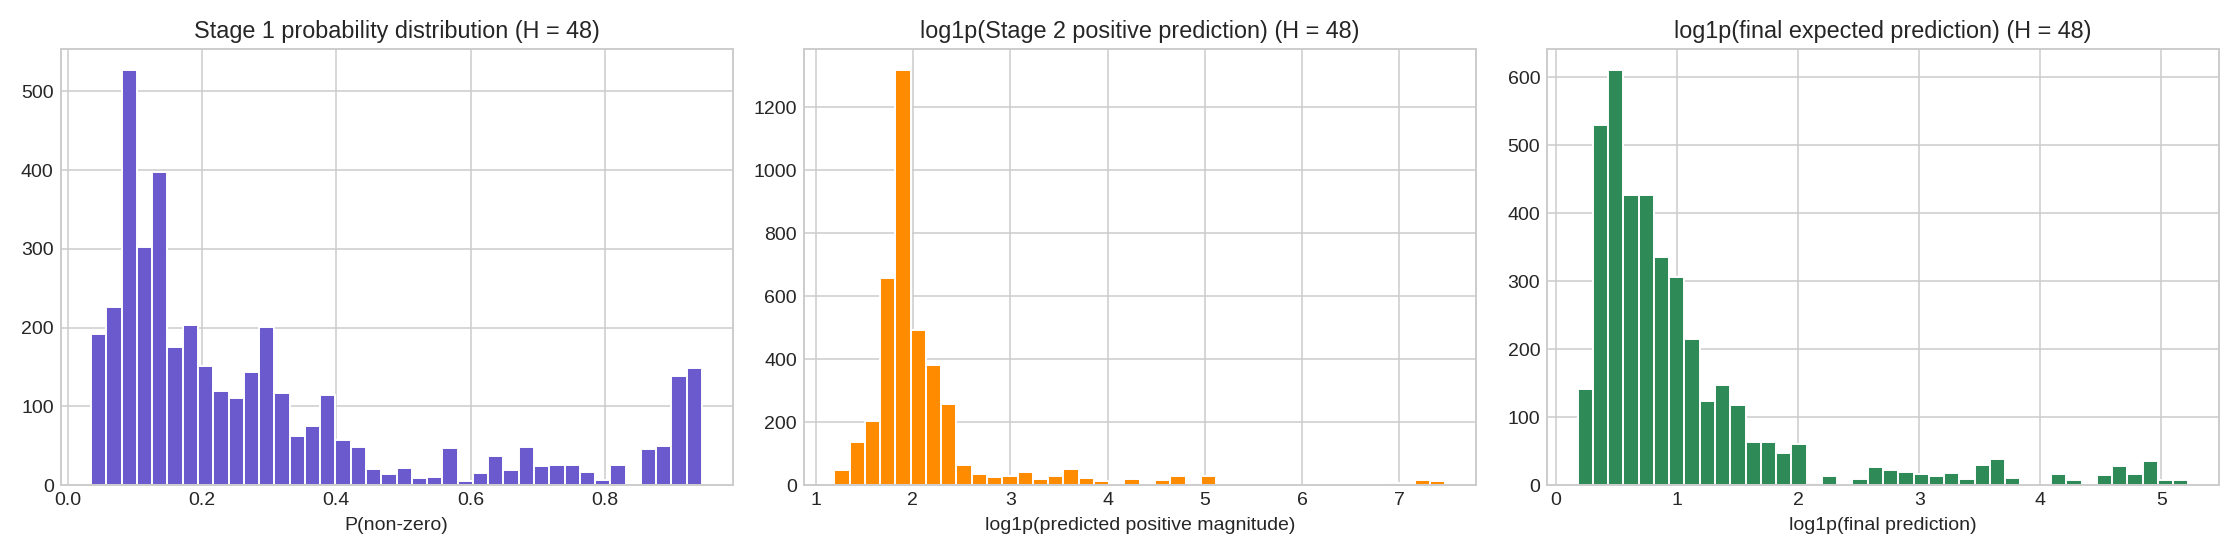

**Generated two-stage top counties, 24h**

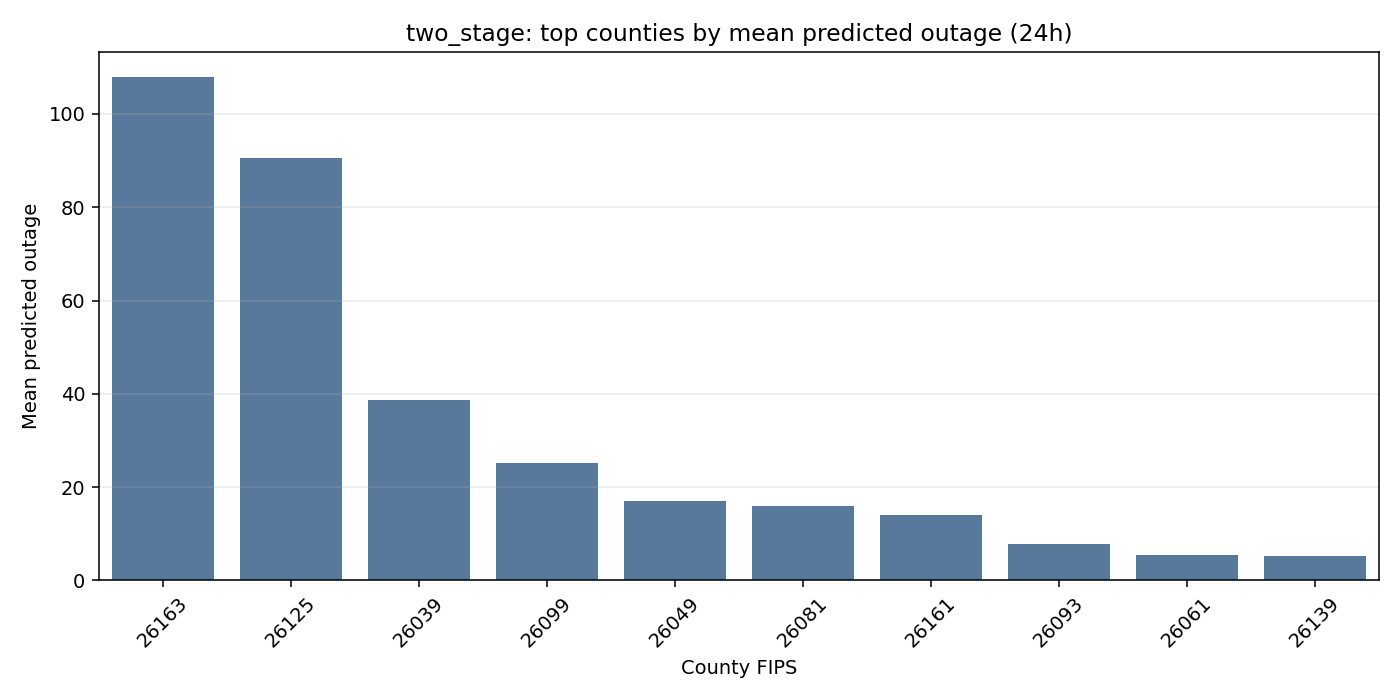

**Generated two-stage top counties, 48h**

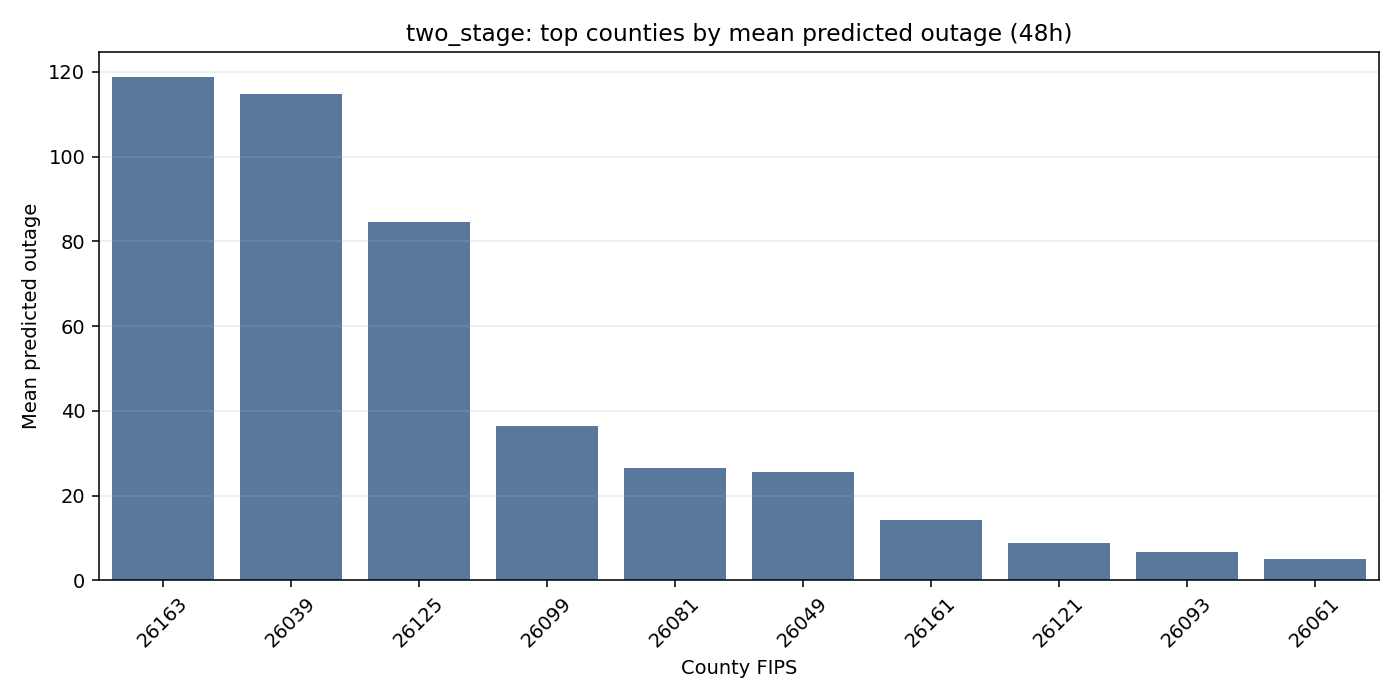

In [23]:
SELECTED_TWO_STAGE_ATTEMPT = SETTINGS['two_stage_default_attempt']
SELECTED_TWO_STAGE_DIR = TWO_STAGE_DIR / SELECTED_TWO_STAGE_ATTEMPT

if not SELECTED_TWO_STAGE_DIR.exists():
    raise FileNotFoundError(
        f'Selected two-stage attempt {SELECTED_TWO_STAGE_ATTEMPT} was not found under {TWO_STAGE_DIR}. '
        'Update SETTINGS["two_stage_default_attempt"] to one of the discovered attempt folders.'
    )

print(f'Selected two-stage attempt: {SELECTED_TWO_STAGE_ATTEMPT}')
print(f'Artifact directory: {SELECTED_TWO_STAGE_DIR.relative_to(PROJECT_ROOT)}')

for horizon in SETTINGS['horizons']:
    load_prediction_candidates(
        'two_stage',
        horizon,
        [
            SELECTED_TWO_STAGE_DIR / 'predictions' / f'two_stage_pred_{horizon}h.csv',
            SELECTED_TWO_STAGE_DIR / 'predictions' / f'final_refit_pred_{horizon}h.csv',
        ],
    )

write_prediction_summaries_and_plots(
    'two_stage',
    MODEL_PREDICTIONS.get('two_stage', {}),
    SELECTED_TWO_STAGE_DIR,
    f'two_stage_{SELECTED_TWO_STAGE_ATTEMPT}',
)


def read_two_stage_summary(attempt_key, attempt_dir):
    candidate_paths = [
        attempt_dir / 'tables' / 'final_refit_validation_summary.csv',
        attempt_dir / 'tables' / 'pair_summary.csv',
    ]
    frames = []
    for path in candidate_paths:
        if path.exists():
            frame = pd.read_csv(path)
            frame.insert(0, 'attempt_key', attempt_key)
            frame.insert(1, 'source_table', path.name)
            frames.append(frame)
    if frames:
        return pd.concat(frames, ignore_index=True, sort=False)
    return pd.DataFrame()


two_stage_attempt_summaries = []
for _, attempt in TWO_STAGE_ATTEMPTS.iterrows():
    summary = read_two_stage_summary(attempt['attempt_key'], attempt['artifact_dir'])
    if not summary.empty:
        two_stage_attempt_summaries.append(summary)

if two_stage_attempt_summaries:
    two_stage_attempt_comparison = pd.concat(two_stage_attempt_summaries, ignore_index=True, sort=False)
    comparison_path = OUTPUT_DIRS['comparison'] / 'two_stage_attempt_comparison.csv'
    two_stage_attempt_comparison.to_csv(comparison_path, index=False)
    print(f'Saved two-stage attempt comparison to {comparison_path.relative_to(PROJECT_ROOT)}')

    display_cols = [
        col for col in [
            'attempt_key',
            'source_table',
            'horizon',
            'pair_tag',
            'mean_avg_county_rmse_expected',
            'mean_overall_rmse_expected',
            'mean_stage1_roc_auc',
            'mean_stage1_average_precision',
            'mean_stage1_f1',
        ] if col in two_stage_attempt_comparison.columns
    ]
    display(two_stage_attempt_comparison[display_cols].sort_values(
        [col for col in ['horizon', 'mean_avg_county_rmse_expected', 'attempt_key'] if col in display_cols],
        na_position='last',
    ))

    if 'mean_avg_county_rmse_expected' in two_stage_attempt_comparison.columns:
        plot_df = two_stage_attempt_comparison[
            two_stage_attempt_comparison['source_table'].eq('final_refit_validation_summary.csv')
        ].copy()
        if plot_df.empty:
            plot_df = two_stage_attempt_comparison.copy()
        plot_df = plot_df.dropna(subset=['mean_avg_county_rmse_expected'])
        if not plot_df.empty:
            fig, ax = plt.subplots(figsize=(12, 5))
            if sns is not None:
                sns.barplot(
                    data=plot_df,
                    x='attempt_key',
                    y='mean_avg_county_rmse_expected',
                    hue='horizon',
                    ax=ax,
                )
            else:
                for horizon, hdf in plot_df.groupby('horizon'):
                    ax.bar(hdf['attempt_key'] + f' {horizon}h', hdf['mean_avg_county_rmse_expected'], label=f'{horizon}h')
                ax.legend()
            ax.set_title('Two-stage validation RMSE by attempt')
            ax.set_xlabel('Attempt')
            ax.set_ylabel('Average county RMSE')
            plt.xticks(rotation=30, ha='right')
            plt.tight_layout()
            plt.savefig(OUTPUT_DIRS['comparison'] / 'two_stage_attempt_comparison.png', dpi=140)
            plt.show()
else:
    print('No two-stage validation or pair summary tables were found in the attempt subfolders.')


def register_two_stage_metrics_from_table(attempt_key, metric_path):
    metrics = pd.read_csv(metric_path)
    lower_to_original = {col.lower(): col for col in metrics.columns}
    horizon_col = lower_to_original.get('horizon')
    rmse_col = (
        lower_to_original.get('mean_avg_county_rmse_expected')
        or lower_to_original.get('mean_avg_county_rmse')
        or lower_to_original.get('validation_rmse')
        or lower_to_original.get('rmse')
    )
    if horizon_col is None or rmse_col is None:
        print(f'Skipping metric registration for {metric_path.relative_to(PROJECT_ROOT)} because required columns are absent.')
        return

    for _, row in metrics.iterrows():
        display_name = row.get('pair_tag', row.get('model', f'Two-stage: {attempt_key}'))
        register_metric(
            'two_stage',
            attempt_key,
            f'Two-stage: {display_name}',
            int(row[horizon_col]),
            float(row[rmse_col]),
            str(metric_path.relative_to(PROJECT_ROOT)),
            overall_rmse=float(row.get('mean_overall_rmse_expected', np.nan)),
            stage1_roc_auc=float(row.get('mean_stage1_roc_auc', np.nan)),
            stage1_average_precision=float(row.get('mean_stage1_average_precision', np.nan)),
            stage1_f1=float(row.get('mean_stage1_f1', np.nan)),
        )


for _, attempt in TWO_STAGE_ATTEMPTS.iterrows():
    primary_metric_path = attempt['artifact_dir'] / 'tables' / 'final_refit_validation_summary.csv'
    if not primary_metric_path.exists():
        primary_metric_path = attempt['artifact_dir'] / 'tables' / 'pair_summary.csv'
    if primary_metric_path.exists():
        register_two_stage_metrics_from_table(attempt['attempt_key'], primary_metric_path)


selected_validation_path = SELECTED_TWO_STAGE_DIR / 'tables' / 'final_refit_validation_summary.csv'
selected_pair_summary_path = SELECTED_TWO_STAGE_DIR / 'tables' / 'pair_summary.csv'
selected_metric_path = selected_validation_path if selected_validation_path.exists() else selected_pair_summary_path

if selected_metric_path.exists():
    selected_two_stage_metrics = pd.read_csv(selected_metric_path)
    lower_to_original = {col.lower(): col for col in selected_two_stage_metrics.columns}
    horizon_col = lower_to_original.get('horizon')
    rmse_col = (
        lower_to_original.get('mean_avg_county_rmse_expected')
        or lower_to_original.get('mean_avg_county_rmse')
        or lower_to_original.get('validation_rmse')
        or lower_to_original.get('rmse')
    )
    if horizon_col is None or rmse_col is None:
        raise ValueError(f'{selected_metric_path} must include horizon and RMSE columns.')

    display(selected_two_stage_metrics)
    for _, row in selected_two_stage_metrics.iterrows():
        display_name = row.get('pair_tag', row.get('model', f'Two-stage: {SELECTED_TWO_STAGE_ATTEMPT}'))
        register_metric(
            'two_stage',
            SELECTED_TWO_STAGE_ATTEMPT,
            f'Two-stage: {display_name}',
            int(row[horizon_col]),
            float(row[rmse_col]),
            str(selected_metric_path.relative_to(PROJECT_ROOT)),
            overall_rmse=float(row.get('mean_overall_rmse_expected', np.nan)),
            stage1_roc_auc=float(row.get('mean_stage1_roc_auc', np.nan)),
            stage1_average_precision=float(row.get('mean_stage1_average_precision', np.nan)),
            stage1_f1=float(row.get('mean_stage1_f1', np.nan)),
        )
else:
    print(f'Two-stage metrics were not found for {SELECTED_TWO_STAGE_ATTEMPT}.')

for plot_name, title in [
    ('pair_comparison_h24.png', 'Two-stage candidate comparison, 24h'),
    ('pair_comparison_h48.png', 'Two-stage candidate comparison, 48h'),
    ('best_pair_confusion_h24.png', 'Two-stage best pair confusion matrix, 24h'),
    ('best_pair_confusion_h48.png', 'Two-stage best pair confusion matrix, 48h'),
    ('prediction_distributions_h24.png', 'Two-stage prediction distributions, 24h'),
    ('prediction_distributions_h48.png', 'Two-stage prediction distributions, 48h'),
    (f'two_stage_{SELECTED_TWO_STAGE_ATTEMPT}_top10_counties_24h.png', 'Generated two-stage top counties, 24h'),
    (f'two_stage_{SELECTED_TWO_STAGE_ATTEMPT}_top10_counties_48h.png', 'Generated two-stage top counties, 48h'),
]:
    show_image_if_exists(SELECTED_TWO_STAGE_DIR / 'plots' / plot_name, title)


## 9. Model Comparison and Selection

The comparison table is built from a single registry populated by each model section. This makes the selection logic explicit and auditable. The table includes the zero baseline, all LSTM variants, SARIMA, and the selected two-stage run. The final prediction model can be selected separately for the 24-hour and 48-hour horizons.


,family_key,variant_key,display_model,horizon,validation_rmse,metric_source,overall_rmse,stage1_roc_auc,stage1_average_precision,stage1_f1
0,two_stage,50features_2fold,Two-stage: h24__clf_logen01__reg_xgbr01,24,60.399669,final_notebook/two_stage/50features_2fold/tabl...,148.547392,0.867932,0.786901,0.680925
1,two_stage,10features_1fold,Two-stage: h24__clf_xgbc01__reg_enet01,24,70.485108,final_notebook/two_stage/10features_1fold/tabl...,179.713719,0.865599,0.796855,0.645329
2,two_stage,all_data_run,Two-stage: h24__clf_xgbc01__reg_xgbr01,24,71.670389,final_notebook/two_stage/all_data_run/tables/f...,188.936537,0.867414,0.796272,0.664441
3,sarima,sarima_seasonal_top10,SARIMA seasonal tuned top 10 counties,24,79.757401,Integrated validation split,NaN,NaN,NaN,NaN
4,sarima,sarima_top20_nonseasonal,SARIMA non-seasonal tuned top 20 counties,24,80.708883,Integrated validation split,NaN,NaN,NaN,NaN
5,sarima,sarima_top10_nonseasonal,SARIMA non-seasonal tuned top 10 counties,24,80.907501,Integrated validation split,NaN,NaN,NaN,NaN
6,lstm,base,LSTM-Base: outage only,24,85.167803,Integrated LSTM validation split,NaN,NaN,NaN,NaN
7,sarima,sarima_base,"Base SARIMA(1,0,1)",24,89.744951,Integrated validation split,NaN,NaN,NaN,NaN
8,two_stage,exact_sets_same_features_run,Two-stage: h24__clf_xgbc01__reg_xgbr01,24,96.763166,final_notebook/two_stage/exact_sets_same_featu...,278.109689,0.874362,0.849604,0.663082
9,two_stage,exact_sets_aligned_run,Two-stage: h24__clf_xgbc01__reg_xgbr01,24,97.215833,final_notebook/two_stage/exact_sets_aligned_ru...,279.609890,0.899869,0.870378,0.714286


,family_key,variant_key,display_model,horizon,validation_rmse,metric_source,overall_rmse,stage1_roc_auc,stage1_average_precision,stage1_f1
0,baseline,zero,Zero baseline,24,100.305327,Computed from shared validation split,NaN,NaN,NaN,NaN
1,baseline,zero,Zero baseline,48,75.356110,Computed from shared validation split,NaN,NaN,NaN,NaN
2,sarima,sarima_seasonal_top10,SARIMA seasonal tuned top 10 counties,24,79.757401,Integrated validation split,NaN,NaN,NaN,NaN
3,sarima,sarima_seasonal_top10,SARIMA seasonal tuned top 10 counties,48,62.448473,Integrated validation split,NaN,NaN,NaN,NaN
4,lstm,simple,LSTM-Simple: top 10 weather,24,125.616009,Integrated LSTM validation split,NaN,NaN,NaN,NaN
5,lstm,simple,LSTM-Simple: top 10 weather,48,72.143697,Integrated LSTM validation split,NaN,NaN,NaN,NaN
6,two_stage,exact_sets_aligned_run,Two-stage: h24__clf_xgbc01__reg_xgbr01,24,97.215833,final_notebook/two_stage/exact_sets_aligned_ru...,279.609890,0.899869,0.870378,0.714286
7,two_stage,exact_sets_aligned_run,Two-stage: h48__clf_xgbc01__reg_xgbr01,48,73.248641,final_notebook/two_stage/exact_sets_aligned_ru...,200.275941,0.873311,0.825382,0.649338


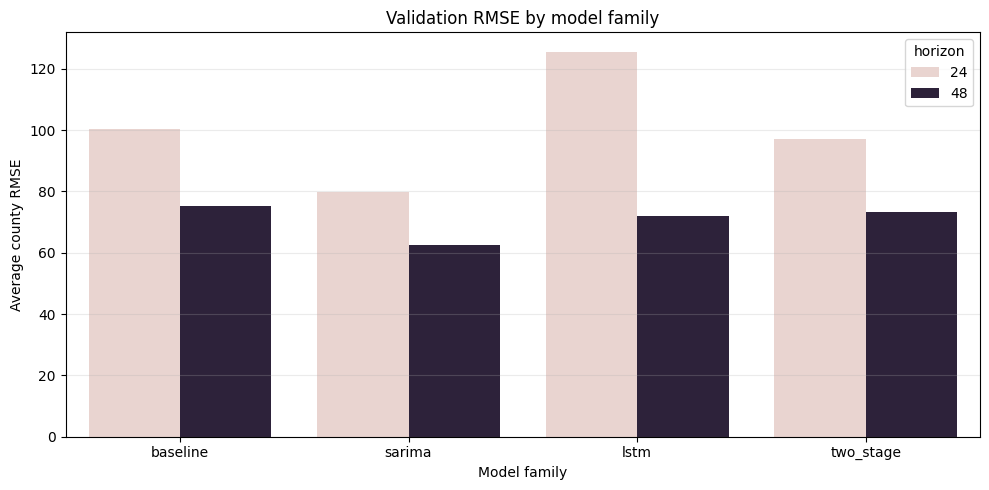

Selected 24h model: LSTM-Simple: top 10 weather (lstm/simple); validation RMSE = 125.6160
Selected 24h predictions: 1,992 rows from final_notebook/LSTM/predictions/lstm_pred_24h.csv


,timestamp,location,pred
0,2023-06-30 01:00:00,26001,17.879246
1,2023-06-30 02:00:00,26001,17.693350
2,2023-06-30 03:00:00,26001,17.877146
3,2023-06-30 04:00:00,26001,17.927372
4,2023-06-30 05:00:00,26001,18.258217


Selected 48h model: LSTM-Simple: top 10 weather (lstm/simple); validation RMSE = 72.1437
Selected 48h predictions: 3,984 rows from final_notebook/LSTM/predictions/lstm_pred_48h.csv


,timestamp,location,pred
0,2023-06-30 01:00:00,26091,1161.197144
1,2023-06-30 02:00:00,26091,1163.468994
2,2023-06-30 03:00:00,26091,1160.404175
3,2023-06-30 04:00:00,26091,1159.721558
4,2023-06-30 05:00:00,26091,1149.320068


In [24]:
metrics_df = pd.DataFrame(MODEL_METRICS)
metrics_df = metrics_df.drop_duplicates(subset=['family_key', 'variant_key', 'horizon', 'display_model'], keep='last')
metrics_df = metrics_df.sort_values(['horizon', 'validation_rmse', 'family_key'], na_position='last').reset_index(drop=True)

display(metrics_df)
metrics_df.to_csv(OUTPUT_DIRS['comparison'] / 'all_model_metrics_registry.csv', index=False)


def selected_variant_for_family(family_key, horizon):
    if family_key == 'lstm':
        return SETTINGS['lstm_variant_for_prediction'][int(horizon)]
    if family_key == 'two_stage':
        return SETTINGS['two_stage_default_attempt']
    if family_key == 'sarima':
        return SETTINGS['sarima_variant_for_prediction']
    if family_key == 'baseline':
        return 'zero'
    return None


def get_selected_metric_row(family_key, horizon):
    variant = selected_variant_for_family(family_key, horizon)
    candidate = metrics_df[(metrics_df['family_key'] == family_key) & (metrics_df['horizon'] == int(horizon))]
    if variant is not None:
        candidate = candidate[candidate['variant_key'] == variant]
    if candidate.empty:
        return None
    return candidate.iloc[0]


family_comparison_rows = []
for family_key in ['baseline', 'sarima', 'lstm', 'two_stage']:
    for horizon in SETTINGS['horizons']:
        row = get_selected_metric_row(family_key, horizon)
        if row is None:
            family_comparison_rows.append({
                'family_key': family_key,
                'variant_key': selected_variant_for_family(family_key, horizon),
                'display_model': family_key,
                'horizon': horizon,
                'validation_rmse': np.nan,
                'metric_source': 'not available',
            })
        else:
            family_comparison_rows.append(row.to_dict())

family_comparison = pd.DataFrame(family_comparison_rows)
family_comparison.to_csv(OUTPUT_DIRS['comparison'] / 'family_model_comparison.csv', index=False)
display(family_comparison)

plot_df = family_comparison.dropna(subset=['validation_rmse']).copy()
if not plot_df.empty:
    fig, ax = plt.subplots(figsize=(10, 5))
    if sns is not None:
        sns.barplot(data=plot_df, x='family_key', y='validation_rmse', hue='horizon', ax=ax)
    else:
        for horizon, hdf in plot_df.groupby('horizon'):
            ax.bar(hdf['family_key'] + f' {horizon}h', hdf['validation_rmse'], label=f'{horizon}h')
        ax.legend()
    ax.set_title('Validation RMSE by model family')
    ax.set_xlabel('Model family')
    ax.set_ylabel('Average county RMSE')
    plt.tight_layout()
    plt.savefig(OUTPUT_DIRS['comparison'] / 'model_family_comparison.png', dpi=140)
    plt.show()

selected_model_by_horizon = {
    24: SETTINGS['model_for_predictions_24h'],
    48: SETTINGS['model_for_predictions_48h'],
}

SELECTED_PREDICTIONS = {}
for horizon, family_key in selected_model_by_horizon.items():
    metric_row = get_selected_metric_row(family_key, horizon)
    if metric_row is None or pd.isna(metric_row['validation_rmse']):
        print(f'Selected {horizon}h model: {family_key}. Validation RMSE is not available yet.')
    else:
        print(
            f"Selected {horizon}h model: {metric_row['display_model']} "
            f"({family_key}/{metric_row['variant_key']}); validation RMSE = {metric_row['validation_rmse']:.4f}"
        )

    pred_df = MODEL_PREDICTIONS.get(family_key, {}).get(horizon)
    SELECTED_PREDICTIONS[horizon] = pred_df
    if pred_df is None:
        print(f'No prediction dataframe is loaded for selected {horizon}h model {family_key}.')
    else:
        pred_path = MODEL_PREDICTION_PATHS.get(family_key, {}).get(horizon)
        print(f'Selected {horizon}h predictions: {len(pred_df):,} rows from {pred_path.relative_to(PROJECT_ROOT)}')
        display(pred_df.head())


## 10. Generator Allocation

This section applies it to the selected prediction model. Two definitions of county demand are reported. The peak-outage rule prioritizes the worst predicted hour in each county. The cumulative-outage rule prioritizes the total predicted outage burden over the forecast window. Because generators remain deployed throughout the event, the cumulative rule is generally more consistent with total impact mitigation, while the peak rule is useful as a stress-test of single-hour severity.


Generator allocation model: lstm, horizon: 48h
Peak-demand allocation: ['26091', '26123', '26117', '26055', '26125']


,location,demand,generators_assigned,marginal_benefit,covered,remaining_unmet
0,26091,1163.468994,1,163.468994,1000.000000,163.468994
1,26123,822.667847,1,0.000000,822.667847,0.000000
2,26117,754.470398,1,0.000000,754.470398,0.000000
3,26055,639.521912,1,0.000000,639.521912,0.000000
4,26125,371.809814,1,371.809814,371.809814,0.000000
5,26161,266.552551,0,266.552551,0.000000,266.552551
6,26099,264.244904,0,264.244904,0.000000,264.244904
7,26009,245.996964,0,245.996964,0.000000,245.996964
8,26163,173.448013,0,173.448013,0.000000,173.448013
9,26153,168.617157,0,168.617157,0.000000,168.617157


Cumulative-demand allocation: ['26091', '26125', '26055', '26009', '26123']


,location,demand,generators_assigned,marginal_benefit,covered,remaining_unmet
0,26091,21247.906582,1,0.000000,21247.906582,0.000000
1,26125,13245.998940,1,0.000000,13245.998940,0.000000
2,26055,10596.517655,1,0.000000,10596.517655,0.000000
3,26009,8018.944589,1,0.000000,8018.944589,0.000000
4,26123,7536.756533,1,7536.756533,7536.756533,0.000000
5,26099,6893.418922,0,6893.418922,0.000000,6893.418922
6,26117,6694.422209,0,6694.422209,0.000000,6694.422209
7,26105,5814.237123,0,5814.237123,0.000000,5814.237123
8,26081,5671.815575,0,5671.815575,0.000000,5671.815575
9,26153,5551.680881,0,5551.680881,0.000000,5551.680881


Recommended county vector for submission, using cumulative demand: ['26091', '26125', '26055', '26009', '26123']


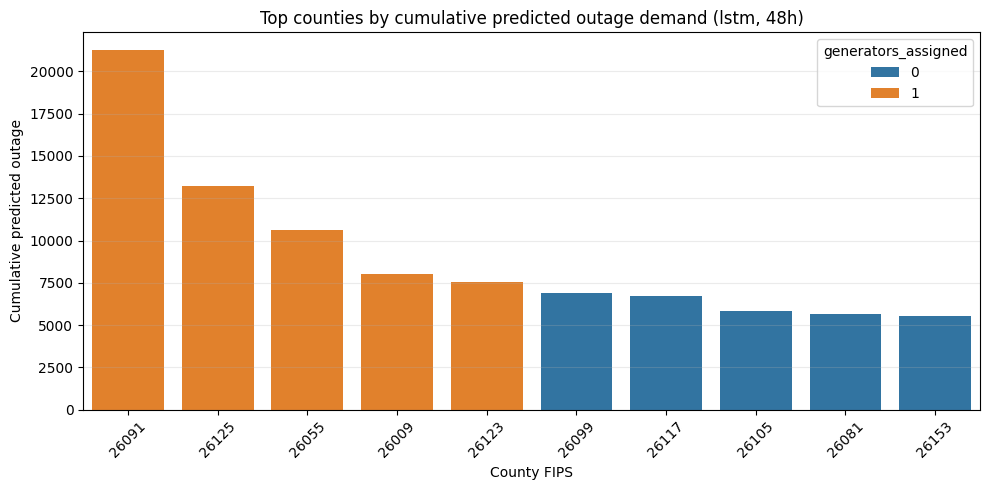

In [25]:
def greedy_allocation_peak(pred_df, n_generators=5, capacity=1000):
    demand_df = pred_df.groupby('location', as_index=False)['pred'].max().rename(columns={'pred': 'demand'})
    demand_df['generators_assigned'] = 0
    allocation = []

    for _ in range(n_generators):
        demand_df['marginal_benefit'] = np.minimum(
            np.maximum(demand_df['demand'] - capacity * demand_df['generators_assigned'], 0),
            capacity,
        )
        best_idx = demand_df['marginal_benefit'].idxmax()
        best_county = demand_df.loc[best_idx, 'location']
        demand_df.loc[best_idx, 'generators_assigned'] += 1
        allocation.append(best_county)

    demand_df['covered'] = np.minimum(demand_df['demand'], demand_df['generators_assigned'] * capacity)
    demand_df['remaining_unmet'] = demand_df['demand'] - demand_df['covered']
    summary = demand_df.sort_values(['generators_assigned', 'demand'], ascending=[False, False]).reset_index(drop=True)
    return allocation, summary


def greedy_allocation_sum(pred_df, n_generators=5, hourly_capacity=1000):
    horizon = pred_df['timestamp'].nunique()
    capacity = hourly_capacity * horizon
    demand_df = pred_df.groupby('location', as_index=False)['pred'].sum().rename(columns={'pred': 'demand'})
    demand_df['generators_assigned'] = 0
    allocation = []

    for _ in range(n_generators):
        demand_df['marginal_benefit'] = np.minimum(
            np.maximum(demand_df['demand'] - capacity * demand_df['generators_assigned'], 0),
            capacity,
        )
        best_idx = demand_df['marginal_benefit'].idxmax()
        best_county = demand_df.loc[best_idx, 'location']
        demand_df.loc[best_idx, 'generators_assigned'] += 1
        allocation.append(best_county)

    demand_df['covered'] = np.minimum(demand_df['demand'], demand_df['generators_assigned'] * capacity)
    demand_df['remaining_unmet'] = demand_df['demand'] - demand_df['covered']
    summary = demand_df.sort_values(['generators_assigned', 'demand'], ascending=[False, False]).reset_index(drop=True)
    return allocation, summary


allocation_family = SETTINGS['model_for_allocation']
allocation_horizon = int(SETTINGS['model_for_allocation_horizon'])
allocation_pred_df = MODEL_PREDICTIONS.get(allocation_family, {}).get(allocation_horizon)

if allocation_family != 'lstm':
    print(f'Allocation is configured for {allocation_family}. The project-selected allocation model is currently LSTM.')

if allocation_pred_df is None:
    raise FileNotFoundError(
        f'No predictions are loaded for allocation model {allocation_family} at horizon {allocation_horizon}. '
        'Load or generate the corresponding prediction CSV before running this cell.'
    )

allocation_dir = OUTPUT_DIRS['generator_allocation']
allocation_outputs_dir = allocation_dir / 'outputs'
allocation_outputs_dir.mkdir(parents=True, exist_ok=True)

allocation_peak, summary_peak = greedy_allocation_peak(
    allocation_pred_df,
    n_generators=SETTINGS['n_generators'],
    capacity=SETTINGS['generator_hourly_capacity'],
)
allocation_sum, summary_sum = greedy_allocation_sum(
    allocation_pred_df,
    n_generators=SETTINGS['n_generators'],
    hourly_capacity=SETTINGS['generator_hourly_capacity'],
)

summary_peak.to_csv(allocation_dir / f'{allocation_family}_{allocation_horizon}h_peak_allocation_summary.csv', index=False)
summary_sum.to_csv(allocation_dir / f'{allocation_family}_{allocation_horizon}h_sum_allocation_summary.csv', index=False)
summary_peak.to_csv(allocation_outputs_dir / f'{allocation_family}_{allocation_horizon}h_peak_allocation_summary.csv', index=False)
summary_sum.to_csv(allocation_outputs_dir / f'{allocation_family}_{allocation_horizon}h_sum_allocation_summary.csv', index=False)
with open(allocation_dir / f'{allocation_family}_{allocation_horizon}h_recommended_counties.txt', 'w', encoding='utf-8') as handle:
    handle.write(str(allocation_sum))
with open(allocation_outputs_dir / f'{allocation_family}_{allocation_horizon}h_recommended_counties.txt', 'w', encoding='utf-8') as handle:
    handle.write(str(allocation_sum))

print(f'Generator allocation model: {allocation_family}, horizon: {allocation_horizon}h')
print('Peak-demand allocation:', allocation_peak)
display(summary_peak.head(10))
print('Cumulative-demand allocation:', allocation_sum)
display(summary_sum.head(10))
print(f'Recommended county vector for submission, using cumulative demand: {allocation_sum}')

fig, ax = plt.subplots(figsize=(10, 5))
plot_alloc = summary_sum.head(10).copy()
if sns is not None:
    sns.barplot(data=plot_alloc, x='location', y='demand', hue='generators_assigned', dodge=False, ax=ax)
else:
    ax.bar(plot_alloc['location'], plot_alloc['demand'])
ax.set_title(f'Top counties by cumulative predicted outage demand ({allocation_family}, {allocation_horizon}h)')
ax.set_xlabel('County FIPS')
ax.set_ylabel('Cumulative predicted outage')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(allocation_dir / f'{allocation_family}_{allocation_horizon}h_cumulative_demand.png', dpi=140)
plt.savefig(allocation_outputs_dir / f'{allocation_family}_{allocation_horizon}h_cumulative_demand.png', dpi=140)
plt.show()


## 11. Conclusion

The final notebook uses a shared data and validation foundation, then compares classical time-series, neural sequence, and two-stage tabular modeling strategies under the same operational constraint: future weather is not available at forecast time. The EDA shows that outages are sparse and heavy-tailed, with substantial county heterogeneity and a small set of weather variables that have the strongest marginal association with outage counts. These properties explain why simple temporal history remains highly competitive and why more flexible models must be evaluated carefully against leakage-resistant validation windows.

The current final selection is the LSTM family for both 24-hour and 48-hour predictions, with the LSTM-Simple variant used for saved prediction files. This choice reflects the empirical performance of the LSTM validation runs and the desire to retain a compact weather feature set. The notebook nonetheless keeps SARIMA and the two-stage approach in the same registry, so replacing the selected model only requires changing `model_for_predictions_24h`, `model_for_predictions_48h`, or `model_for_allocation` in the settings section.

For generator pre-positioning, the cumulative-demand greedy rule is the recommended default because the generators remain fixed during the event and the policy objective is to reduce total unmet outage burden, not only the single worst hour. The peak-demand allocation is retained as a complementary robustness view. The final recommendation should be interpreted with the usual operational caveats: predicted outage counts are uncertain, generator capacity is simplified as homogeneous, and county-level deployment ignores within-county logistics. Still, the pipeline provides a transparent link from model forecasts to a reproducible county allocation decision.
